# Orbital Debris Database: Exploring the Landscape

**Database:** orbital_debris.db (SQLite)  
**Docs:** See the quick reports in notebook 04 and the data dictionary in `docs/schema` for full table and field details.

**Goal:** Find patterns, outliers, and follow-up questions in the orbital debris database to guide later analysis and charts.

**Process:**
- Define the question and the fields needed to answer it.
- Use SQL to pull the data and pandas to help prepare and analyze it.
- Make simple charts or tables to see what stands out.

### Why this notebook?
This notebook uses the cleaned, joined database for targeted exploration. It is meant for testing questions, checking patterns, and saving useful findings for later notebooks.

### What we do here
1. **Test questions:** Use SQL and pandas to check trends, outliers, and ideas.
2. **Make visuals:** Build quick charts to see what matters.
3. **Save findings:** Keep useful queries, charts, and notes for later work.

*For table structure, nulls, and sample data, see the end of notebook 04 and the data dictionary.*

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sqlite3 as sql
import utility as utils
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display, Markdown

sns.set_palette('colorblind')

COLOR_PALETTE = sns.color_palette('colorblind')

plt.rcParams.update({
    "grid.alpha": 0.3,
    "axes.facecolor": "#333333",
    "figure.facecolor": "#333333",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "legend.facecolor": "#333333",
    "legend.edgecolor": "white"
})

orbital_debris_conn = sql.connect('../data/clean/orbital_debris.db')

# Global configuration variables
MAX_TOP = 10

**Note:** Notebook 04 has the quick reports for every table. Use it for table structure, nulls, and sample data. Use `docs/schema` for field definitions. This notebook's focus is exploration.

## Decoupling Point in Orbital Growth

Find when the growth of orbital objects changed from a steadier pattern to a much faster one, and show how the mix of object types changed over time. This helps show when crowding in orbit started to speed up.

**Explore:**
- Yearly Launch Trends: How many payloads, rocket bodies, and debris objects were added to orbit each year?
  - Payload Launch Trends: Launch trends for payloads launched per year
  - Debris Growth Over Time: Number of debris objects added per year
  - Rocket Bodies Used Over Time: Annual Rocket Body Counts per year
- Object Type Distribution: How the mix of payloads, rocket bodies, and debris changes over time
- Linear vs Exponential Trend: Show the shift point with a fitted trend and best split year

In [2]:
# Only count payloads (exclude debris, rocket bodies, etc.)
launches_per_year_query = """
SELECT
    satellites.norad_id,
    satellites.object_type,
    launch_events.launch_date
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE launch_events.launch_date IS NOT NULL
  AND satellites.object_type = 'PAYLOAD'
ORDER BY launch_events.launch_date ASC;
"""

# Run the query and store the result
df_launches_per_year_payloads = pd.read_sql_query(launches_per_year_query, orbital_debris_conn)

# Convert to datetime and extract year for launch trend analysis.
df_launches_per_year_payloads['launch_year'] = pd.to_datetime(df_launches_per_year_payloads['launch_date'], errors='coerce').dt.year

# Save the cleaned DataFrame to a Parquet file for future use
df_launches_per_year_payloads.to_parquet('../data/clean/results/payloads_per_year_exp.parquet', index=False)

### Payload Launch Trends

Show how many payload objects were launched each year so it is easier to spot growth periods, slowdowns, and major shifts in orbital activity.

**Method:**
- Pull launch years for payload objects from the database.
- Count how many payload objects were launched in each year.

**Visuals:**
- A bar chart showing the number of payload objects launched per year.

**How to Read This:**
- Taller bars mean more payload objects were launched that year.
- Look for sudden jumps or drops to spot major shifts in launch activity.
- Long periods of rising bars suggest sustained growth in orbital activity.

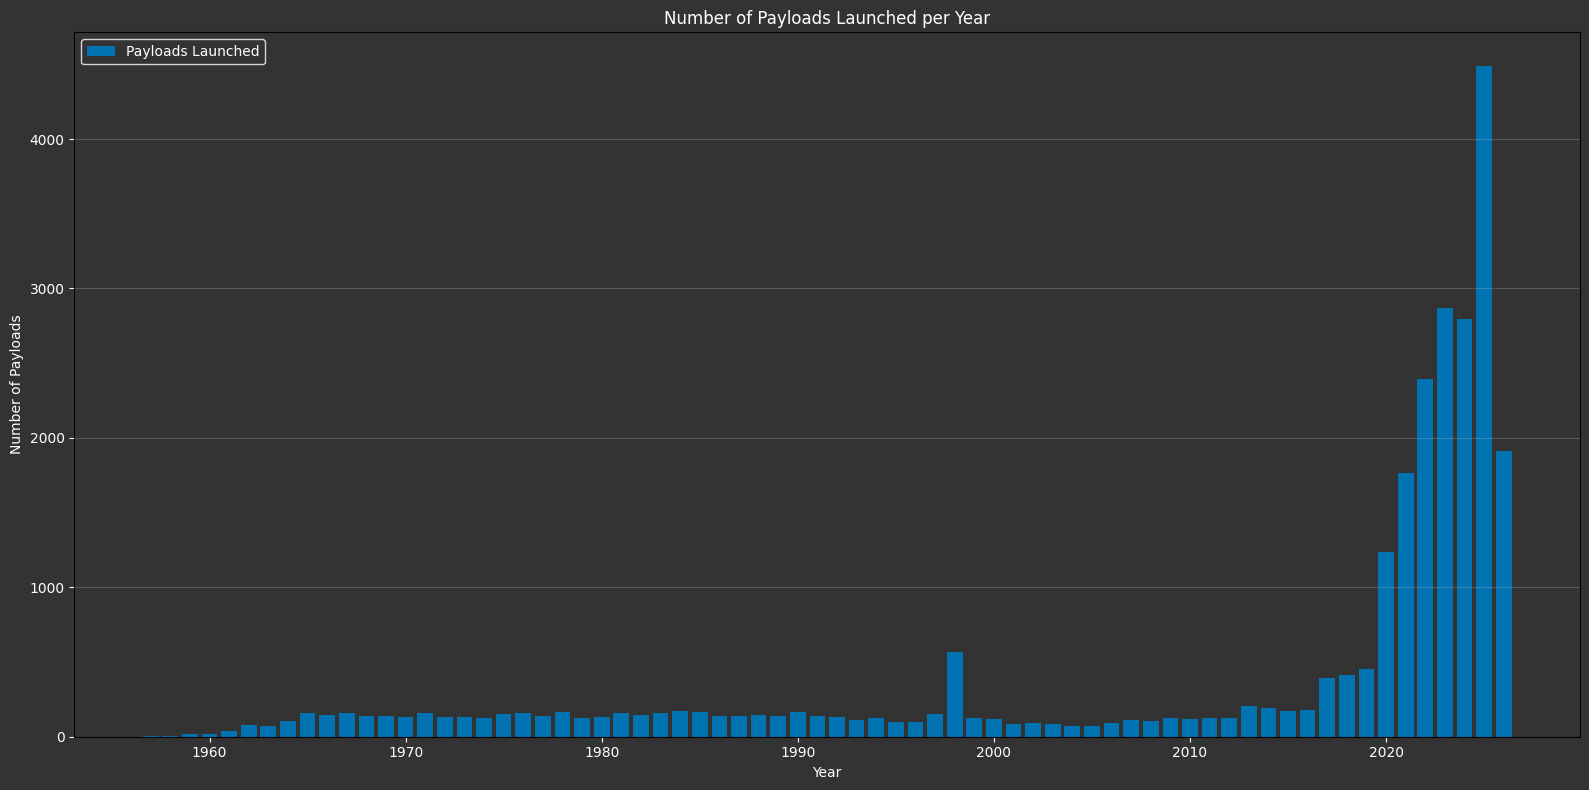

In [3]:
# Count the number of launches per year
if 'launch_year' in df_launches_per_year_payloads.columns:
  launch_counts = df_launches_per_year_payloads['launch_year'].value_counts().sort_index()

  plt.figure(figsize=(16,8))
  
  plt.bar(launch_counts.index, launch_counts.values, color=COLOR_PALETTE[0], label='Payloads Launched')

  plt.title('Number of Payloads Launched per Year')
  plt.xlabel('Year')
  plt.ylabel('Number of Payloads')
  plt.grid(axis='y', alpha=0.3)
  plt.legend( loc='upper left')
  
  plt.tight_layout()
  plt.savefig('../charts/payloads_per_year_exp.png', bbox_inches='tight', dpi=100)
  plt.show()
else:
  print('launch_year column not found in launches data.')

### Debris Growth Over Time: Annual Debris Object Counts

Show how the number of debris objects added to orbit changes over time.

**Method:**
- Pull launch years for objects labeled as debris.
- Ignore decay timing for this question because the goal is to measure debris added to orbit each year.
- Count the number of debris objects per year.

**Visuals:**
- A bar chart showing the number of debris objects added to orbit each year.

**How to Read This:**
- Taller bars mean more debris objects were added in that year.
- Sharp spikes usually point to major breakup or anti-satellite events.
- Compare early and recent years to see whether debris growth is speeding up.

In [4]:
debris_query = """
SELECT
    satellites.norad_id,
    launch_events.launch_year AS debris_year
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE launch_events.launch_year IS NOT NULL 
  AND satellites.object_type = 'DEBRIS'
ORDER BY launch_events.launch_year ASC;
"""

df_debris_per_year_exp = pd.read_sql_query(debris_query, orbital_debris_conn)
df_debris_per_year_exp['debris_year'] = pd.to_numeric(df_debris_per_year_exp['debris_year'], errors='coerce')

df_debris_per_year_exp.to_parquet('../data/clean/results/debris_per_year_exp.parquet', index=False)

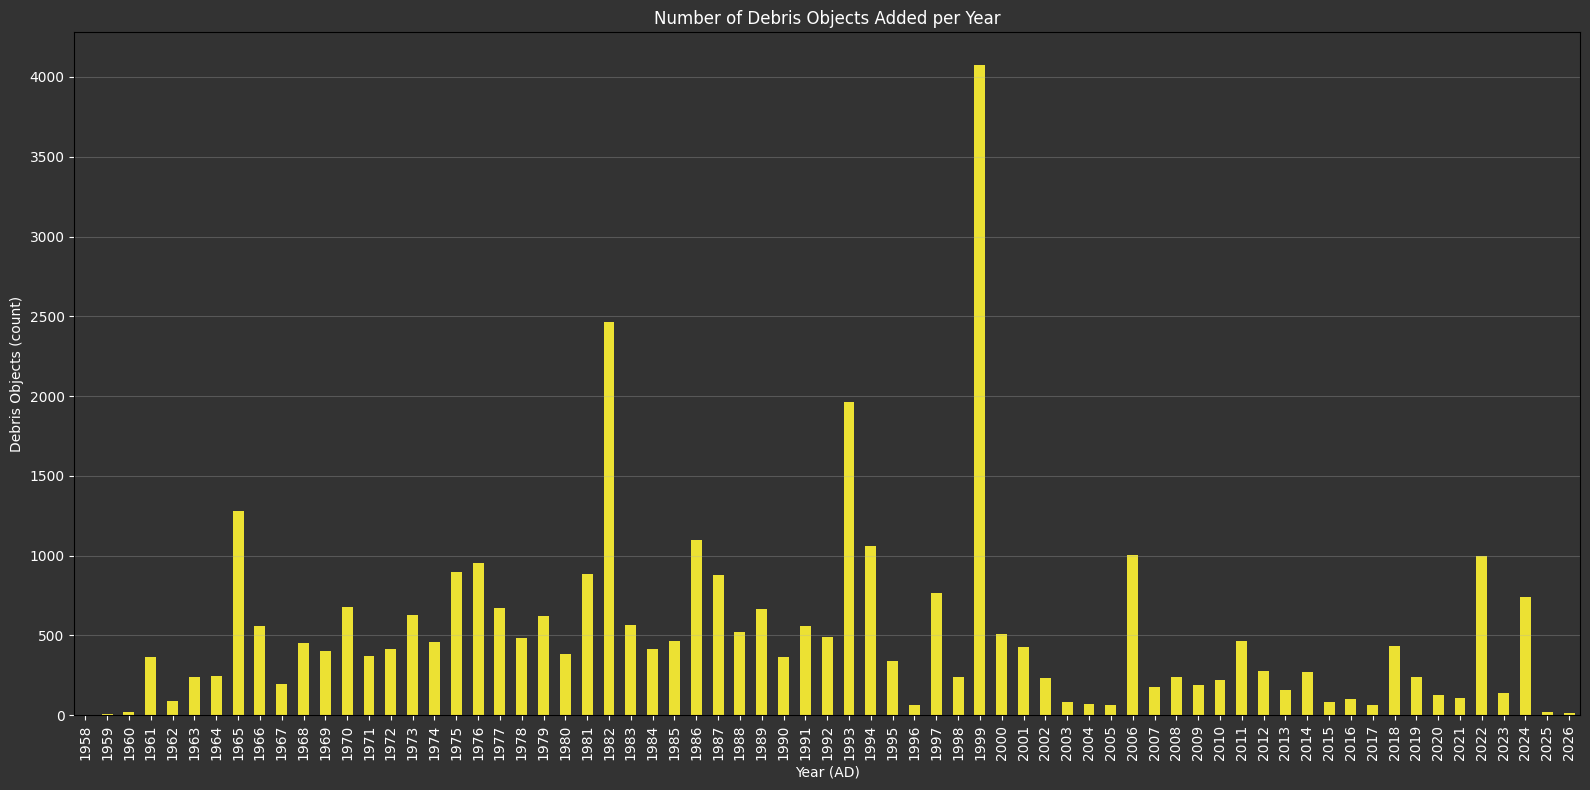

In [5]:
# Count debris objects per year
if 'debris_year' in df_debris_per_year_exp.columns:
  debris_counts = df_debris_per_year_exp['debris_year'].value_counts().sort_index()

  plt.figure(figsize=(16,8))

  # Use colorblind-safe color for bar
  debris_counts.plot(kind='bar', color=COLOR_PALETTE[8])

  plt.title('Number of Debris Objects Added per Year')
  plt.xlabel('Year (AD)')
  plt.ylabel('Debris Objects (count)')
  plt.grid(axis='y', alpha=0.3)

  plt.tight_layout()
  plt.savefig('../charts/debris_per_year_exp.png', bbox_inches='tight', dpi=100)
  plt.show()
else:
  print('debris_year column not found in debris data.')

### Rocket Bodies Used Over Time: Annual Rocket Body Counts

Show how the number of rocket bodies left in orbit changes over time.

**Method:**
- Pull launch years for objects labeled as rocket bodies.
- Ignore decay timing for this question because the goal is to measure rocket bodies added to orbit each year.
- Count the number of rocket bodies per year.

**Visuals:**
- A bar chart showing the number of rocket bodies added to orbit each year.

**How to Read This:**
- Taller bars mean more rocket bodies were left in orbit that year.
- Spikes may correspond to periods of increased launch activity or changes in launch practices.
- Compare trends to payload and debris counts to understand launch and disposal practices over time.

In [6]:
# Only count rocket bodies (exclude payloads, debris, etc.)
rocket_bodies_query = """
SELECT
    satellites.norad_id,
    satellites.object_type,
    launch_events.launch_date
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE launch_events.launch_date IS NOT NULL
  AND satellites.object_type = 'ROCKET BODY'
ORDER BY launch_events.launch_date ASC;
"""

# Run the query and store the result
df_rocket_bodies = pd.read_sql_query(rocket_bodies_query, orbital_debris_conn)

# Convert to datetime and extract year for launch trend analysis.
df_rocket_bodies['launch_year'] = pd.to_datetime(df_rocket_bodies['launch_date'], errors='coerce').dt.year

# Save the cleaned DataFrame to a Parquet file for future use
df_rocket_bodies.to_parquet('../data/clean/results/rocket_bodies_per_year_exp.parquet', index=False)

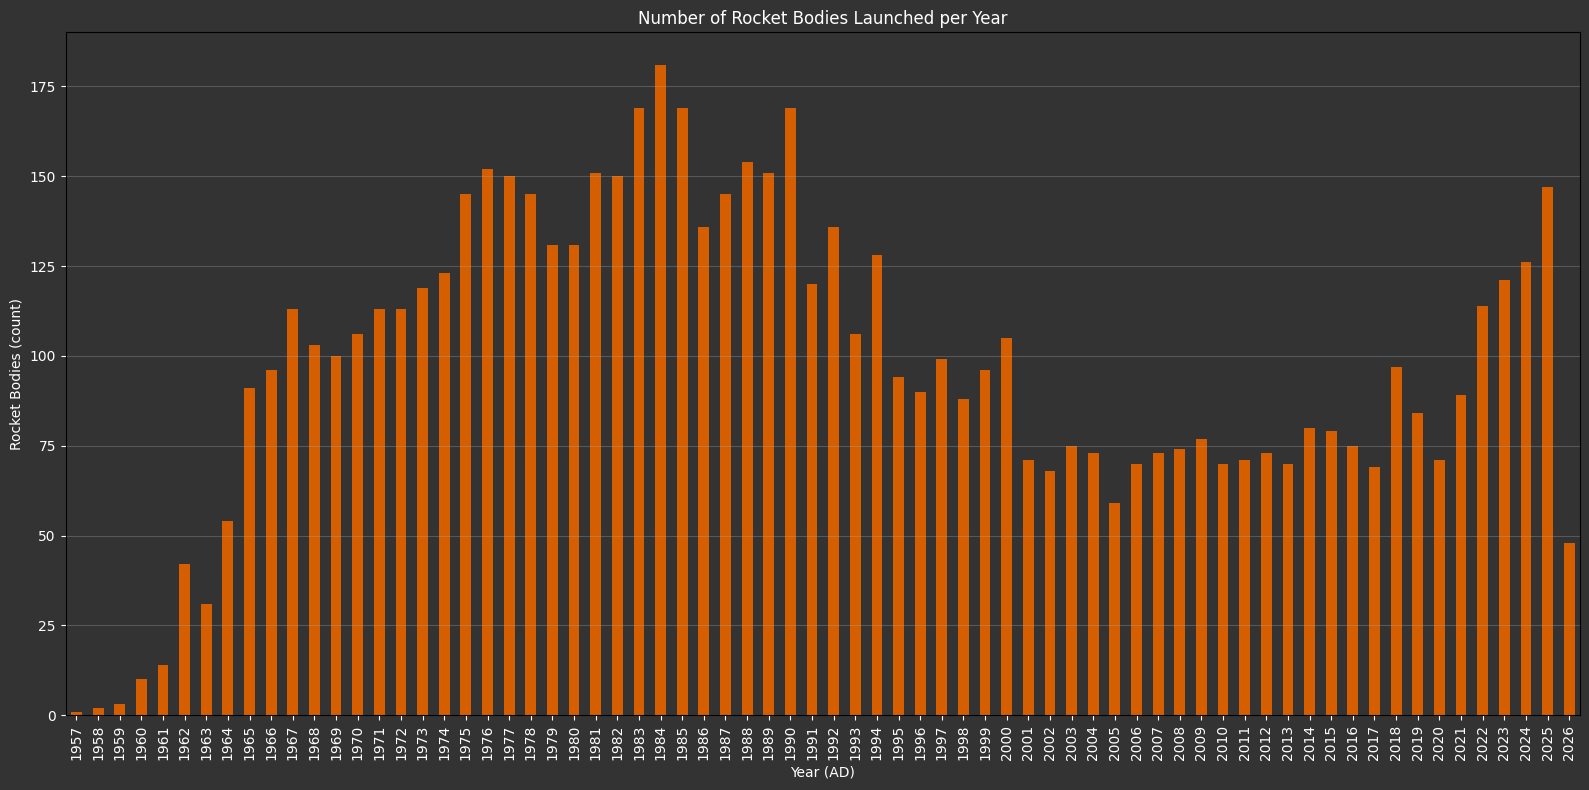

In [7]:
if 'launch_year' in df_rocket_bodies.columns:
  rocket_body_counts = df_rocket_bodies['launch_year'].value_counts().sort_index()

  plt.figure(figsize=(16,8))

  # Use colorblind-safe color for bar
  rocket_body_counts.plot(kind='bar', color=COLOR_PALETTE[3])

  plt.title('Number of Rocket Bodies Launched per Year')
  plt.xlabel('Year (AD)')
  plt.ylabel('Rocket Bodies (count)')
  plt.grid(axis='y', alpha=0.3)

  plt.tight_layout()
  plt.savefig('../charts/rocket_bodies_per_year_exp.png', bbox_inches='tight', dpi=100)
  plt.show()
else:
  print('launch_year column not found in rocket bodies data.')

### Object Type Distribution: How the Mix of Payloads, Rocket Bodies, and Debris Changes Over Time

Show how the proportions of payloads, rocket bodies, and debris have shifted over time, highlighting changes in the orbital environment.

**Method:**
- Query the satellites table (joined with launch_events) for object type and launch year.
- Group and count by year and object type.

**Visuals:**
- A stacked area chart showing the distribution of object types over time.
- A vertical bar chart alternative showing the same data for comparison.

**How to Read This:**
- Each color represents one object type.
- Wider or taller sections show that type making up more of the total in that period.
- A growing debris share over time suggests a more crowded and risky orbit environment.

In [8]:
# Only count payloads (exclude debris, rocket bodies, etc.)
launches_per_year_all_query = """
SELECT
    satellites.norad_id,
    satellites.object_type,
    launch_events.launch_date
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE launch_events.launch_date IS NOT NULL
ORDER BY launch_events.launch_date ASC;
"""

# Run the query and store the result
df_type_year = pd.read_sql_query(launches_per_year_all_query, orbital_debris_conn)

# Convert to datetime and extract year for launch trend analysis.
df_type_year['launch_year'] = pd.to_datetime(df_type_year['launch_date'], errors='coerce').dt.year

# Save the result to a parquet file for future use.
df_type_year.to_parquet('../data/clean/results/object_type_year_all_exp.parquet', index=False)

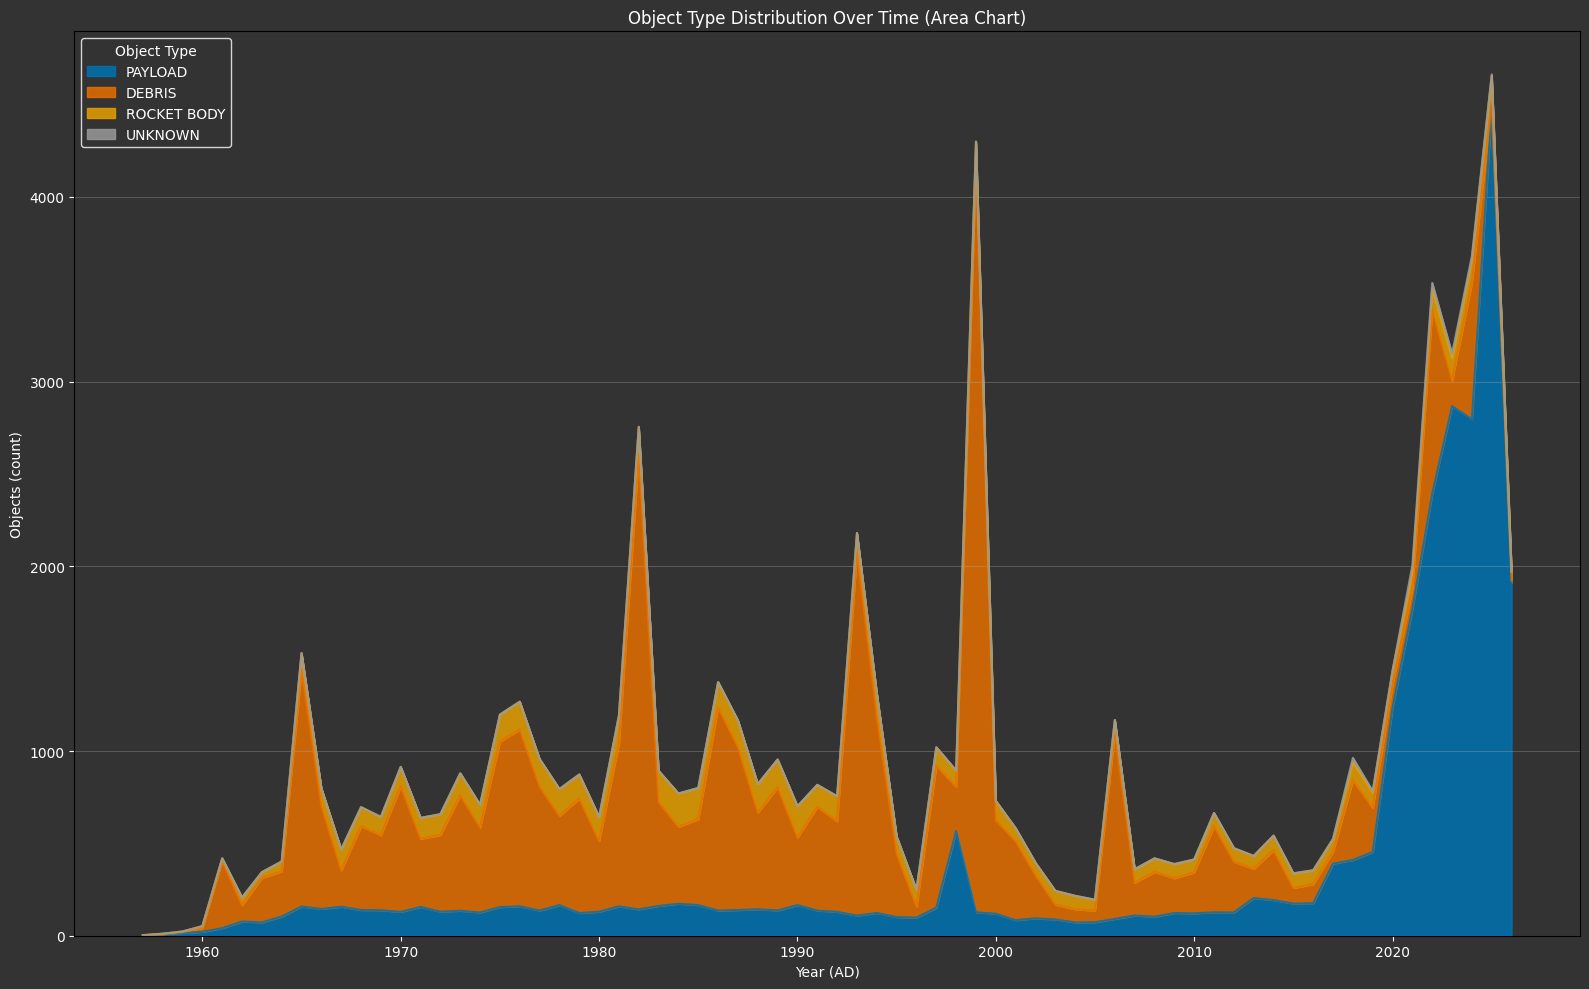

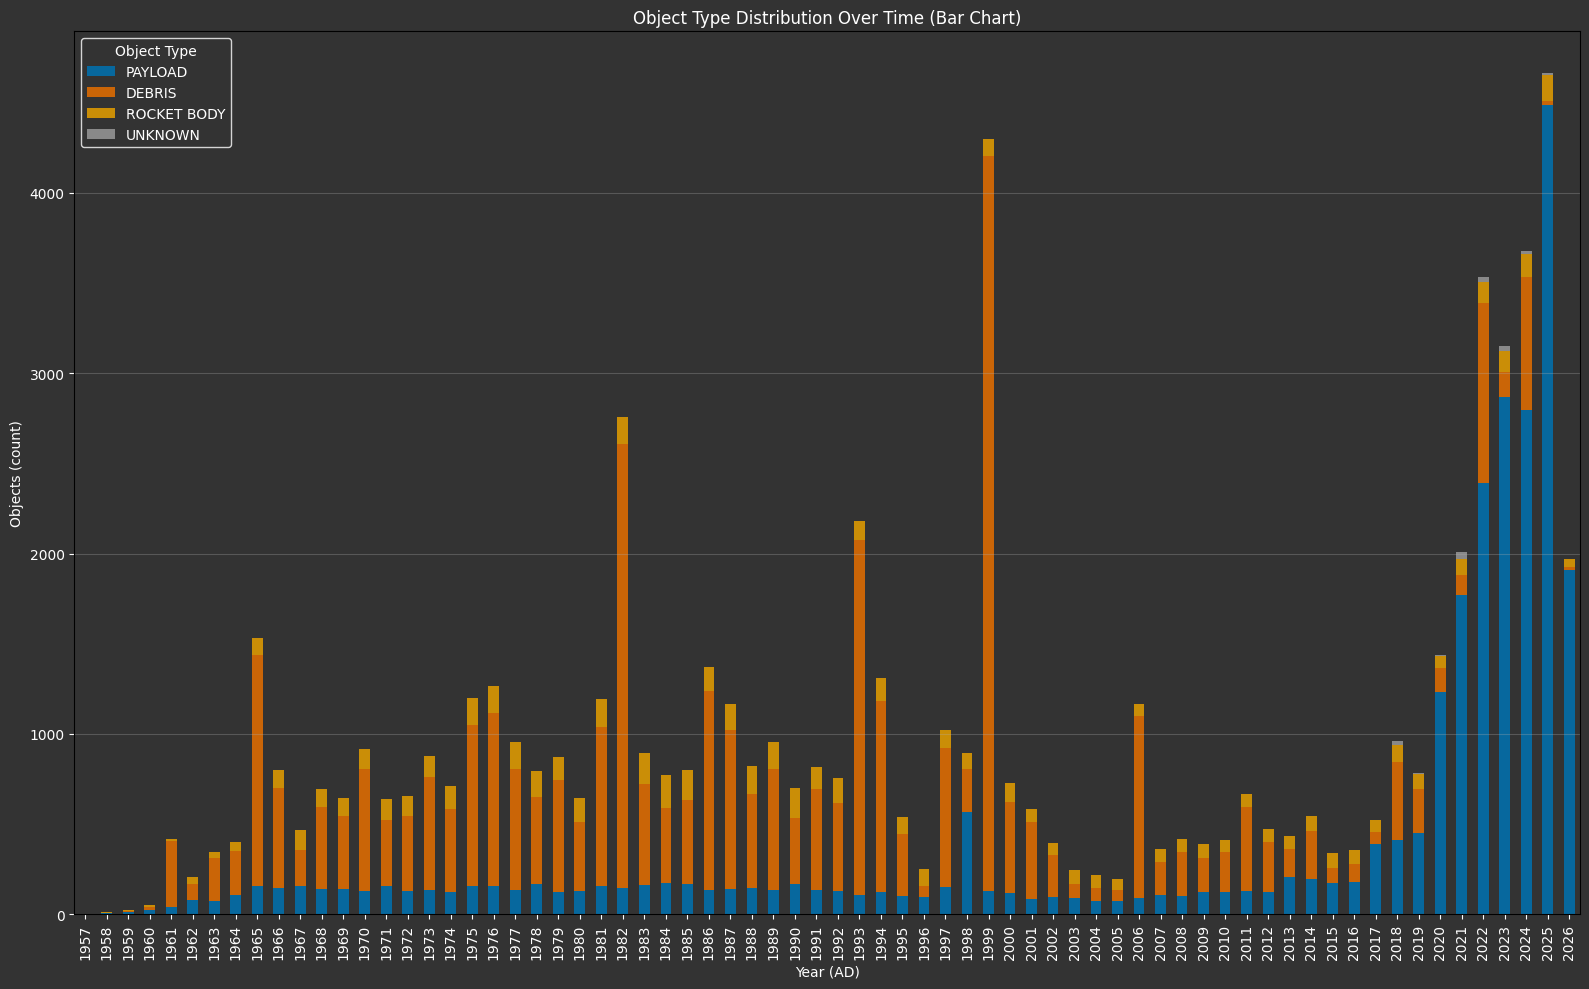

In [9]:
if 'launch_date' in df_type_year.columns and 'object_type' in df_type_year.columns:
  # Group by year and object type, count
  type_counts = df_type_year.groupby(['launch_year', 'object_type']).size().unstack(fill_value=0)

  # Define a color mapping for object types
  # We are reusing colorblind colors, but I need to change around the order to match
  # colorings for previous charts (where payloads are blue to avoid confusion)
  object_type_colors = {
    'PAYLOAD': '#0072B2',      # blue
    'DEBRIS': '#E66F00',       # orange
    'ROCKET BODY': "#E69F00",  # yellow
    'UNKNOWN': '#999999'       # gray
  }
  
  type_counts = type_counts[['PAYLOAD', 'DEBRIS', 'ROCKET BODY', 'UNKNOWN']]
  
  # Stacked Area Chart
  plt.figure(figsize=(16,10))
  
  type_counts.plot.area(ax=plt.gca(), alpha=0.85, color=[object_type_colors[col] for col in type_counts.columns])

  plt.title('Object Type Distribution Over Time (Area Chart)')
  plt.xlabel('Year (AD)')
  plt.ylabel('Objects (count)')
  plt.grid(axis='y', alpha=0.3)
  plt.legend(title='Object Type')

  plt.tight_layout()
  plt.savefig('../charts/object_type_distribution_exp.png', bbox_inches='tight', dpi=100)
  plt.show()

  # Vertical Bar Chart alternative
  plt.figure(figsize=(16,10))
  
  type_counts.plot(kind='bar', stacked=True, ax=plt.gca(), alpha=0.85, color=[object_type_colors[col] for col in type_counts.columns])

  plt.title('Object Type Distribution Over Time (Bar Chart)')
  plt.xlabel('Year (AD)')
  plt.ylabel('Objects (count)')
  plt.grid(axis='y', alpha=0.3)
  plt.legend(title='Object Type')
  
  plt.tight_layout()
  plt.savefig('../charts/object_type_distribution_bar_exp.png', bbox_inches='tight', dpi=100)
  plt.show()
else:
  print('launch_date or object_type columns not found in type_year table.')

### Linear vs Exponential Trend: In-Orbit Object Growth

Show when object growth in orbit changed from a slower steady rise to a much faster rise, and mark the year when that change happened.

**Method:**
- Leave out the current partial year so the fit is not biased.
- Compute a 3-year rolling average for easier viewing, but do not use it for the fit.
- Use a data-driven method to pick the best split year between the linear and exponential periods.
- Fit a linear trend before the split and an exponential trend after the split.


**Visuals:**
- Actual in-orbit object counts and 3-year average
- Launch missions per year
- Fitted linear and exponential trend lines
- A vertical line and note for the detected split year, plus fit details

**How to Read This:**
- The split line marks when growth changes from steady to a much faster.
- The linear fit shows the older trend; the exponential fit shows modern acceleration.
- If the post-split curve rises quickly, that means orbital crowding is increasing faster than before.

In [10]:
# payload_share_pct is the payload share of each yearly in-orbit cohort.
# cumulative_in_orbit is the running total of yearly in-orbit counts ordered by launch_year.
linear_vs_exponential_trend_query = """
WITH yearly AS (
  SELECT
    launch_events.launch_year AS launch_year,
    COUNT(*) AS objects_in_orbit,
    COUNT(DISTINCT launch_events.launch_id) AS launch_missions,
    SUM(
      CASE
        WHEN UPPER(COALESCE(satellites.object_type, '')) = 'PAYLOAD' THEN 1
        ELSE 0
      END
    ) AS payload_in_orbit
  FROM satellites
  JOIN launch_events ON launch_events.launch_id = satellites.launch_id
  WHERE launch_events.launch_year IS NOT NULL
    AND COALESCE(satellites.in_orbit, 0) = 1
  GROUP BY launch_events.launch_year
)
SELECT
  yearly.launch_year,
  yearly.objects_in_orbit,
  yearly.launch_missions,
  yearly.payload_in_orbit,
  ROUND(100.0 * yearly.payload_in_orbit / NULLIF(yearly.objects_in_orbit, 0), 2) AS payload_share_pct,
  SUM(yearly.objects_in_orbit) OVER (ORDER BY yearly.launch_year) AS cumulative_in_orbit
FROM yearly
ORDER BY yearly.launch_year;
"""

df_sat = pd.read_sql_query(linear_vs_exponential_trend_query, orbital_debris_conn)

# Ensure launch_year is numeric for filtering and plotting in the growth regime analysis.
# This is a separate DataFrame and not reused elsewhere.
df_sat['launch_year'] = pd.to_numeric(df_sat['launch_year'], errors='coerce')

# Save the query result to a parquet file for future use.
df_sat.to_parquet('../data/clean/results/linear_vs_exponential_trend_exp.parquet', index=False)

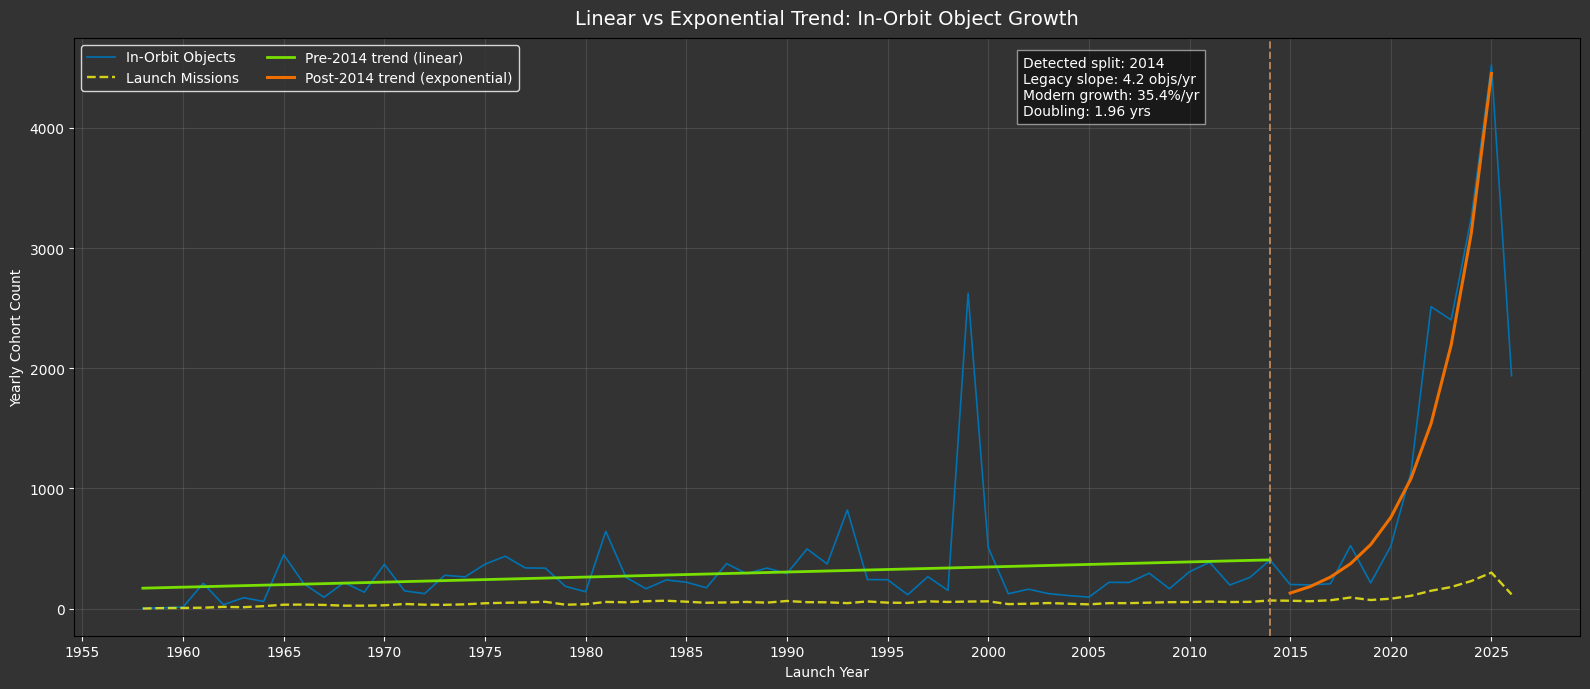

In [11]:
# Exclude the current partial year from fitting.
current_year = pd.Timestamp.now().year
df_sat_fit = df_sat[df_sat['launch_year'] < current_year].copy()

# Build a 3-year rolling average for smoother viewing only.
df_sat['objects_3yr_avg'] = df_sat['objects_in_orbit'].rolling(3, min_periods=1).mean()
df_sat_fit['objects_3yr_avg'] = df_sat_fit['objects_in_orbit'].rolling(3, min_periods=1).mean()

# Pick the split year from the data instead of hard-coding it.
split_year, _ = utils.choose_split_year(
    df_sat_fit,
    y_col='objects_in_orbit'
 )

# Fit the pre-split and post-split growth patterns.
pre, post, m_pre, b_exp, doubling_time_years = utils.fit_growth_regimes(
    df_sat_fit,
    split_year=split_year,
    y_col='objects_in_orbit'
 )

# Okabe-Ito palette (colorblind-safe) mapped to each series.
colors = {
    'objects_in_orbit': "#0072B2",
    'objects_3yr_avg': COLOR_PALETTE[4],
    'launch_missions': "#FCF813",
    'trend_linear': "#7BE600F6",  
    'trend_exponential': "#EE6F00",  
    'split_line': COLOR_PALETTE[5]
}

# Create the figure and axis together for the layered plot below.
fig, ax1 = plt.subplots(figsize=(16, 7))

sns.lineplot(
    data=df_sat,
    x='launch_year',
    y='objects_in_orbit',
    linewidth=1.2,
    color=colors['objects_in_orbit'],
    ax=ax1,
    label='In-Orbit Objects'
 )



sns.lineplot(
    data=df_sat,
    x='launch_year',
    y='launch_missions',
    linewidth=1.7,
    linestyle='--',
    alpha=0.8,
    color=colors['launch_missions'],
    ax=ax1,
    label='Launch Missions'
 )

sns.lineplot(
    data=pre,
    x='launch_year',
    y='trend_linear',
    color=colors['trend_linear'],
    ax=ax1,
    linewidth=2.0,
    label=f'Pre-{split_year} trend (linear)'
 )

sns.lineplot(
    data=post,
    x='launch_year',
    y='trend_exponential',
    color=colors['trend_exponential'],
    ax=ax1,
    linewidth=2.2,
    label=f'Post-{split_year} trend (exponential)'
 )

ax1.axvline(split_year, color=colors['split_line'], linestyle='--', alpha=0.85, linewidth=1.4)

ax1.text(
    0.63, 0.97,
    f'Detected split: {split_year}\n'
    f'Legacy slope: {m_pre:,.1f} objs/yr\n'
    f'Modern growth: {b_exp:.1%}/yr\n'
    f'Doubling: {doubling_time_years:.2f} yrs',
    transform=ax1.transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox=dict(facecolor='black', edgecolor='white', alpha=0.5)
 )

ax1.set_title('Linear vs Exponential Trend: In-Orbit Object Growth', fontsize=14, pad=10)
ax1.set_xlabel('Launch Year')
ax1.set_ylabel('Yearly Cohort Count')
ax1.grid(alpha=0.18)
ax1.legend(loc='upper left', ncol=2, frameon=True)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(5))

plt.tight_layout()
plt.savefig('../charts/linear_vs_exponential_trend_exp.png', bbox_inches='tight', dpi=100)
plt.show()

## High-Risk Object Distribution

Measure how high-risk objects are spread across orbit, focusing on objects above the risk thresholds. The goal is to show how common they are, where they sit, and how large they are.

**Explore:**
- Mass Distribution: Mass of high-risk objects, when mass is available
- High-Risk Object Counts: Number and share of objects above the risk thresholds
- Orbit Class Breakdown: High-risk objects by orbit class
- Altitude Band Analysis: High-risk objects in the 400–600 km LEO band

In [12]:
# Pull in-orbit objects with the fields needed for high-risk analysis.
# altitude_km is the midpoint of apogee and perigee, used for LEO band analysis.
high_risk_query = """
SELECT
  satellites.norad_id,
  satellites.object_name,
  COALESCE(orbital_data.orbit_class, 'UNKNOWN') AS orbit_class,
  orbital_data.proxy_mass_kg,
  (orbital_data.apogee_km + orbital_data.perigee_km) / 2.0 AS altitude_km,
  risk_assessment.velocity_kms,
  risk_assessment.kinetic_joules
FROM satellites
JOIN risk_assessment ON satellites.norad_id = risk_assessment.norad_id
JOIN orbital_data ON satellites.norad_id = orbital_data.norad_id
WHERE satellites.in_orbit = 1
  AND risk_assessment.kinetic_joules IS NOT NULL;
"""

df_all_sats = pd.read_sql_query(high_risk_query, orbital_debris_conn)
df_all_sats['risk_category'] = df_all_sats.apply(utils.classify_risk_category, axis=1)

df_high_risk = df_all_sats[
  df_all_sats['risk_category'] == 'Extremely High Risk'
].copy()

# Save the query result to a parquet file for future use.
df_high_risk.to_parquet('../data/clean/results/high_risk_sats_exp.parquet', index=False)

### High-Risk Object Counts

Quantify the number and proportion of high-risk objects in orbit, defined by exceeding kinetic energy and mass thresholds.

**Method:**
- Count the total number of objects and the subset classified as high-risk based on kinetic energy and mass criteria.
- Calculate the share of high-risk objects relative to the total population.

**Output:**
- Report the total count of objects with risk data, the count of high-risk objects, and the percentage they represent.

In [13]:
# Count and share
risk_data_objects = len(df_all_sats)
high_risk_count = len(df_high_risk)
high_risk_share = high_risk_count / risk_data_objects if risk_data_objects else float('nan')

print(f'Total objects with risk data: {risk_data_objects}')
print(f'High-risk objects: {high_risk_count} of {risk_data_objects} ({high_risk_share:.2%})')

# Validation
print('Nulls per column:')
display(df_high_risk.isnull().sum())


Total objects with risk data: 34044
High-risk objects: 13511 of 34044 (39.69%)
Nulls per column:


norad_id          0
object_name       0
orbit_class       0
proxy_mass_kg     0
altitude_km       0
velocity_kms      0
kinetic_joules    0
risk_category     0
dtype: int64

### Mass Distribution: High-Risk Objects

Show the mass distribution of extremely high-risk objects in orbit, highlighting outliers and differences by orbit class.

**Method:**
- Use available mass and orbit class data.
- Filter for "Extremely High Risk" objects (by kinetic energy and mass thresholds).

**Visuals:**
- A histogram of all high-risk masses, colored by orbit_class.
- A strip plot to show mass distribution by orbit_class.

**How to Read This:**
- Y-Axis: 10^0 is 1, 10^1 is 10, 10^2 is 100, 10^3 is 1,000, and 10^4 is 10,000. 
- X-Axis: Mass in kg, with a cap at 50,000 kg for readability. Outliers above this are shown separately.
- Bar Color: Each color represents a different orbit class.
- More points or bars in a range mean more high-risk objects at that mass.
- Compare orbit classes to see where the heaviest high-risk objects are concentrated.

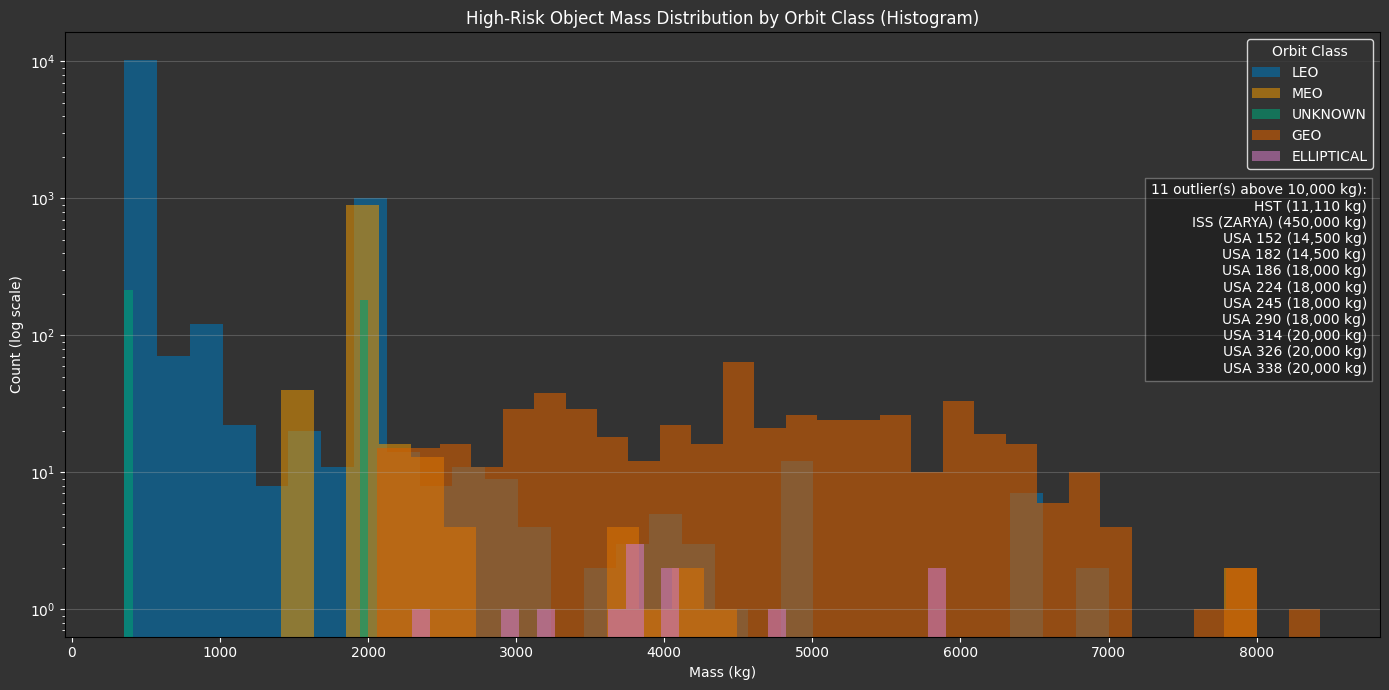

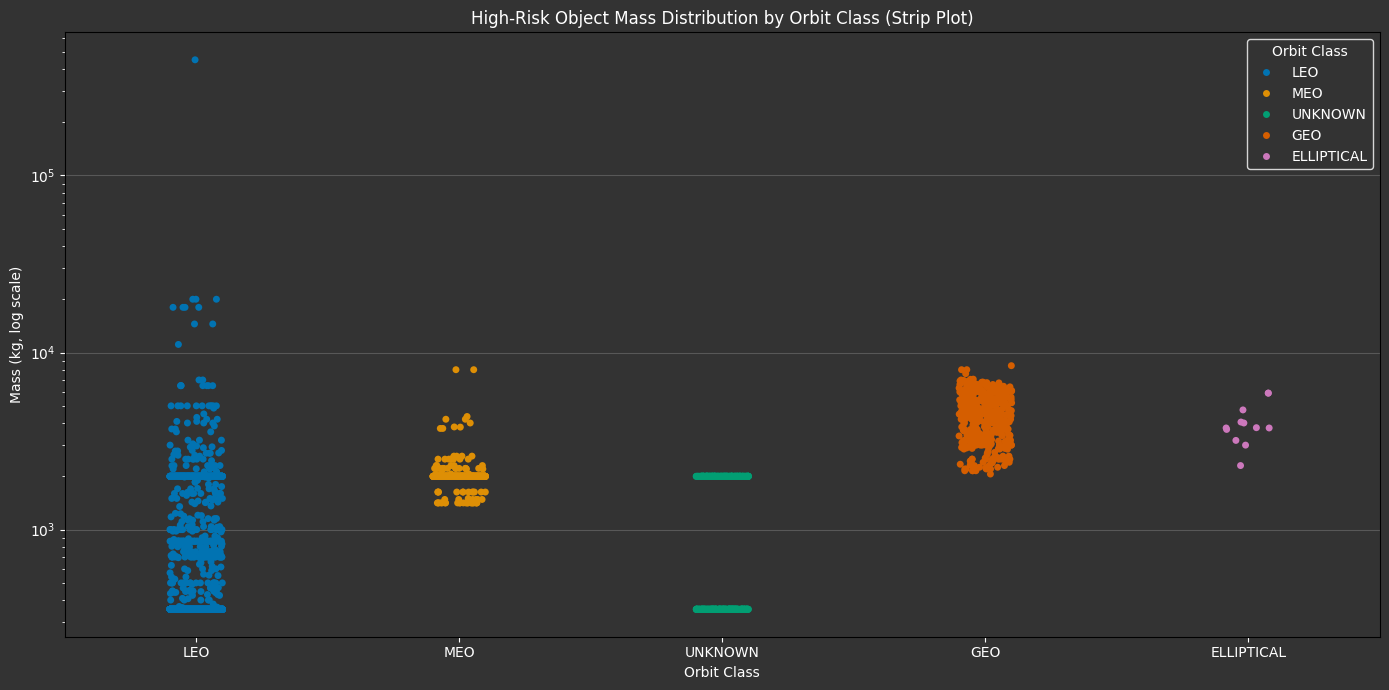

Objects with nonzero mass and orbit class: 13511


In [14]:
# Mass distribution for high-risk objects: histogram and strip plot by orbit_class
if 'proxy_mass_kg' in df_high_risk.columns and 'orbit_class' in df_high_risk.columns:
    mass_nonzero = df_high_risk[['norad_id', 'object_name', 'proxy_mass_kg', 'orbit_class']].dropna(subset=['proxy_mass_kg', 'orbit_class'])
    mass_nonzero = mass_nonzero[mass_nonzero['proxy_mass_kg'] > 0]

    # Cap the histogram at 50,000 kg so the distribution is readable.
    mass_cap = 10_000
    mass_capped = mass_nonzero[mass_nonzero['proxy_mass_kg'] <= mass_cap]
    outliers = mass_nonzero[mass_nonzero['proxy_mass_kg'] > mass_cap]

    # Histogram (high-risk masses up to cap, colored by orbit_class)
    plt.figure(figsize=(14, 7))

    for orbit_class in mass_capped['orbit_class'].unique():
        subset = mass_capped[mass_capped['orbit_class'] == orbit_class]
        plt.hist(subset['proxy_mass_kg'], bins=30, alpha=0.6, label=orbit_class)

    plt.yscale('log')
    plt.xlabel('Mass (kg)')
    plt.ylabel('Count (log scale)')
    plt.title('High-Risk Object Mass Distribution by Orbit Class (Histogram)')
    plt.legend(title='Orbit Class')
    plt.grid(axis='y', alpha=0.3)

    if len(outliers) > 0:
       
        outlier_lines = [f"{row['object_name']} ({row['proxy_mass_kg']:,.0f} kg)" for _, row in outliers.iterrows()]
        annotation_text = f"{len(outliers)} outlier(s) above {mass_cap:,} kg):\n" + "\n".join(outlier_lines)

        plt.annotate(
            annotation_text,
            xy=(0.99, 0.75), xycoords='axes fraction',
            ha='right', va='top', fontsize=10,
            bbox=dict(facecolor='black', edgecolor='white', alpha=0.3)
        )

    plt.tight_layout()
    plt.savefig('../charts/high_risk_mass_hist_by_orbit_class.png', bbox_inches='tight', dpi=100)
    plt.show()

    # Strip plot (each point = object, grouped by orbit_class)
    plt.figure(figsize=(14, 7))

    ax = sns.stripplot(
        x='orbit_class',
        y='proxy_mass_kg',
        hue='orbit_class',
        data=mass_nonzero,
        palette='colorblind',
        legend=True,
        size=5
    )

    plt.yscale('log')
    plt.xlabel('Orbit Class')
    plt.ylabel('Mass (kg, log scale)')
    plt.title('High-Risk Object Mass Distribution by Orbit Class (Strip Plot)')
    plt.legend(title='Orbit Class', loc='upper right')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../charts/high_risk_mass_strip_by_orbit_class.png', bbox_inches='tight', dpi=100)
    plt.show()

    print(f'Objects with nonzero mass and orbit class: {len(mass_nonzero)}')
else:
    print('proxy_mass_kg or orbit_class column not found in high-risk data.')

### Orbit Class Breakdown: High-Risk Objects by Orbit Class

Show how high-risk objects are distributed across orbit classes (LEO, MEO, GEO, etc.).

**Method:**
- Use the high-risk subset from above.
- Group and count by orbit class.

**Visuals:**
- A bar chart showing the distribution of high-risk objects across orbit classes.
- A pie chart alternative showing orbit class percentages for comparison.

**How to Read This:**
- Larger bars or pie slices mean that orbit class holds more high-risk objects.
- A heavy concentration in one class means risk is less evenly spread.
- Use this to identify where mitigation efforts may have the biggest impact.

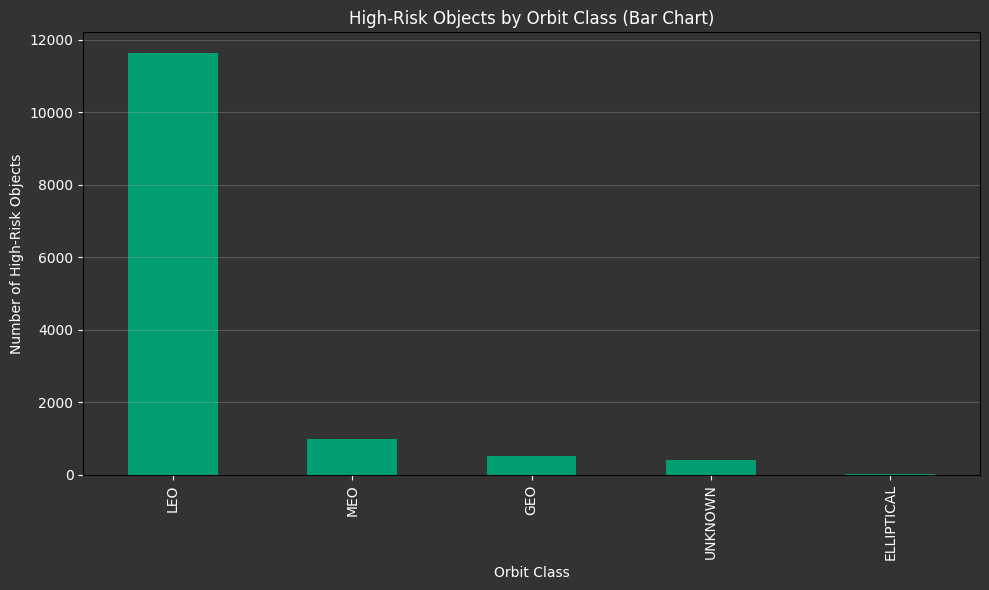

In [15]:
# Group high-risk objects by orbit class
if 'orbit_class' in df_high_risk.columns:
    orbit_counts = df_high_risk['orbit_class'].value_counts().sort_values(ascending=False)
    
    plt.figure(figsize=(10,6))
    orbit_counts.plot(kind='bar', color=COLOR_PALETTE[2])
    
    plt.title('High-Risk Objects by Orbit Class (Bar Chart)')
    plt.xlabel('Orbit Class')
    plt.ylabel('Number of High-Risk Objects')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../charts/hr_orbit_class_exp.png', bbox_inches='tight', dpi=100)  
    plt.show()
else:
    print('orbit_class column not found in high-risk data.')

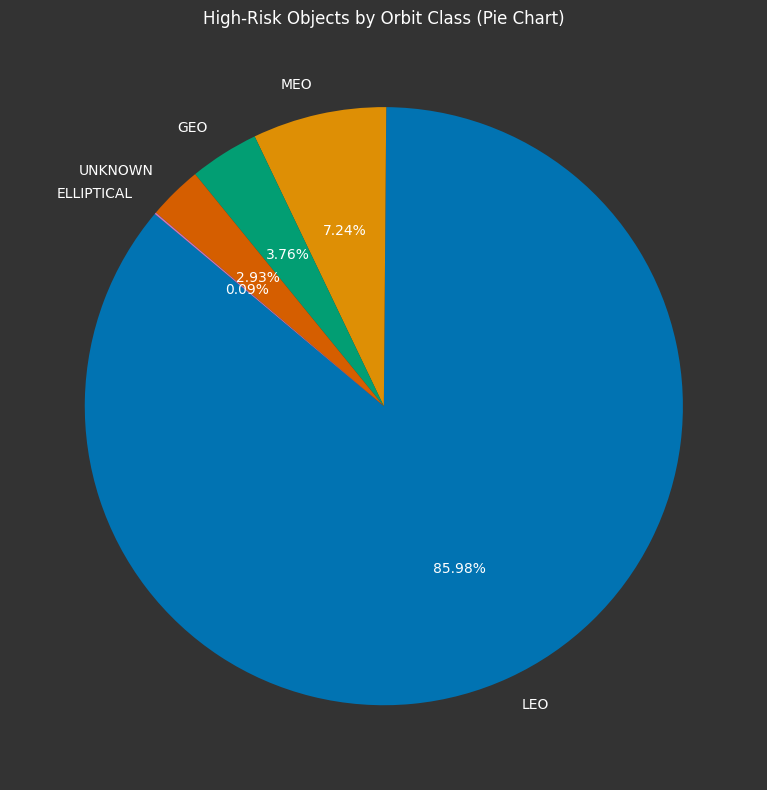

In [16]:
# pie chart of high-risk objects by orbit class
if 'orbit_class' in df_high_risk.columns:
    orbit_counts = df_high_risk['orbit_class'].value_counts()
    
    plt.figure(figsize=(8,8))
    plt.pie(orbit_counts, labels=orbit_counts.index, autopct='%1.2f%%', startangle=140, colors=COLOR_PALETTE)
    
    plt.title('High-Risk Objects by Orbit Class (Pie Chart)')
    plt.ylabel('')
    
    plt.tight_layout()
    plt.savefig('../charts/hr_orbit_class_pie_exp.png', bbox_inches='tight', dpi=100)  
    plt.show()
else:
    print('orbit_class column not found in high-risk data.')

### High Risk Object Distribution by Altitude Band and Orbit Class

Focus on how in-orbit high-risk objects are distributed across defined altitude bands and orbit classes, revealing where high risk object congestion is highest and which orbit classes dominate each region.

**Method:**
- Define altitude bands (e.g., 0–200 km, 200–400 km, 400–600 km, etc.) based on the midpoint of apogee and perigee.
- Filter high-risk objects to those in orbit (exclude decayed objects).
- Group and count objects by both altitude band and orbit class.
- Pivot the result for visualization.

**Visuals:**
- A stacked bar chart showing the number of high-risk objects in each altitude band, with colors representing different orbit classes. Each bar segment is labeled with its count for clarity.

**How to Read This:**
- Taller bars indicate more objects in that altitude band.
- The color segments show how the population is split among orbit classes at each altitude.
- Look for bands with especially high counts or dominated by a single orbit class—these are key regions for congestion and risk.

In [17]:
object_distribution_alt_bands_query = """
SELECT
  satellites.norad_id,
  COALESCE(orbital_data.orbit_class, 'UNKNOWN') AS orbit_class,
  orbital_data.proxy_mass_kg,
  (orbital_data.apogee_km + orbital_data.perigee_km) / 2.0 AS altitude_km,
  risk_assessment.velocity_kms,
  risk_assessment.kinetic_joules,
  CASE
    WHEN (orbital_data.apogee_km + orbital_data.perigee_km) / 2.0 < 200 THEN   '<= 200 km'
    WHEN (orbital_data.apogee_km + orbital_data.perigee_km) / 2.0 < 400 THEN   '200-400 km'
    WHEN (orbital_data.apogee_km + orbital_data.perigee_km) / 2.0 < 600 THEN   '400-600 km'
    WHEN (orbital_data.apogee_km + orbital_data.perigee_km) / 2.0 < 800 THEN   '600-800 km'
    WHEN (orbital_data.apogee_km + orbital_data.perigee_km) / 2.0 < 1000 THEN  '800-1000 km'
    WHEN (orbital_data.apogee_km + orbital_data.perigee_km) / 2.0 < 2000 THEN  '1000-2000 km'
    WHEN (orbital_data.apogee_km + orbital_data.perigee_km) / 2.0 < 35000 THEN '2000-35000 km'
    ELSE '35000+ km'
  END AS altitude_band
FROM satellites
JOIN orbital_data ON satellites.norad_id = orbital_data.norad_id
JOIN risk_assessment ON satellites.norad_id = risk_assessment.norad_id
WHERE satellites.in_orbit = 1 
  AND risk_assessment.kinetic_joules IS NOT NULL
ORDER BY altitude_band, orbit_class;
"""

df_object_alt_band = pd.read_sql_query(object_distribution_alt_bands_query, orbital_debris_conn)

df_object_alt_band['risk_category'] = df_object_alt_band.apply(utils.classify_risk_category, axis=1)
df_high_risk = df_object_alt_band[df_object_alt_band['risk_category'] == 'Extremely High Risk'].copy()

df_high_risk.to_parquet('../data/clean/results/object_distribution_alt_bands_exp.parquet', index=False)

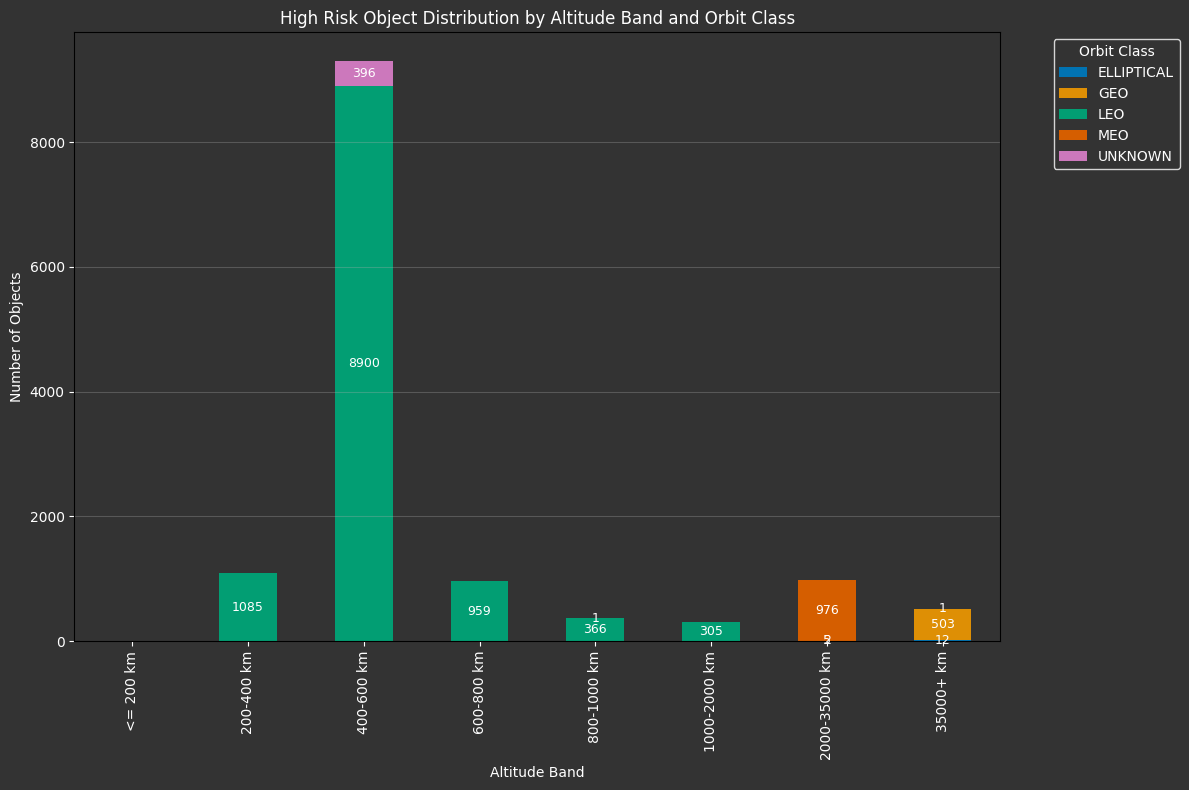

In [18]:
# Bar graph of high-risk object distribution by altitude band and orbit class
if not df_high_risk.empty:
  alt_orbit_counts = df_high_risk.pivot_table(
      index='altitude_band',
      columns='orbit_class',
      values='norad_id',
      aggfunc='count',
      fill_value=0
  )
  
  band_order = ['<= 200 km', '200-400 km', '400-600 km', '600-800 km', '800-1000 km', '1000-2000 km', '2000-35000 km', '35000+ km']
  alt_orbit_counts = alt_orbit_counts.reindex(band_order)
  
  fig, ax = plt.subplots(figsize=(12,8))
  alt_orbit_counts.plot(kind='bar', stacked=True, ax=ax, color=COLOR_PALETTE)
  
  for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(
          bar.get_x() + bar.get_width() / 2,
          bar.get_y() + height / 2,
          f'{int(height)}',
          ha='center',
          va='center',
          fontsize=9,
          color='white'
        )
        
  ax.set_title('High Risk Object Distribution by Altitude Band and Orbit Class')
  ax.set_xlabel('Altitude Band')
  ax.set_ylabel('Number of Objects')
  ax.grid(axis='y', alpha=0.3)
  ax.legend(title='Orbit Class', bbox_to_anchor=(1.05, 1), loc='upper left')
  
  plt.tight_layout()
  plt.savefig('../charts/high_risk_object_distribution_alt_bands_exp.png', bbox_inches='tight', dpi=100)
  plt.show()
else:
  print('df_high_risk DataFrame is empty.')

### Altitude Band Analysis: 400–600 km LEO High-Risk Objects

Focus on high-risk objects in the 400–600 km altitude band (LEO), a region of particular congestion and risk.

**Method:**
- Filter high-risk objects for those with altitude between 400 and 600 km.

**Visuals:**
- A histogram of their altitudes to show distribution concentration across that entire altitude band.

**How to Read This:**
- Higher bars show where more high-risk objects cluster inside the 400-600 km range.
- Peaks suggest especially crowded altitude zones.
- A narrow, tall peak means congestion is concentrated in a smaller altitude slice.

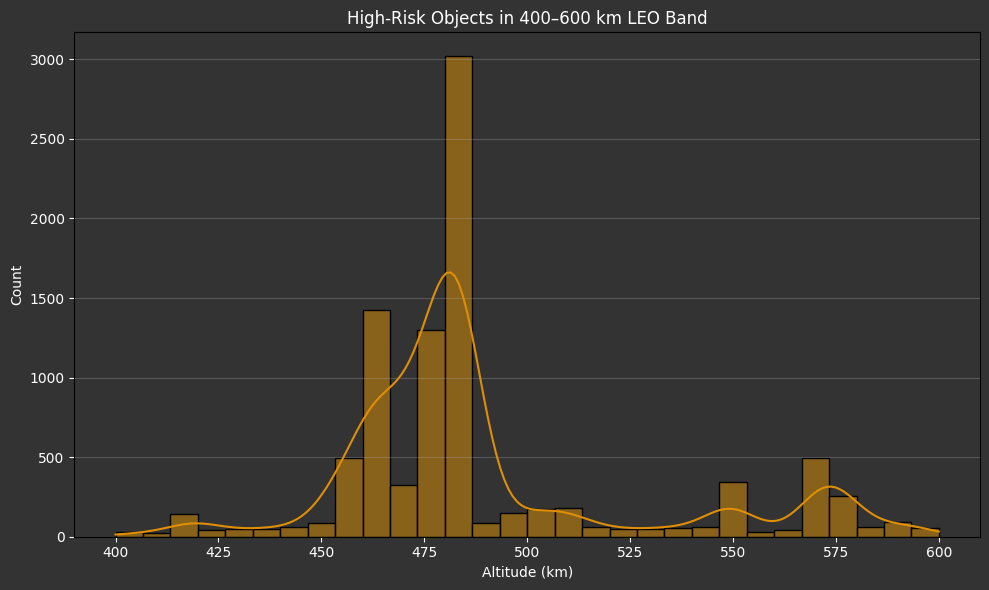

Objects in 400 - 600 km band: 9297


In [19]:
# Filter for 400–600 km LEO high-risk objects
if 'altitude_km' in df_high_risk.columns:
  leo_band = df_high_risk[(df_high_risk['altitude_km'] >= 400) & (df_high_risk['altitude_km'] <= 600)]
  
  plt.figure(figsize=(10,6))
  sns.histplot(leo_band['altitude_km'], bins=30, kde=True, color=COLOR_PALETTE[1])
  
  plt.title('High-Risk Objects in 400–600 km LEO Band')
  plt.xlabel('Altitude (km)')
  plt.ylabel('Count')
  plt.grid(axis='y', alpha=0.3)
  
  plt.tight_layout()
  plt.savefig('../charts/high_risk_banded_exp.png', bbox_inches='tight', dpi=100)
  plt.show()
  
  print(f'Objects in 400 - 600 km band: {len(leo_band)}')
else:
  print('altitude column not found in high-risk data.')

## Zombie Payload Concentrations

Measure how many in-orbit payload satellites are no longer operational ("zombie" payloads), identify who operates them, and show how concentrated ownership is across operator groups.

**Explore:**
- Operational Status: Share of operational vs. non-operational in-orbit payloads
- Zombie Payloads by Owner/Operator: Which owner/operator groups have the most non-operational ("zombie") payloads
- Ownership/Operator Diversity: Number of unique owner/operator pairs and their in-orbit payload counts

### Operational Status: Share of operational vs. non-operational payloads

Estimate the current in-orbit payload status mix, focusing on operational vs. non-operational payloads.

**Method:**
- Query all in-orbit payloads and keep status values, assigning missing values to "UNKNOWN".
- Count payloads by status.
- Calculate share for each status and report key operational vs. non-operational percentages.

**Output:**
- Report the total payload count, the count of operational, and the count of non-operational payloads.
- Display full count and percentage results for each status in table format.

**Visuals:**
- A bar chart showing counts across all available payload status categories (OPERATIONAL, NON-OPERATIONAL, PARTIAL, EXTENDED MISSION, BACKUP/STANDBY, STANDBY, DECAYED, UNKNOWN).

**How to Read This:**
- Taller bars mean more payloads in that status category.
- To compare operational vs non-operational burden, combine the relevant status buckets with the printed summary metrics.
- A large UNKNOWN bar suggests data quality limits. It should be considered in conclusions, as it may hide a significant number of non-operational payloads.

**Data limits:**
- Status values depend on source data quality and update frequency.
- "UNKNOWN" can include truly unknown and missing statuses.

Total in-orbit payloads in this status view: 19085
Operational: 15508 (81.26%)
Non-operational: 1495 (7.83%)


,status_count,status_share
ops_status,,
OPERATIONAL,15508,0.812575
NON-OPERATIONAL,1495,0.078334
PARTIAL,528,0.027666
EXTENDED MISSION,16,0.000838
BACKUP/STANDBY,23,0.001205
STANDBY,6,0.000314
DECAYED,0,0.000000
UNKNOWN,1509,0.079067


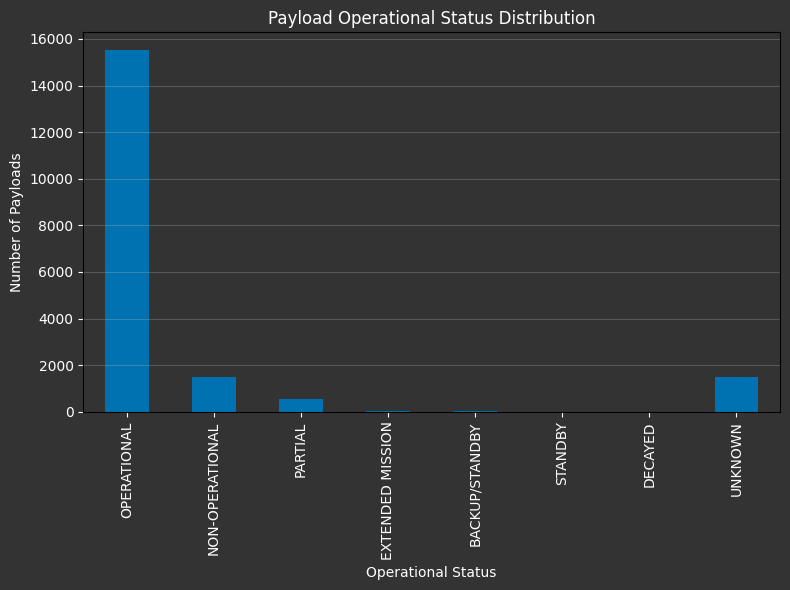

In [20]:
ops_status_query = """
SELECT
  satellites.norad_id,
  launch_events.launch_date,
  satellites.object_type,
  COALESCE(satellites.ops_status, 'UNKNOWN') AS ops_status
FROM satellites
LEFT JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE satellites.object_type = 'PAYLOAD'
  AND satellites.in_orbit = 1
ORDER BY launch_events.launch_date ASC;
"""

df_ops_status = pd.read_sql_query(ops_status_query, orbital_debris_conn)
df_ops_status.to_parquet('../data/clean/results/ops_status_query_exp.parquet', index=False)

status_order = [
  'OPERATIONAL',
  'NON-OPERATIONAL',
  'PARTIAL',
  'EXTENDED MISSION',
  'BACKUP/STANDBY',
  'STANDBY',
  'DECAYED',
  'UNKNOWN'
 ]

if df_ops_status.empty:
  print('No in-orbit payload status data returned. Skipping status chart.')
else:
  status_counts = df_ops_status['ops_status'].value_counts().reindex(status_order, fill_value=0)
  total_payloads = int(status_counts.sum())
  status_share = (status_counts / total_payloads).fillna(0)

  op_count = int(status_counts.get('OPERATIONAL', 0))
  non_op_count = int(status_counts.get('NON-OPERATIONAL', 0))
  op_share = op_count / total_payloads if total_payloads else 0
  non_op_share = non_op_count / total_payloads if total_payloads else 0

  print(f'Total in-orbit payloads in this status view: {total_payloads}')
  print(f'Operational: {op_count} ({op_share:.2%})')
  print(f'Non-operational: {non_op_count} ({non_op_share:.2%})')

  display(
      pd.DataFrame({
          'status_count': status_counts,
          'status_share': status_share
      })
  )

  plt.figure(figsize=(8,6))
  status_counts.plot(kind='bar', color='#0072B2')
  plt.title('Payload Operational Status Distribution')
  plt.xlabel('Operational Status')
  plt.ylabel('Number of Payloads')
  plt.grid(axis='y', alpha=0.3)

  plt.tight_layout()
  plt.savefig('../charts/ops_status_distribution_exp.png', bbox_inches='tight', dpi=100)
  plt.show()


### Zombie Payloads by Owner/Operator: Top Zombie Contributors

Show which owner or operator groups have the most non-operational in-orbit payloads and how zombie ownership concentration compares with total ownership concentration.

**Method:**
- Build the in-orbit payload set with owner and operator fields.
- Filter to non-operational payloads.
- Group by owner and operator, then count zombie payloads.
- Show the top groups and roll the rest into `OTHER` so the chart stays readable.

**Visuals:**
- Grouped status-mix bar chart for top owner/operator groups.
- Zombie-only top-contributor bar chart.
- Top owner/operator total payload bar chart.
- Top owner/operator payload-share pie chart.

**How to Read This:**
- The zombie-only chart highlights where inactive payload concentration is highest.
- The status-mix chart shows whether top groups are mostly operational, zombie, or mixed.
- Compare total-payload and zombie-only charts to spot groups with outsized zombie burdens relative to their overall footprint.

### Ownership/Operator Diversity: Number of unique owners/operators and their object counts

Add context for how concentrated in-orbit payload ownership is and how status composition varies across top owner/operator groups.

**Method:**
- Count unique owner and operator pairs in the in-orbit payload set.
- Build top owner/operator summaries with counts by status bucket.
- Compare total payload concentration to zombie-only concentration.

**Status buckets used in this section:**
- **Operational Payloads:** `ops_status = OPERATIONAL`
- **Non-Operational Payloads (Zombie):** `ops_status = NON-OPERATIONAL`
- **Misc Status Payloads:** `ops_status` in `PARTIAL`, `EXTENDED MISSION`, `BACKUP/STANDBY`, `STANDBY`
- **Unknown Status Payloads:** `ops_status = UNKNOWN` and missing values mapped to `UNKNOWN`

**Data limits:**
- Missing owner or operator mappings are grouped as `UNKNOWN`, which can affect concentration estimates.

In [21]:
base_contrib_query = """
SELECT
  satellites.norad_id,
  COALESCE(ownership_operators.owner, 'UNKNOWN') AS owner,
  COALESCE(ownership_operators.country_operator, 'UNKNOWN') AS country_operator,
  COALESCE(ownership_operators.contractor, 'UNKNOWN') AS contractor,
  COALESCE(ownership_operators.contractor_country, 'UNKNOWN') AS contractor_country,
  COALESCE(ownership_operators.users, 'UNKNOWN') AS users,
  COALESCE(satellites.ops_status, 'UNKNOWN') AS ops_status
FROM satellites
LEFT JOIN ownership_operators ON satellites.owner_code = ownership_operators.owner_code
WHERE satellites.object_type = 'PAYLOAD'
  AND satellites.in_orbit = 1;
"""

df_contrib = pd.read_sql_query(base_contrib_query, orbital_debris_conn)
df_contrib.to_parquet('../data/clean/results/base_contrib_exp.parquet', index=False)

df_zombie_contributors = df_contrib[df_contrib['ops_status'] == 'NON-OPERATIONAL'].copy()

# Use a lightweight count query instead of pulling all joined tables/columns.
total_in_orbit_objects_query = """
SELECT
  COUNT(*) AS total_in_orbit_objects
FROM satellites
WHERE satellites.in_orbit = 1;
"""

total_in_orbit_objects = int(
  pd.read_sql_query(total_in_orbit_objects_query, orbital_debris_conn)['total_in_orbit_objects'].iloc[0]
)

# Safe defaults let downstream cells run even if this query comes back empty.
owner_counts = pd.DataFrame(columns=['owner', 'country_operator', 'object_count'])
operational_counts = pd.DataFrame(columns=['owner', 'country_operator', 'operational_count'])
zombie_counts = pd.DataFrame(columns=['owner', 'country_operator', 'zombie_count'])
misc_counts = pd.DataFrame(columns=['owner', 'country_operator', 'misc_count'])
unknown_counts = pd.DataFrame(columns=['owner', 'country_operator', 'unknown_count'])
zombie_owner_counts = pd.DataFrame(columns=['owner', 'country_operator', 'zombie_payload_count'])
top_owners = pd.DataFrame(columns=['owner', 'country_operator', 'object_count', 'operational_count', 'zombie_count', 'misc_count', 'unknown_count', 'first_year', 'last_year', 'payload_pct'])

df_types_all_years = df_type_year.copy()

if not df_contrib.empty and not df_types_all_years.empty:
  first_launch_year = pd.to_datetime(df_types_all_years['launch_date'], errors='coerce').dt.year.min()
  last_launch_year = pd.to_datetime(df_types_all_years['launch_date'], errors='coerce').dt.year.max()

  # Build each status count separately, then merge them into one summary table.
  owner_counts = (
    df_contrib
    .groupby(['owner', 'country_operator'])
    .size()
    .reset_index(name='object_count')
    .sort_values('object_count', ascending=False)
    .copy()
  )

  operational_counts = (
    df_contrib[df_contrib['ops_status'] == 'OPERATIONAL']
    .groupby(['owner', 'country_operator'])
    .size()
    .reset_index(name='operational_count')
  )

  zombie_counts = (
    df_contrib[df_contrib['ops_status'] == 'NON-OPERATIONAL']
    .groupby(['owner', 'country_operator'])
    .size()
    .reset_index(name='zombie_count')
  )

  misc_counts = (
    df_contrib[df_contrib['ops_status'].isin(['PARTIAL', 'EXTENDED MISSION', 'BACKUP/STANDBY', 'STANDBY'])]
    .groupby(['owner', 'country_operator'])
    .size()
    .reset_index(name='misc_count')
  )

  unknown_counts = (
    df_contrib[df_contrib['ops_status'] == 'UNKNOWN']
    .groupby(['owner', 'country_operator'])
    .size()
    .reset_index(name='unknown_count')
  )
  
  zombie_owner_counts = (
      df_zombie_contributors
      .groupby(['owner', 'country_operator'])
      .size()
      .reset_index(name='zombie_payload_count')
      .sort_values('zombie_payload_count', ascending=False)
      .copy()
  )
  
  # Add first and last launch year for each owner/operator pair.
  activity_span = (
    df_contrib
    .merge(df_types_all_years[['norad_id', 'launch_year']], on='norad_id', how='left')
    .groupby(['owner', 'country_operator'])
    .agg(first_year=('launch_year', 'min'), last_year=('launch_year', 'max'))
    .reset_index()
  )
  
  # Start with the top owner/operator groups, then merge in status counts and year span.
  top_owners = owner_counts.head(MAX_TOP).copy()
  top_owners = top_owners.merge(operational_counts, on=['owner', 'country_operator'], how='left')
  top_owners = top_owners.merge(zombie_counts, on=['owner', 'country_operator'], how='left')
  top_owners = top_owners.merge(misc_counts, on=['owner', 'country_operator'], how='left')
  top_owners = top_owners.merge(unknown_counts, on=['owner', 'country_operator'], how='left')
  top_owners = top_owners.merge(activity_span, on=['owner', 'country_operator'], how='left')
  top_owners[['operational_count', 'zombie_count', 'misc_count', 'unknown_count']] = top_owners[['operational_count', 'zombie_count', 'misc_count', 'unknown_count']].fillna(0).astype(int)

  # Roll everyone outside the top group into one OTHER row.
  all_others_count = owner_counts['object_count'].sum() - top_owners['object_count'].sum()
  all_others_operational = operational_counts['operational_count'].sum() - top_owners['operational_count'].sum()
  all_others_zombie = zombie_counts['zombie_count'].sum() - top_owners['zombie_count'].sum()
  all_others_misc = misc_counts['misc_count'].sum() - top_owners['misc_count'].sum()
  all_others_unknown = unknown_counts['unknown_count'].sum() - top_owners['unknown_count'].sum()

  if all_others_count > 0:
    other_row = pd.DataFrame([{
      'owner': 'OTHER',
      'country_operator': f'{max(len(owner_counts) - MAX_TOP, 0)} FILTERED OWNER/OPERATORS',
      'object_count': all_others_count,
      'operational_count': all_others_operational,
      'zombie_count': all_others_zombie,
      'misc_count': all_others_misc,
      'unknown_count': all_others_unknown,
      'first_year': first_launch_year,
      'last_year': last_launch_year
    }])
    top_owners = pd.concat([top_owners, other_row], ignore_index=True)

  # Apply the same OTHER logic to the zombie-only table so both views stay aligned.
  top_zombie_owners = zombie_owner_counts.head(MAX_TOP).copy()
  zombie_other_count = zombie_owner_counts['zombie_payload_count'].sum() - top_zombie_owners['zombie_payload_count'].sum()
  zombie_other_groups = len(zombie_owner_counts) - len(top_zombie_owners)

  if zombie_other_count > 0:
    zombie_other_row = pd.DataFrame([{
      'owner': 'OTHER',
      'country_operator': f'{zombie_other_groups} FILTERED OWNER/OPERATORS',
      'zombie_payload_count': zombie_other_count
    }])
    zombie_owner_counts = pd.concat([top_zombie_owners, zombie_other_row], ignore_index=True)
  else:
    zombie_owner_counts = top_zombie_owners

  total_payload_count = owner_counts['object_count'].sum()
  top_owners['payload_pct'] = (top_owners['object_count'] / total_payload_count * 100).round(2)
  
  top_owners.to_parquet('../data/clean/results/top_owners_full.parquet', index=False)
else:
  print('One or more required dataframes are empty. Skipping contributor prep.')

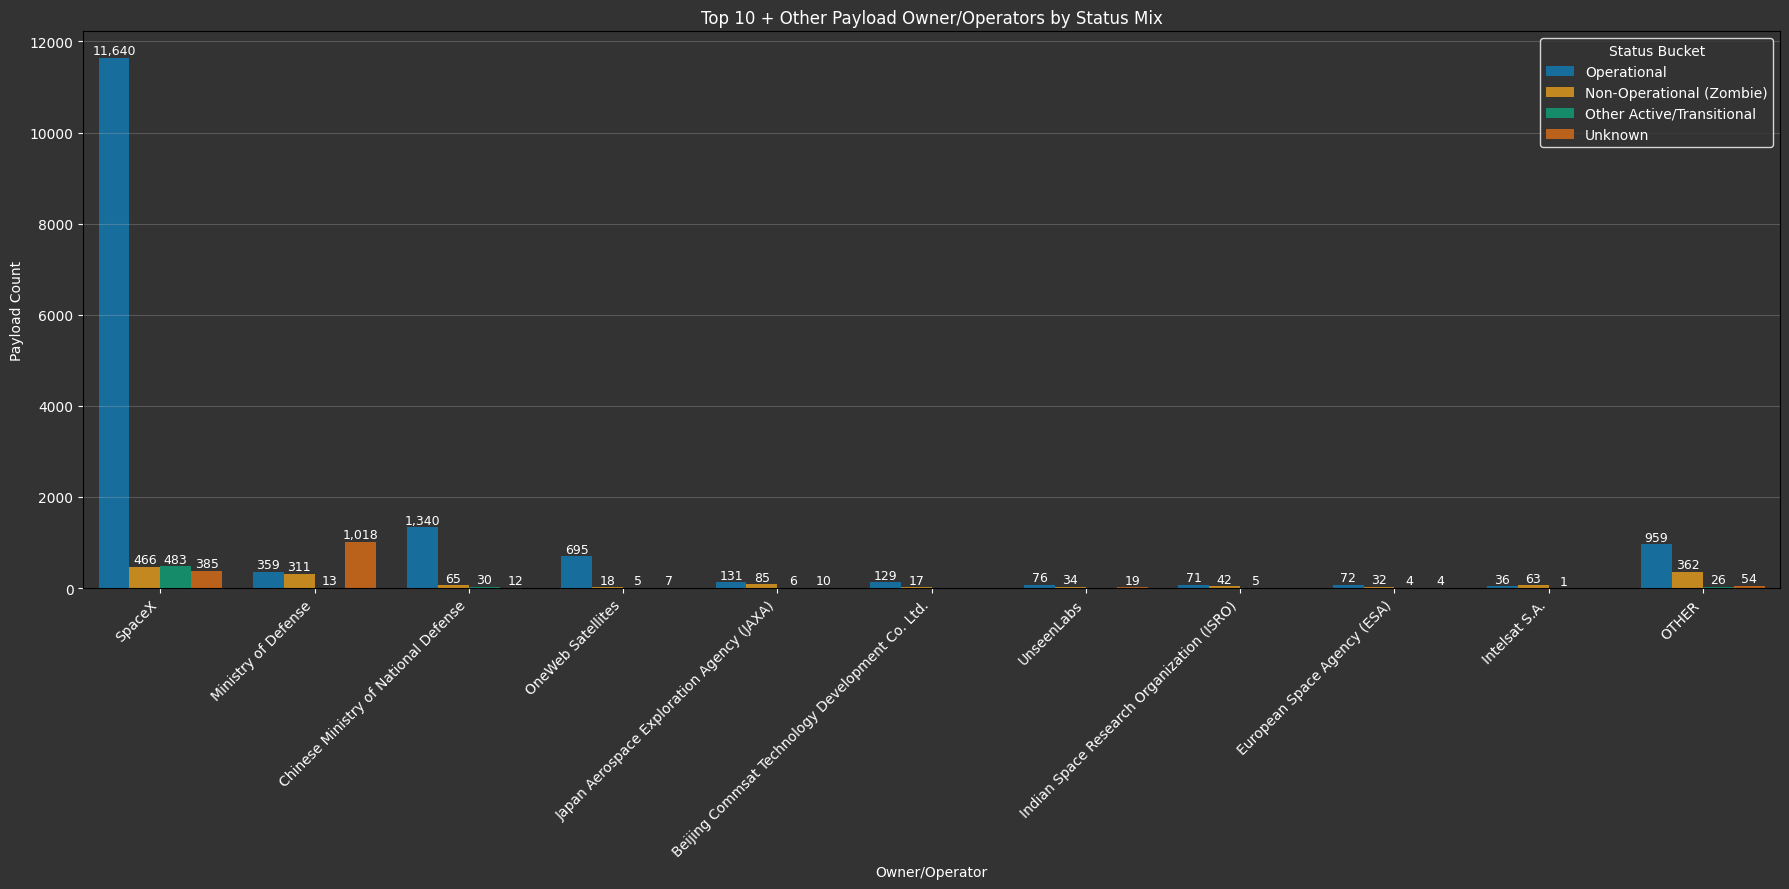

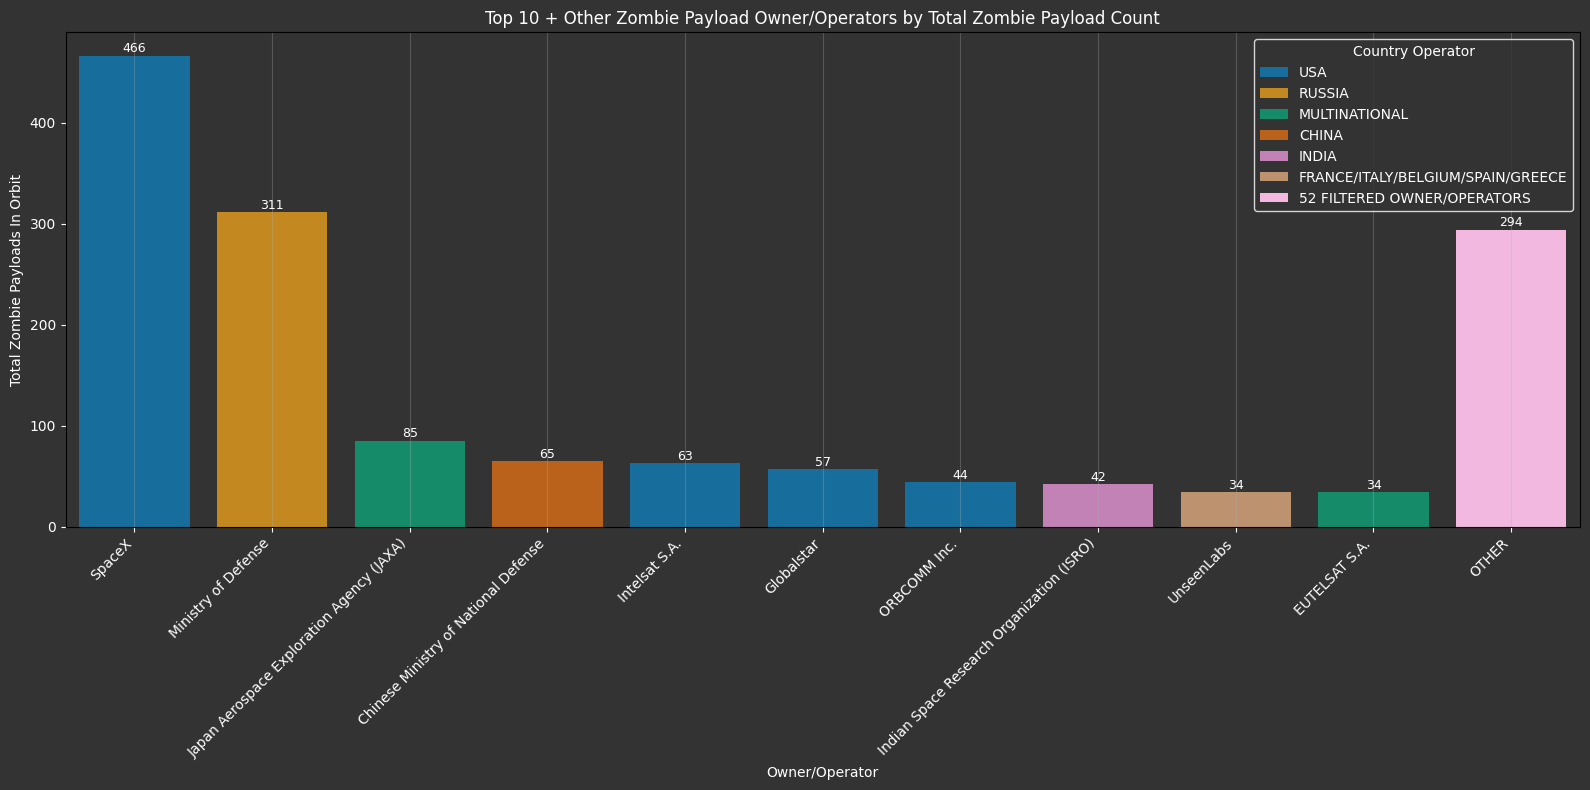

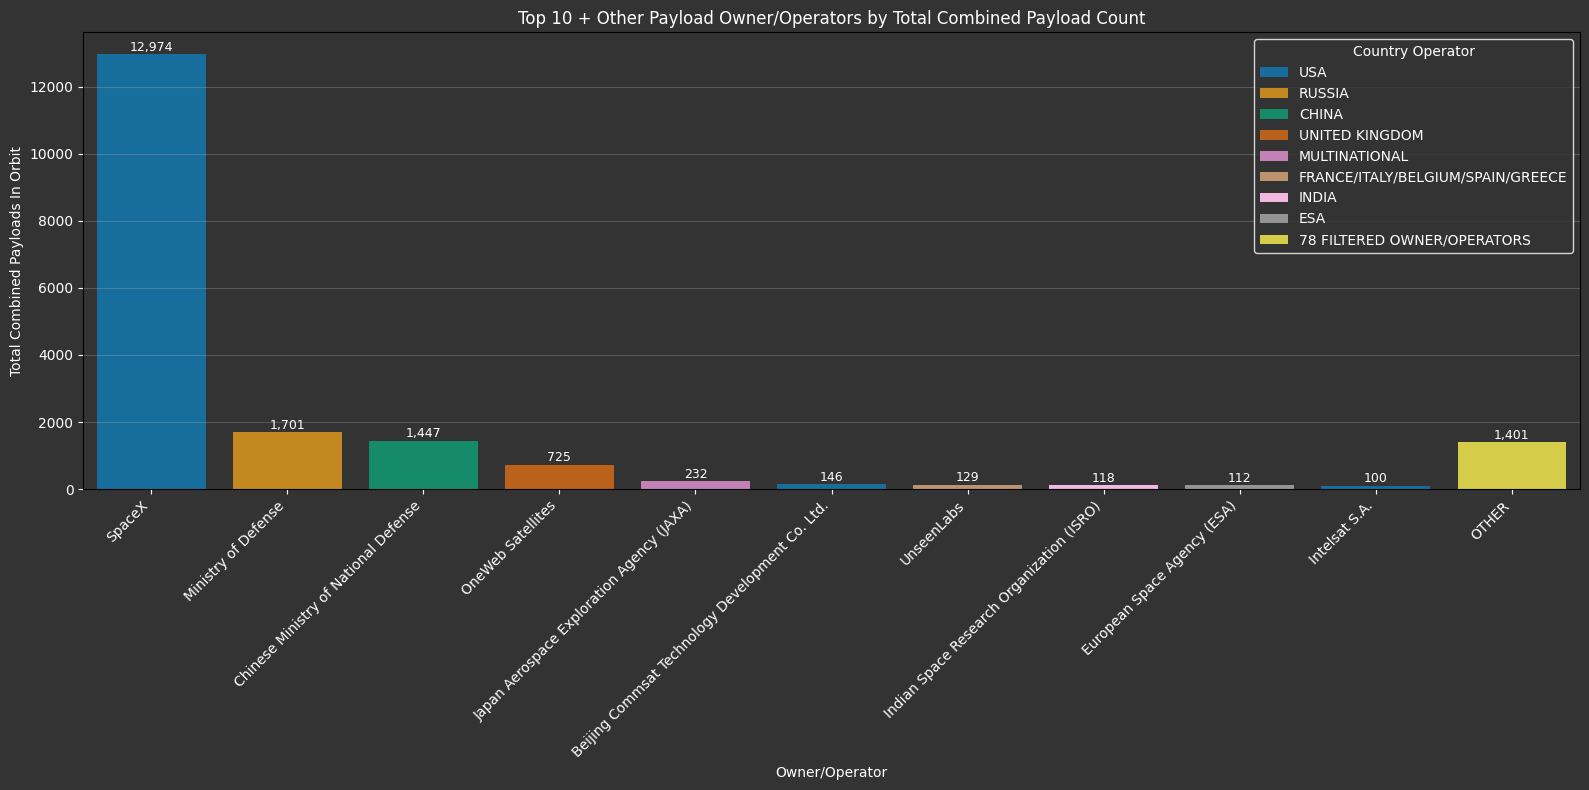

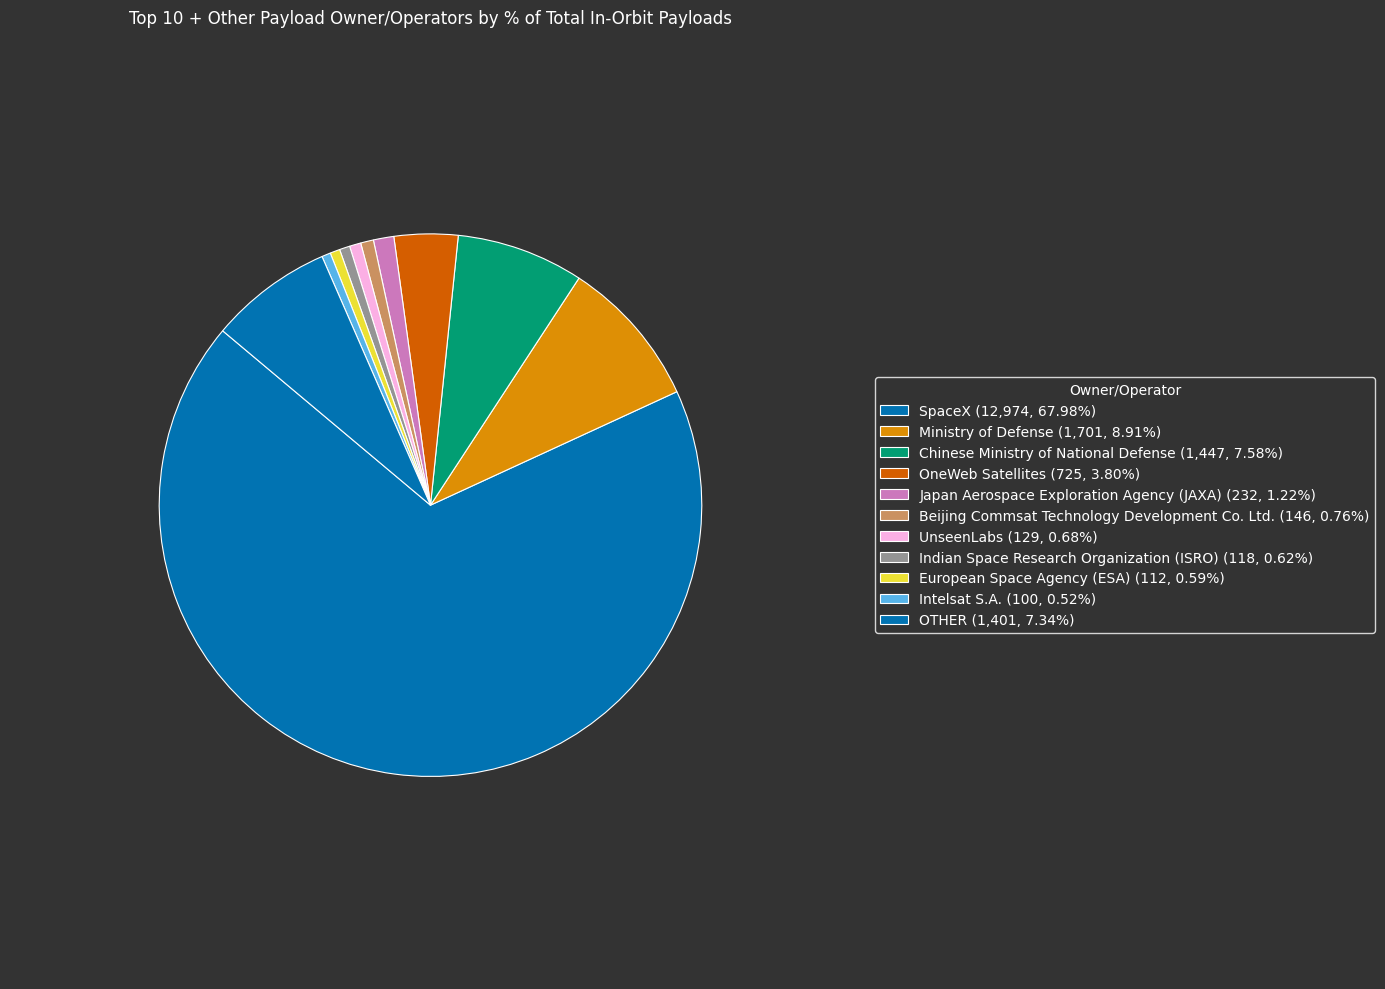

In [22]:
if top_owners.empty:
  print('No contributor data available for ownership charts.')
else:
  # Grouped status mix by owner/operator (operational, zombie, misc, unknown).
  plot_df = top_owners.copy()
  top_owner_label = f'Top {MAX_TOP} + Other' if (plot_df['owner'] == 'OTHER').any() else f'Top {MAX_TOP}'
  zombie_owner_label = (
    f'Top {MAX_TOP} + Other'
    if not zombie_owner_counts.empty and (zombie_owner_counts['owner'] == 'OTHER').any()
    else f'Top {MAX_TOP}'
  )

  status_cols = ['operational_count', 'zombie_count', 'misc_count', 'unknown_count']

  for col in status_cols:
    if col not in plot_df.columns:
      plot_df[col] = 0

  status_long = plot_df.melt(
    id_vars=['owner', 'country_operator'],
    value_vars=status_cols,
    var_name='status_bucket',
    value_name='count'
  )
  
  status_labels = {
    'operational_count': 'Operational',
    'zombie_count': 'Non-Operational (Zombie)',
    'misc_count': 'Other Active/Transitional',
    'unknown_count': 'Unknown'
  }
  
  status_long['status_bucket'] = status_long['status_bucket'].map(status_labels)

  plt.figure(figsize=(18, 9))
  
  sns.barplot(data=status_long, x='owner', y='count', hue='status_bucket')
  
  # annotate bars with counts
  for p in plt.gca().patches:
    height = p.get_height()
    
    if height > 0:
      plt.gca().annotate(
          f'{int(height):,}',
          (p.get_x() + p.get_width() / 2., height),
          ha='center',
          va='center',
          fontsize=9,
          color='white',
          xytext=(0, 5),
          textcoords='offset points'
      )
      
  plt.title(f'{top_owner_label} Payload Owner/Operators by Status Mix')
  plt.xlabel('Owner/Operator')
  plt.ylabel('Payload Count')
  plt.xticks(rotation=45, ha='right')
  plt.grid(axis='y', alpha=0.3)
  plt.legend(title='Status Bucket', loc='upper right', frameon=True)
  
  plt.tight_layout()
  plt.savefig('../charts/owner_status_mix_exp.png', bbox_inches='tight', dpi=100)
  plt.show()

  # Bar chart of top contributing owners to zombie payloads
  plt.figure(figsize=(16, 8))
  sns.barplot(
    data=zombie_owner_counts,
    x='owner',
    y='zombie_payload_count',
    hue='country_operator',
    palette='colorblind',
    legend=True
  )

  # annotate bars with counts
  for p in plt.gca().patches:
    height = p.get_height()
    
    if height > 0:
      plt.gca().annotate(
          f'{int(height):,}',
          (p.get_x() + p.get_width() / 2., height),
          ha='center',
          va='center',
          fontsize=9,
          color='white',
          xytext=(0, 5),
          textcoords='offset points'
      )
      
  plt.title(f'{zombie_owner_label} Zombie Payload Owner/Operators by Total Zombie Payload Count')
  plt.xlabel('Owner/Operator')
  plt.ylabel('Total Zombie Payloads In Orbit')
  plt.xticks(rotation=45, ha='right')
  plt.grid(axis='x', alpha=0.3)
  plt.legend(title='Country Operator', loc='upper right', frameon=True)

  plt.tight_layout()
  plt.savefig('../charts/zombie_top_contributors_exp.png', bbox_inches='tight', dpi=100)
  plt.show()
  
  # Bar chart of top owners by total payload count
  plt.figure(figsize=(16, 8))
  
  sns.barplot(data=top_owners, x='owner', y='object_count', hue='country_operator', palette='colorblind')

  # annotate bars with counts
  for p in plt.gca().patches:
    height = p.get_height()
    
    if height > 0:
      plt.gca().annotate(
          f'{int(height):,}',
          (p.get_x() + p.get_width() / 2., height),
          ha='center',
          va='center',
          fontsize=9,
          color='white',
          xytext=(0, 5),
          textcoords='offset points'
      )

  plt.title(f'{top_owner_label} Payload Owner/Operators by Total Combined Payload Count')
  plt.xlabel('Owner/Operator')
  plt.ylabel('Total Combined Payloads In Orbit')
  plt.xticks(rotation=45, ha='right')
  plt.grid(axis='y', alpha=0.3)
  plt.legend(title='Country Operator', loc='upper right', frameon=True)

  plt.tight_layout()
  plt.savefig('../charts/contribution_report_top_owners_exp.png', bbox_inches='tight', dpi=100)
  plt.show()

  # Pie chart with side legend (stats moved to legend labels)
  plt.figure(figsize=(14, 10))

  # Create a copy of the top_owners dataframe so we don't modify the original.
  top_owners_pie = top_owners.copy()

  # Calculate percentages and create the legend labels with the owner name, count, and percentage.
  total_in_pie = top_owners_pie['object_count'].sum()
  top_owners_pie['pct_of_total'] = (top_owners_pie['object_count'] / total_in_pie * 100).round(2)
  top_owners_pie['legend_label'] = top_owners_pie.apply(
      lambda r: f"{r['owner']} ({int(r['object_count']):,}, {r['pct_of_total']:.2f}%)",
      axis=1
  )

  # Create the pie chart without labels because we're using a legend with our custom labels stored in legend_label.
  wedges, _ = plt.pie(
      top_owners_pie['object_count'],
      labels=None,
      startangle=140,
      counterclock=True,
      wedgeprops=dict(edgecolor='white', linewidth=0.8),
  )

  plt.title(f'{top_owner_label} Payload Owner/Operators by % of Total In-Orbit Payloads')

  # Set the legend with custom wedge labels that include the owner name, count, and percentage.
  plt.legend(
      wedges,
      top_owners_pie['legend_label'],
      title='Owner/Operator',
      loc='center left',
      bbox_to_anchor=(1.02, 0.5),
      frameon=True
  )

  plt.axis('equal')
  plt.tight_layout()
  plt.savefig('../charts/contribution_report_top_owners_pie_exp.png', bbox_inches='tight', dpi=100)
  plt.show()


In [23]:
if top_owners.empty:
  print('No contributor summary available for payload ownership report.')
else:
  top_owner_report_label = f'Top {MAX_TOP} + Other' if (top_owners['owner'] == 'OTHER').any() else f'Top {MAX_TOP}'
  export_suffix = 'top15_plus_other' if (top_owners['owner'] == 'OTHER').any() else 'top15'
  report_owners = f"""
### **Payload Contribution ({top_owner_report_label}) Owner/Operator Statistics**  

| Owner | Country Operator | Operational Payload Count | Zombie Payload Count | Misc Status Count | Unknown Status Count | Total Payloads | % of Total Payloads | First Year | Last Year |
| :---- | :--------------- | ------------: | ---------: | ---------: | ---------: | --------: | -------: | --------: | --------: |
"""

  for _, row in top_owners.iterrows():
    fy = '-' if pd.isna(row['first_year']) else int(row['first_year'])
    ly = '-' if pd.isna(row['last_year']) else int(row['last_year'])
    misc_val = int(row['misc_count']) if 'misc_count' in row else 0
    unknown_val = int(row['unknown_count']) if 'unknown_count' in row else 0
    report_owners += (
        f"| **{row['owner']}** | **{row['country_operator']}** | **{int(row['operational_count'])}** "
        f"| **{int(row['zombie_count'])}** | **{misc_val}** | **{unknown_val}** "
        f"| **{row['object_count']}** | **{row['payload_pct']:.2f}%** | **{fy}** | **{ly}** |\n"
    )

  total_operational_payloads = int(df_contrib[df_contrib['ops_status'] == 'OPERATIONAL'].shape[0])
  total_payloads = int(df_contrib.shape[0])
  total_non_operational_payloads = int(df_contrib[df_contrib['ops_status'] == 'NON-OPERATIONAL'].shape[0])
  total_misc_payloads = int(
      df_contrib[
          df_contrib['ops_status'].isin(['PARTIAL', 'EXTENDED MISSION', 'BACKUP/STANDBY', 'STANDBY'])
      ].shape[0]
  )
  total_unknown_payloads = int(df_contrib[df_contrib['ops_status'] == 'UNKNOWN'].shape[0])
  total_non_payloads = int(total_in_orbit_objects - total_payloads)

  report_payloads = f"""
| **In-Orbit Payload Breakdown** | Count |
| :----------------------------- | ----: |
| **Unique Payload Owner/Operator Pairs** | **{len(owner_counts)}** |
| **Total Remaining Payloads** | **{total_payloads}** |
| **Total Remaining Operational Payloads** | **{total_operational_payloads}** |
| **Total Remaining Non-Operational Payloads** | **{total_non_operational_payloads}** |
| **Total Remaining Misc Status Payloads** | **{total_misc_payloads}** |
| **Total Remaining Unknown Status Payloads** | **{total_unknown_payloads}** |
| **Total Remaining Other Status Payloads** | **{total_non_operational_payloads + total_misc_payloads + total_unknown_payloads}** |
| **Total Remaining Non-Payloads** | **{total_non_payloads}** |
"""

  top_owner_stats_export = top_owners.copy()

  # We definitely want to save this table because it will likely be useful for later story questions.
  top_owner_stats_export.to_parquet(
      f'../data/clean/results/payload_contribution_{export_suffix}_exp.parquet',
      index=False
  )

  display(Markdown(report_owners))
  display(Markdown(report_payloads))


### **Payload Contribution (Top 10 + Other) Owner/Operator Statistics**  

| Owner | Country Operator | Operational Payload Count | Zombie Payload Count | Misc Status Count | Unknown Status Count | Total Payloads | % of Total Payloads | First Year | Last Year |
| :---- | :--------------- | ------------: | ---------: | ---------: | ---------: | --------: | -------: | --------: | --------: |
| **SpaceX** | **USA** | **11640** | **466** | **483** | **385** | **12974** | **67.98%** | **1958** | **2026** |
| **Ministry of Defense** | **RUSSIA** | **359** | **311** | **13** | **1018** | **1701** | **8.91%** | **1959** | **2026** |
| **Chinese Ministry of National Defense** | **CHINA** | **1340** | **65** | **30** | **12** | **1447** | **7.58%** | **1970** | **2026** |
| **OneWeb Satellites** | **UNITED KINGDOM** | **695** | **18** | **5** | **7** | **725** | **3.80%** | **1969** | **2026** |
| **Japan Aerospace Exploration Agency (JAXA)** | **MULTINATIONAL** | **131** | **85** | **6** | **10** | **232** | **1.22%** | **1971** | **2026** |
| **Beijing Commsat Technology Development Co. Ltd.** | **USA** | **129** | **17** | **0** | **0** | **146** | **0.76%** | **1998** | **2026** |
| **UnseenLabs** | **FRANCE/ITALY/BELGIUM/SPAIN/GREECE** | **76** | **34** | **0** | **19** | **129** | **0.68%** | **1965** | **2026** |
| **Indian Space Research Organization (ISRO)** | **INDIA** | **71** | **42** | **5** | **0** | **118** | **0.62%** | **1981** | **2026** |
| **European Space Agency (ESA)** | **ESA** | **72** | **32** | **4** | **4** | **112** | **0.59%** | **1977** | **2026** |
| **Intelsat S.A.** | **USA** | **36** | **63** | **1** | **0** | **100** | **0.52%** | **1965** | **2023** |
| **OTHER** | **78 FILTERED OWNER/OPERATORS** | **959** | **362** | **26** | **54** | **1401** | **7.34%** | **1957** | **2026** |



| **In-Orbit Payload Breakdown** | Count |
| :----------------------------- | ----: |
| **Unique Payload Owner/Operator Pairs** | **88** |
| **Total Remaining Payloads** | **19085** |
| **Total Remaining Operational Payloads** | **15508** |
| **Total Remaining Non-Operational Payloads** | **1495** |
| **Total Remaining Misc Status Payloads** | **573** |
| **Total Remaining Unknown Status Payloads** | **1509** |
| **Total Remaining Other Status Payloads** | **3577** |
| **Total Remaining Non-Payloads** | **14959** |


### Owners by Total Zombie Payload Contribution

Show which satellite owners are responsible for the most non-operational ("zombie") payloads currently in orbit.

**Method:**
- Join the satellites table with ownership metadata to get owner and country for each payload.
- Filter for objects labeled as payloads that are still in orbit but have an operational status of 'NON-OPERATIONAL'.
- For each owner, count the number of zombie payloads.
- Assign each owner their most common country for consistent labeling.
- Select the top 20 owners by zombie payload count.

**Visuals:**
- A horizontal bar chart showing the top 20 owners by their total number of zombie payloads in orbit.
- Each bar is colored by the owner's most common country.

**How to Read This:**
- Longer bars mean an owner has more non-operational payloads left in orbit.
- Owners with high zombie counts may have large constellations, older fleets, or less aggressive disposal practices.
- Compare with active payload charts to see which organizations are best at keeping their fleets operational or removing defunct satellites.

In [24]:
contractor_zombie_counts_query = """
SELECT
  satellites.norad_id,
  COALESCE(ownership_operators.owner, 'UNKNOWN') AS owner,
  COALESCE(ownership_operators.country_operator, 'UNKNOWN') AS country_operator,
  COALESCE(ownership_operators.contractor, 'UNKNOWN') AS contractor,
  COALESCE(ownership_operators.contractor_country, 'UNKNOWN') AS contractor_country,
  COALESCE(satellites.ops_status, 'UNKNOWN') AS ops_status,
  COALESCE(ownership_operators.owner_code, 'UNKNOWN') AS owner_code
FROM satellites
LEFT JOIN ownership_operators ON satellites.owner_code = ownership_operators.owner_code
WHERE satellites.object_type = 'PAYLOAD'
  AND satellites.in_orbit = 1;
"""

df_owner_counts_all = pd.read_sql_query(contractor_zombie_counts_query, orbital_debris_conn)
df_owner_counts_all.to_parquet('../data/clean/results/owner_counts_all_exp.parquet', index=False)


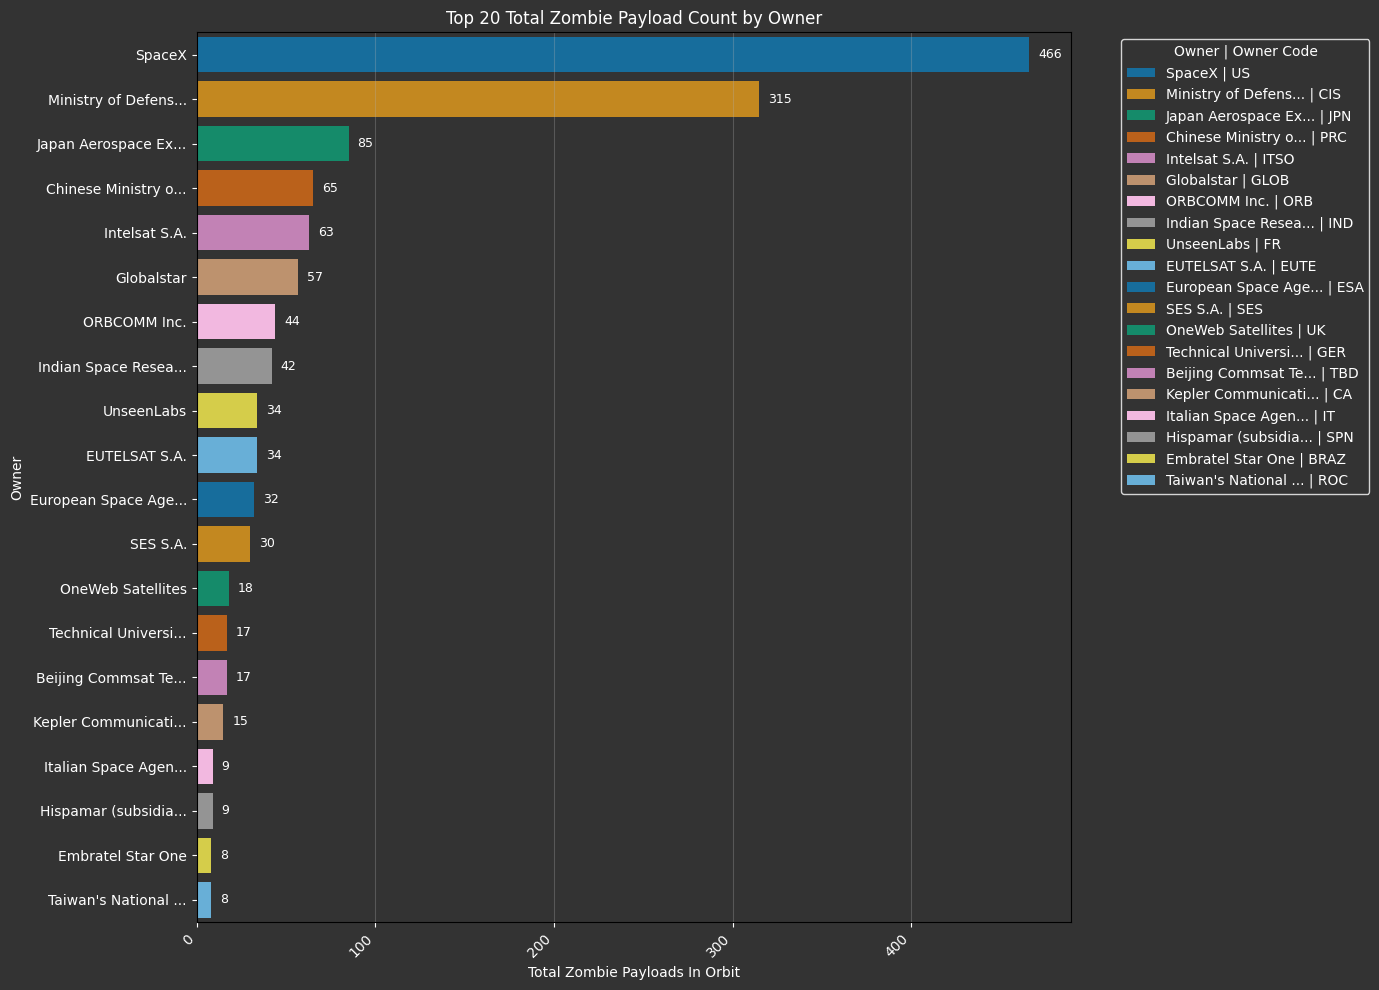

In [25]:
# Top 20 Zombie Payloads by Owner (mode owner_code per owner, consistent coloring)


df_owner_zombie_counts = df_owner_counts_all[df_owner_counts_all['ops_status'] == 'NON-OPERATIONAL']
df_owner_zombie_counts.to_parquet('../data/clean/results/owner_zombie_counts_exp.parquet', index=False)


# Get the most common owner_code for each owner
owner_code_mode = (
    df_owner_zombie_counts
    .groupby('owner')['owner_code']
    .agg(lambda x: x.dropna().mode().iloc[0] if not x.dropna().empty else None)
    .reset_index()
 )


owner_zombie_counts = (
    df_owner_zombie_counts
    .groupby(['owner'], dropna=False)
    .agg(zombie_payload_count=('norad_id', 'count'))
    .reset_index()
    .sort_values('zombie_payload_count', ascending=False)
    .head(20)
 )


owner_zombie_counts = owner_zombie_counts.merge(
    owner_code_mode,
    on='owner',
    how='left'

)


owner_zombie_counts['owner_short'] = owner_zombie_counts['owner'].apply(lambda x: x if len(str(x)) <= 18 else str(x)[:18] + '...')
owner_zombie_counts['owner_label'] = (
    owner_zombie_counts['owner_short'].astype(str) + ' | ' +
    owner_zombie_counts['owner_code'].astype(str)

)


plt.figure(figsize=(14, 10))


sns.barplot(
    data=owner_zombie_counts,
    y='owner_short',
    x='zombie_payload_count',
    hue='owner_label',
    palette='colorblind',
    dodge=False

)


for bar in plt.gca().patches:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    if width > 0:
        plt.gca().annotate(
            f'{int(width):,}',
            (width + 5, y),  # 5 is a small offset to the right
            ha='left',
            va='center',
            fontsize=9,
            color='white'
        )


plt.legend(title='Owner | Owner Code', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Top 20 Total Zombie Payload Count by Owner')
plt.xlabel('Total Zombie Payloads In Orbit')
plt.ylabel('Owner')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../charts/zombie_top_owner_code_contributors_exp.png', bbox_inches='tight', dpi=100)
plt.show()

## General EDA / Supporting Queries
 
Use a few supporting checks to add context for the main risk and congestion questions.
 
**Explore:**
- Mass Accumulation: Launched, Decayed, and Remaining Mass Over Time
- Mass Distribution: How mass is spread across orbit class and orbit type
- Country of Origin: Top countries by number of objects in orbit
- Satellite Age Distribution: Age spread, including very old and very new objects
- Largest Launch IDs by Attributed Deployed Objects
- Largest Debris Contribution Events

### Mass Accumulation: How much mass has accumulated in orbit over time?

Show the mass life cycle in orbit: how much mass was launched each year, how much re-entered each year, and how much mass remained in orbit over time.

**Method:**
- Sum the mass of objects launched each year.
- Sum the mass of objects that decayed each year.
- Track remaining mass over time by subtracting cumulative decayed mass from cumulative launched mass.
- Visualize the result with:
  - A bar chart for annual mass launched and annual mass decayed
  - A line for cumulative mass still in orbit

**How to Read This:**
- Blue bars show how much mass was launched each year; orange bars show how much mass decayed (re-entered the atmosphere).
- The green line shows the total mass still in orbit after accounting for decays.
- Rising green line indicates net mass accumulation; peaks may correlate with major launch campaigns.
- Gaps between blue and orange bars indicate years where launches outpaced decays, adding to the orbital debris burden.

In [26]:
mass_over_time_query = """
SELECT
    satellites.norad_id,
    satellites.decay_date,
    satellites.in_orbit,
    orbital_data.proxy_mass_kg,
    launch_events.launch_date
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
JOIN orbital_data ON satellites.norad_id = orbital_data.norad_id
WHERE launch_events.launch_date IS NOT NULL
ORDER BY launch_events.launch_date ASC;
"""

df_mass_over_time = pd.read_sql_query(mass_over_time_query, orbital_debris_conn)

df_mass_over_time['launch_year'] = pd.to_datetime(df_mass_over_time['launch_date'], errors='coerce').dt.year

df_mass_over_time.to_parquet('../data/clean/results/mass_over_time_exp.parquet', index=False)

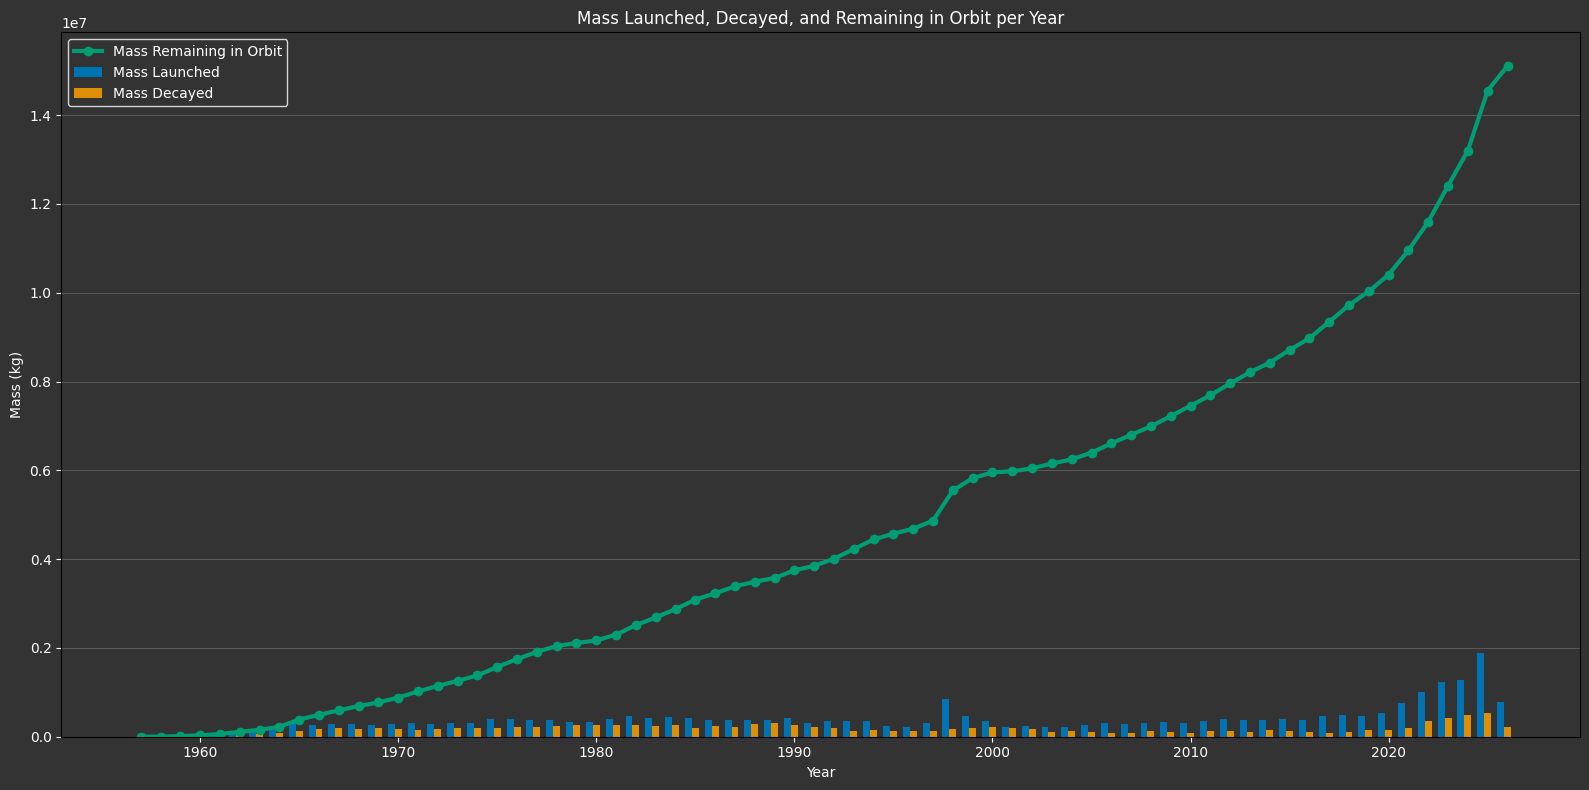

Total mass launched: 27,432,674 kg
Total mass decayed: 12,323,140 kg
Mass remaining in orbit (as of 2026): 15,109,534 kg


In [27]:
# Combined chart: mass launched, mass decayed, and mass remaining by year
if ('proxy_mass_kg' in df_mass_over_time.columns and 
    'in_orbit' in df_mass_over_time.columns and
    'decay_date' in df_mass_over_time.columns):
    
    # Mass launched per year
    mass_by_year = df_mass_over_time.groupby('launch_year')['proxy_mass_kg'].sum().sort_index()
    
    # Mass decayed per year
    df_decayed = df_mass_over_time[df_mass_over_time['in_orbit'] == 0].copy()
    df_decayed['decay_year'] = pd.to_datetime(df_decayed['decay_date'], errors='coerce').dt.year
    decayed_by_year = df_decayed.groupby('decay_year')['proxy_mass_kg'].sum().sort_index()

    # Use the full year range covered by either launches or decays.
    all_years = sorted(set(mass_by_year.index).union(decayed_by_year.index))
    mass_launched = mass_by_year.reindex(all_years, fill_value=0)
    mass_decayed = decayed_by_year.reindex(all_years, fill_value=0)

    # Running totals for remaining mass in orbit
    cumulative_launched = mass_launched.cumsum()
    cumulative_decayed = mass_decayed.cumsum()
    mass_remaining = cumulative_launched - cumulative_decayed

    plt.figure(figsize=(16,8))
    
    width = 0.35

    plt.bar([y - width for y in all_years], mass_launched.values, width=width, label='Mass Launched', color=COLOR_PALETTE[0])
    plt.bar([y for y in all_years], mass_decayed.values, width=width, label='Mass Decayed', color=COLOR_PALETTE[1])
    plt.plot(all_years, mass_remaining.values, label='Mass Remaining in Orbit', color=COLOR_PALETTE[2], linewidth=3, marker='o')

    plt.title('Mass Launched, Decayed, and Remaining in Orbit per Year')
    plt.xlabel('Year')
    plt.ylabel('Mass (kg)')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('../charts/mass_launched_decayed_remaining_exp.png', bbox_inches='tight', dpi=100)
    plt.show()

    print(f'Total mass launched: {mass_launched.sum():,.0f} kg')
    print(f'Total mass decayed: {mass_decayed.sum():,.0f} kg')
    print(f'Mass remaining in orbit (as of {max(all_years)}): {mass_remaining.iloc[-1]:,.0f} kg')
else:
    print('proxy_mass_kg, in_orbit, or decay_date column not found in mass over time data.')

### Mass by Orbit Class and Type: How mass is spread across orbit class and orbit type

Show how mass is distributed across different orbit classes (LEO, MEO, GEO) and orbit type.

**Method:**
- Query the database for mass, orbit class, and orbit type.
- Group and sum mass by orbit class and orbit type.

**Visuals:**
- A grouped bar chart showing mass distribution by orbit class and orbit type.
- A heatmap alternative showing the same data for comparison.

**How to Read This:**
- Higher bars and brighter heatmap cells mean more total mass in that category.
- This highlights where heavy object concentrations are located.
- Categories with high total mass can create higher potential collision impact.

In [28]:
mass_distribution_query = """
SELECT
    COALESCE(orbital_data.orbit_class, 'UNKNOWN') AS orbit_class,
    COALESCE(orbital_data.orbit_type, 'UNKNOWN') AS orbit_type,
    SUM(orbital_data.proxy_mass_kg) AS total_mass_kg,
    COUNT(*) AS object_count
FROM satellites
JOIN orbital_data ON satellites.norad_id = orbital_data.norad_id
WHERE orbital_data.proxy_mass_kg IS NOT NULL
GROUP BY orbit_class, orbit_type
ORDER BY total_mass_kg DESC;
"""

# Run the query and store the result
df_mass_distribution = pd.read_sql_query(mass_distribution_query, orbital_debris_conn)
df_mass_distribution['total_mass_kg'] = pd.to_numeric(df_mass_distribution['total_mass_kg'], errors='coerce')

# Save the query as a parquet file for future use.
df_mass_distribution.to_parquet('../data/clean/results/mass_distribution_exp.parquet', index=False)

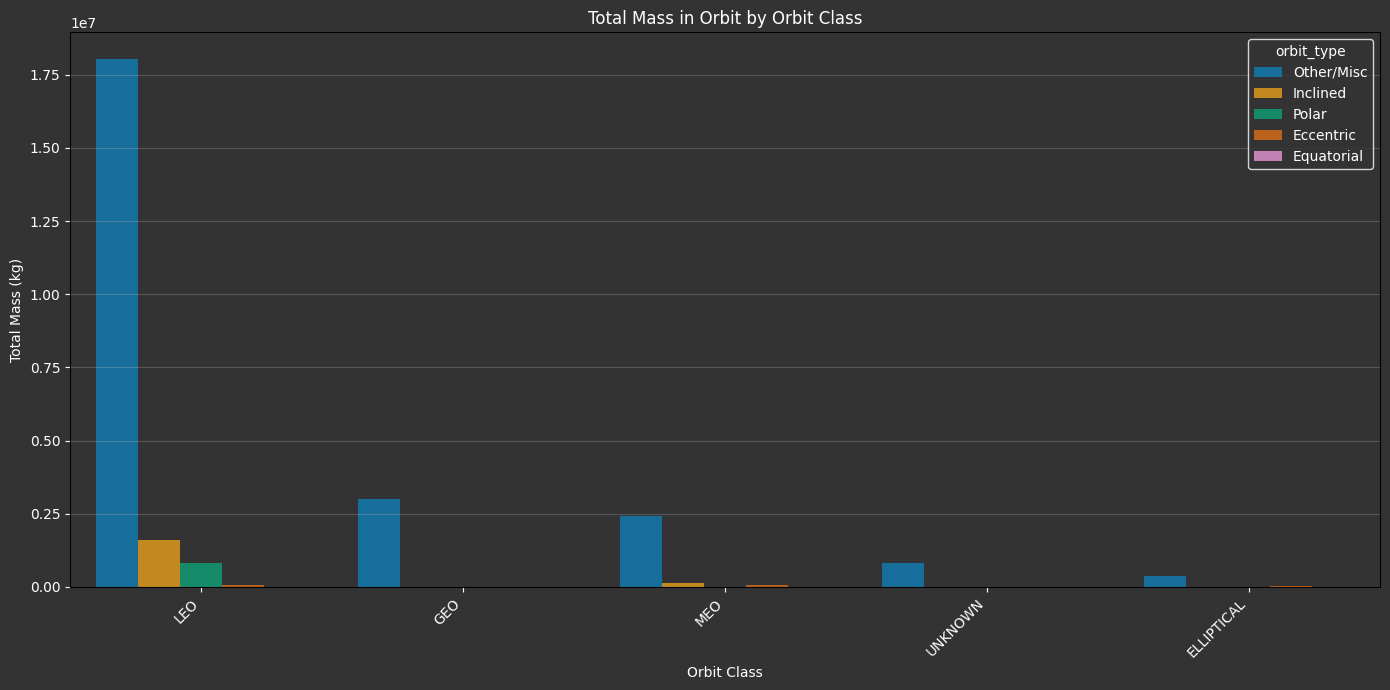

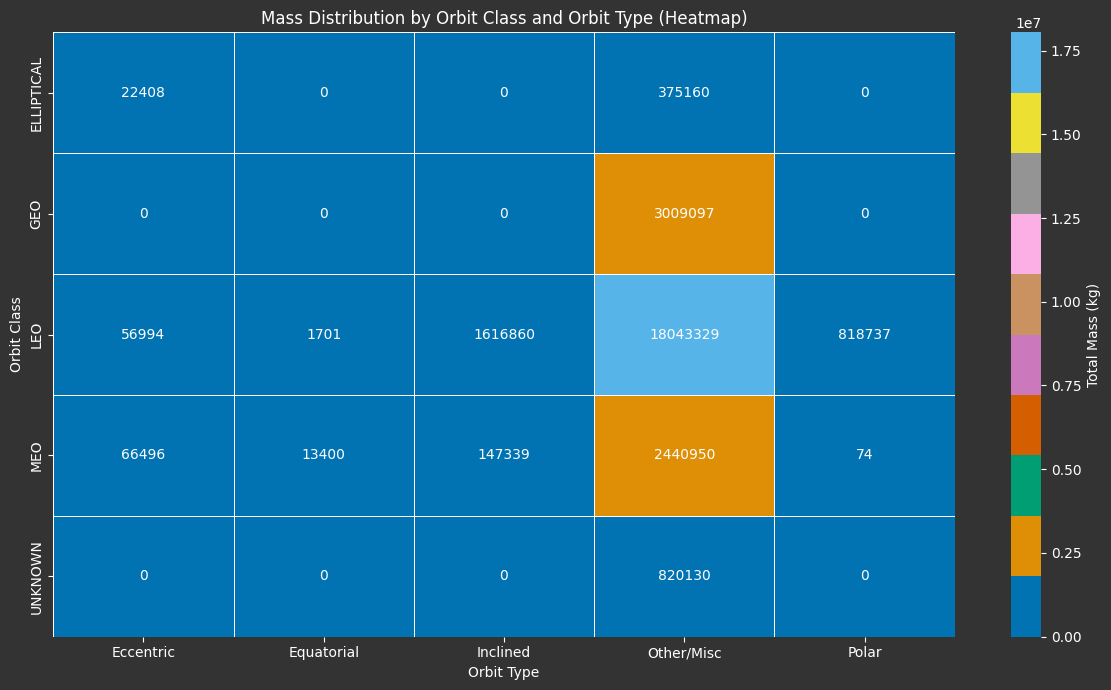

In [29]:
if not df_mass_distribution.empty:
  # Bar chart of total mass by orbit class, colored by orbit type
  plt.figure(figsize=(14, 7))

  sns.barplot(data=df_mass_distribution, x='orbit_class', y='total_mass_kg', hue='orbit_type', palette='colorblind')

  plt.title('Total Mass in Orbit by Orbit Class')
  plt.xlabel('Orbit Class')
  plt.ylabel('Total Mass (kg)')
  plt.xticks(rotation=45, ha='right')
  plt.grid(axis='y', alpha=0.3)

  plt.tight_layout()
  plt.savefig('../charts/mass_by_orbit_class_exp.png', bbox_inches='tight', dpi=100)
  plt.show()

  # Heatmap alternative view of mass distribution by orbit class and orbit type
  heatmap_df = df_mass_distribution.pivot_table(
      index='orbit_class',
      columns='orbit_type',
      values='total_mass_kg',
      aggfunc='sum',
      fill_value=0
  )

  plt.figure(figsize=(12, 7))
  sns.heatmap(
      heatmap_df,
      cmap=sns.color_palette("colorblind", as_cmap=True),
      annot=True,
      fmt='.0f',
      linewidths=0.4,
      cbar_kws={'label': 'Total Mass (kg)'}
  )

  plt.title('Mass Distribution by Orbit Class and Orbit Type (Heatmap)')
  plt.xlabel('Orbit Type')
  plt.ylabel('Orbit Class')

  plt.tight_layout()
  plt.savefig('../charts/mass_distribution_heatmap_exp.png', bbox_inches='tight', dpi=100)
  plt.show()
else:
  print('No mass distribution data available.')

### Country of Origin: Top countries by number of objects in orbit

Show which countries have the most objects of all types in orbit, based on the country-of-origin field. This helps identify which countries contribute most to orbital congestion and risk.

**Method:**
- Query country of origin and count distinct in-orbit objects per country.
- Keep the top countries and roll the remainder into `OTHER` for readability.

**Visuals:**
- A bar chart showing top countries by object count, with `OTHER` highlighted for emphasis.

**How to Read This:**
- Taller bars mean more tracked in-orbit objects tied to that country grouping.
- `OTHER` combines smaller groups so the main comparison stays readable.
- Use this as concentration context, not a full causal statement about responsibility.

In [30]:
top_countries_by_objects_query = """
SELECT
  COALESCE(ownership_operators.country_operator, 'UNKNOWN') AS country_of_origin,
  COUNT(DISTINCT satellites.norad_id) AS object_count
FROM satellites
LEFT JOIN ownership_operators ON satellites.owner_code = ownership_operators.owner_code
WHERE satellites.in_orbit = 1
GROUP BY country_of_origin
ORDER BY object_count DESC;
"""

# Run the query and store the result
df_top_countries = pd.read_sql_query(top_countries_by_objects_query, orbital_debris_conn)

# Save the query as a parquet file for future use.
df_top_countries.to_parquet('../data/clean/results/top_countries_by_objects.parquet', index=False)

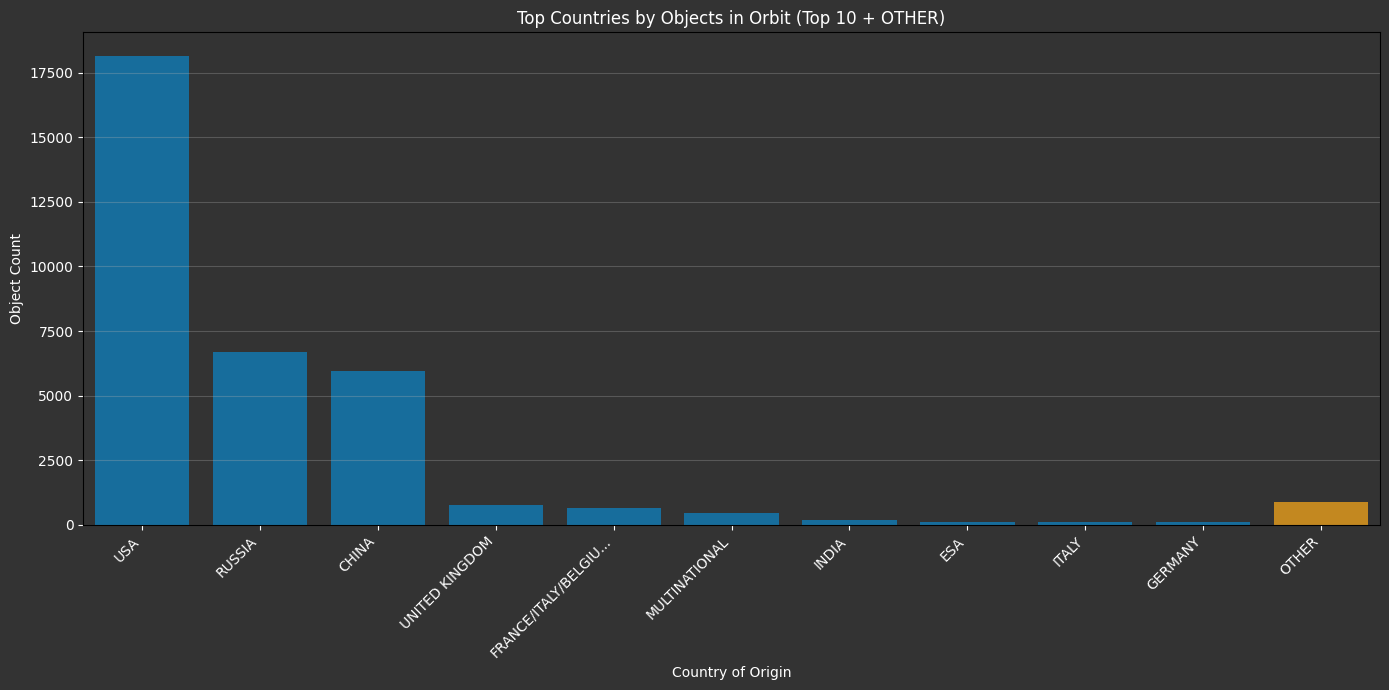

,country_label,country_of_origin,object_count
0,USA,USA,18155
1,RUSSIA,RUSSIA,6686
2,CHINA,CHINA,5940
3,UNITED KINGDOM,UNITED KINGDOM,776
4,FRANCE/ITALY/BELGIU...,FRANCE/ITALY/BELGIUM/SPAIN/GREECE,650
5,MULTINATIONAL,MULTINATIONAL,449
6,INDIA,INDIA,196
7,ESA,ESA,129
8,ITALY,ITALY,96
9,GERMANY,GERMANY,94


In [31]:
if df_top_countries.empty:
  print('No country-of-origin data available.')
else:
  # Keep top N countries and combine the remainder for readability.
  df_top_countries_top = df_top_countries.head(MAX_TOP).copy()
  other_count = df_top_countries.iloc[MAX_TOP:]['object_count'].sum()

  if other_count > 0:
    df_top_countries_top = pd.concat(
        [
            df_top_countries_top,
            pd.DataFrame([{'country_of_origin': 'OTHER', 'object_count': other_count}])
        ],
        ignore_index=True
    )

  # Save both full and rolled-up views.
  df_top_countries_top.to_parquet('../data/clean/results/top_countries_by_objects_with_others.parquet', index=False)

  # Create shorter display labels for crowded axis text while keeping source labels intact.
  max_label_length = 20
  df_top_countries_plot = df_top_countries_top.copy()
  df_top_countries_plot['country_label'] = df_top_countries_plot['country_of_origin'].apply(
      lambda text: text if len(text) <= max_label_length else f"{text[:max_label_length - 1]}..."
  )

  # Colorblind-safe emphasis: OTHER in orange, all others in blue.
  colors = [COLOR_PALETTE[0] if country != 'OTHER' else COLOR_PALETTE[1] for country in df_top_countries_plot['country_of_origin']]

  plt.figure(figsize=(14, 7))
  sns.barplot(
      data=df_top_countries_plot,
      x='country_label',
      y='object_count',
      palette=colors,
      hue='country_label',
      dodge=False,
      legend=False
  )

  plt.title(f'Top Countries by Objects in Orbit (Top {MAX_TOP} + OTHER)')
  plt.xlabel('Country of Origin')
  plt.ylabel('Object Count')
  plt.xticks(rotation=45, ha='right')
  plt.grid(axis='y', alpha=0.3)

  plt.tight_layout()
  plt.savefig('../charts/top_countries_by_objects_with_others.png', bbox_inches='tight', dpi=100)
  plt.show()

  display(df_top_countries_plot[['country_label', 'country_of_origin', 'object_count']])

### Satellite Age Distribution: How Old Are UCS-Matched Payloads in Orbit?

Show the age spread of UCS-matched in-orbit payloads, highlighting both very new and very old satellites.

**Method:**
- Pull satellite age (years since launch) for in-orbit objects with valid UCS age data.
- Plot the distribution and mark the youngest 5% and oldest 5% as outlier cutoffs.

**Visuals:**
- A histogram of satellite ages with vertical lines marking the young and old outlier cutoffs.

**How to Read This:**
- The shape of the histogram shows whether most objects are young, old, or spread evenly.
- Objects past the old outlier line have been in orbit far longer than typical and may pose higher collision risk.
- A tall peak near zero means a recent surge in new launches.

**Data limits:**
- This section is limited to objects with UCS age data (primarily payload records), not all in-orbit catalog objects.

In [32]:
sat_age_distribution_query = """
SELECT
    satellites.norad_id,
    satellites.object_type,
    COALESCE(orbital_data.orbit_class, 'UNKNOWN') AS orbit_class,
    ucs_details.sat_age_years
FROM satellites
LEFT JOIN orbital_data ON satellites.norad_id = orbital_data.norad_id
LEFT JOIN ucs_details ON satellites.norad_id = ucs_details.norad_id
WHERE satellites.in_orbit = 1
  AND ucs_details.sat_age_years IS NOT NULL
ORDER BY ucs_details.sat_age_years ASC;
"""

# Run the query and store the result
df_sat_age_distribution = pd.read_sql_query(sat_age_distribution_query, orbital_debris_conn)

df_sat_age_distribution['sat_age_years'] = pd.to_numeric(df_sat_age_distribution['sat_age_years'], errors='coerce')

df_sat_age_distribution = df_sat_age_distribution[
    df_sat_age_distribution['sat_age_years'].notna()
    & (df_sat_age_distribution['sat_age_years'] >= 0)
].copy()

# Save the query as a parquet file for future use.
df_sat_age_distribution.to_parquet('../data/clean/results/sat_age_distribution_exp.parquet', index=False)

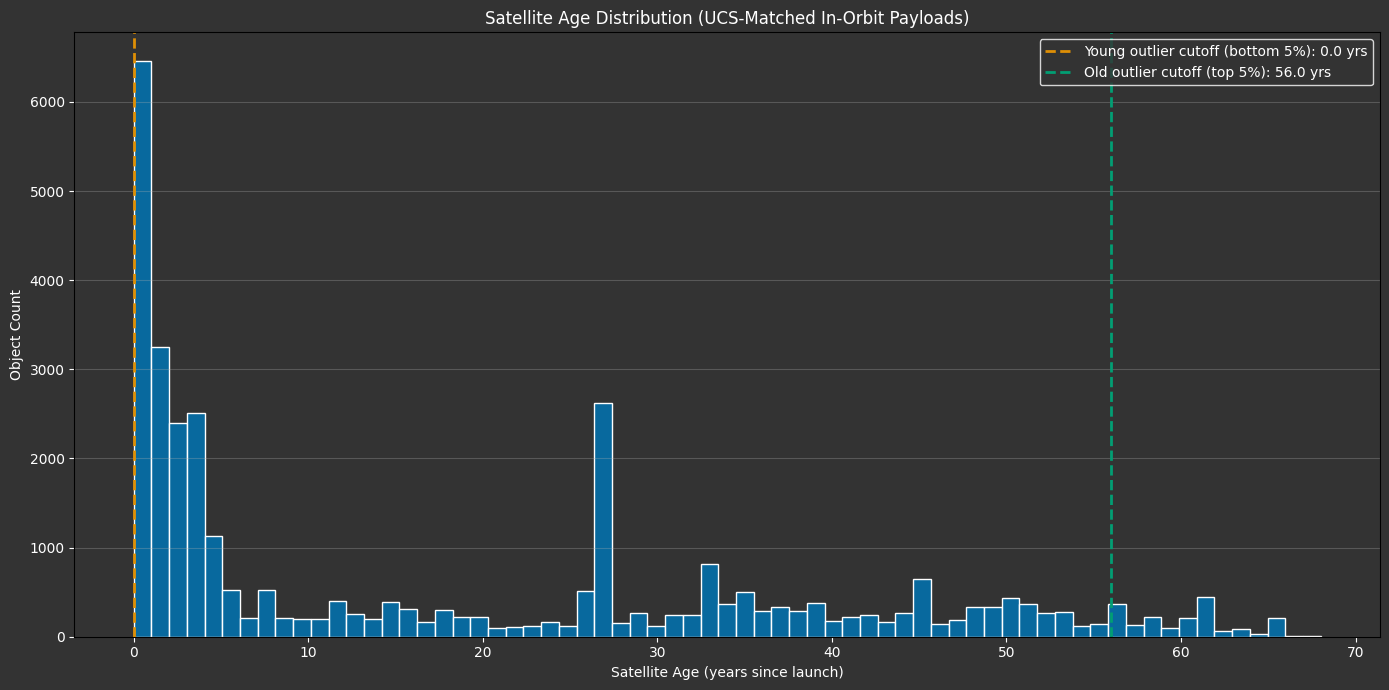

Total UCS-matched in-orbit payloads with valid age: 34,044
Young outliers (bottom 5%): 1,938, Youngest object age: 0.0 years
Old outliers (top 5%): 1,892, Oldest object age: 68.0 years


In [33]:
if df_sat_age_distribution.empty:
  print('No satellite age distribution data available.')
else:
  young_cutoff = float(df_sat_age_distribution['sat_age_years'].quantile(0.05))
  old_cutoff = float(df_sat_age_distribution['sat_age_years'].quantile(0.95))

  plt.figure(figsize=(14, 7))
  sns.histplot(
      data=df_sat_age_distribution,
      bins=67,
      x='sat_age_years',
      color=COLOR_PALETTE[0],
      edgecolor='white',
      alpha=0.85
  )

  plt.axvline(young_cutoff, color=COLOR_PALETTE[1], linestyle='--', linewidth=2, label=f'Young outlier cutoff (bottom 5%): {young_cutoff:.1f} yrs')
  plt.axvline(old_cutoff, color=COLOR_PALETTE[2], linestyle='--', linewidth=2, label=f'Old outlier cutoff (top 5%): {old_cutoff:.1f} yrs')

  plt.title('Satellite Age Distribution (UCS-Matched In-Orbit Payloads)')
  plt.xlabel('Satellite Age (years since launch)')
  plt.ylabel('Object Count')
  plt.grid(axis='y', alpha=0.3)
  plt.legend(loc='upper right', frameon=True)

  plt.tight_layout()
  plt.savefig('../charts/sat_age_distribution_hist_exp.png', bbox_inches='tight', dpi=100)
  plt.show()

  young_outliers = df_sat_age_distribution[df_sat_age_distribution['sat_age_years'] <= young_cutoff]
  old_outliers = df_sat_age_distribution[df_sat_age_distribution['sat_age_years'] >= old_cutoff]

  print(f'Total UCS-matched in-orbit payloads with valid age: {len(df_sat_age_distribution):,}')
  print(f'Young outliers (bottom 5%): {len(young_outliers):,}, Youngest object age: {df_sat_age_distribution["sat_age_years"].min():.1f} years')
  print(f'Old outliers (top 5%): {len(old_outliers):,}, Oldest object age: {df_sat_age_distribution["sat_age_years"].max():.1f} years')

### Largest Launch IDs by Attributed Deployed Objects

This section ranks launch IDs by how many deployed objects are linked to each one in this database.

**Method:**
- Group objects by `launch_id`.
- Keep only `PAYLOAD` and `ROCKET BODY`.
- Count deployed objects for each launch ID.
- Rank launch IDs from highest to lowest.

**Visuals:**
- A horizontal bar chart of the top launch IDs by deployed object count.
- A table with launch date, launch site, and the payload/rocket-body mix.

**How to Read This:**
- In this dataset, `launch_id` works like a parent label.
- Some IDs (like ISS parent IDs) can include objects released over many years.
- Those objects may still point to the original launch date.
- So this is best read as where objects are attributed in the catalog, not always what happened in one single launch-day event.

In [34]:
largest_launch_events_query = """
SELECT
    launch_events.launch_id,
    launch_events.launch_date,
    launch_events.launch_year,
    COALESCE(launch_events.launch_site, 'UNKNOWN') AS launch_site,
    COUNT(*) AS deployed_object_count,
    SUM(CASE WHEN satellites.object_type = 'PAYLOAD' THEN 1 ELSE 0 END) AS payload_count,
    SUM(CASE WHEN satellites.object_type = 'ROCKET BODY' THEN 1 ELSE 0 END) AS rocket_body_count
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE satellites.launch_id IS NOT NULL
  AND satellites.object_type IN ('PAYLOAD', 'ROCKET BODY')
GROUP BY
    launch_events.launch_id,
    launch_events.launch_date,
    launch_events.launch_year,
    launch_events.launch_site
ORDER BY deployed_object_count DESC, launch_events.launch_date ASC;
"""

# Run the query and store the result
df_largest_launch_events = pd.read_sql_query(largest_launch_events_query, orbital_debris_conn)

# Save query result for later story-building and validation.
df_largest_launch_events.to_parquet('../data/clean/results/largest_single_launch_events_exp.parquet', index=False)

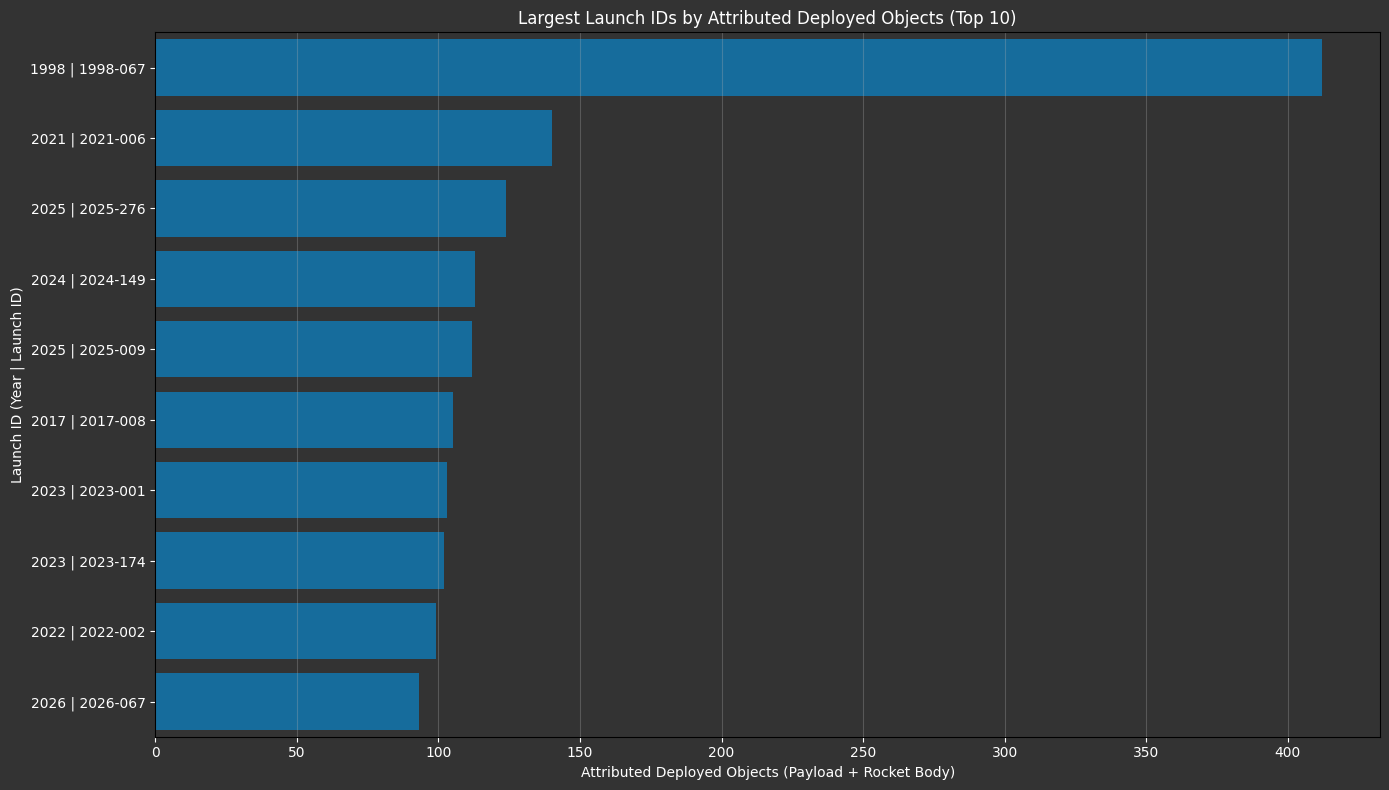

,launch_id,launch_date,launch_site,deployed_object_count,payload_count,rocket_body_count
0,1998-067,1998-11-20,Baikonur Cosmodrome,412,411,1
1,2021-006,2021-01-24,AFETR,140,140,0
2,2025-276,2025-11-28,AFWTR,124,124,0
3,2024-149,2024-08-16,AFWTR,113,113,0
4,2025-009,2025-01-14,AFWTR,112,112,0
5,2017-008,2017-02-15,Satish Dhawan Space Centre,105,104,1
6,2023-001,2023-01-03,Cape Canaveral,103,103,0
7,2023-174,2023-11-11,AFWTR,102,102,0
8,2022-002,2022-01-13,AFETR,99,99,0
9,2026-067,2026-03-30,AFWTR,93,93,0


In [35]:
if df_largest_launch_events.empty:
  print('No launch-event deployment data available.')
else:
  df_top_launch_events = df_largest_launch_events.head(MAX_TOP).copy()

  # Build concise labels for plotting.
  df_top_launch_events['launch_label'] = df_top_launch_events.apply(
      lambda row: f"{int(row['launch_year']) if pd.notna(row['launch_year']) else 'UNK'} | {row['launch_id']}",
      axis=1
  )

  plt.figure(figsize=(14, 8))
  sns.barplot(
      data=df_top_launch_events,
      y='launch_label',
      x='deployed_object_count',
      color='#0072B2'
  )

  plt.title(f'Largest Launch IDs by Attributed Deployed Objects (Top {MAX_TOP})')
  plt.xlabel('Attributed Deployed Objects (Payload + Rocket Body)')
  plt.ylabel('Launch ID (Year | Launch ID)')
  plt.grid(axis='x', alpha=0.3)

  plt.tight_layout()
  plt.savefig('../charts/largest_single_launch_events_exp.png', bbox_inches='tight', dpi=100)
  plt.show()

  display(
      df_top_launch_events[
          [
              'launch_id', 'launch_date', 'launch_site', 'deployed_object_count',
              'payload_count', 'rocket_body_count'
          ]
      ]
  )

### Largest Debris Contribution Events

Find which launch IDs are linked to the most debris objects in this catalog.

**Method:**
- Group debris objects by `launch_id`.
- Count debris objects per launch ID.
- Rank launch IDs by debris count.

**Visuals:**
- A horizontal bar chart of the top launch IDs by debris count.
- A table with launch date, launch site, and debris count.

**How to Read This:**
- This section shows where debris is attributed in the catalog.
- Some parent IDs can collect debris over time, not only on one launch day.

In [36]:
largest_debris_events_query = """
SELECT
    launch_events.launch_id,
    launch_events.launch_date,
    launch_events.launch_year,
    COALESCE(launch_events.launch_site, 'UNKNOWN') AS launch_site,
    COUNT(*) AS debris_object_count
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE satellites.launch_id IS NOT NULL
  AND satellites.object_type = 'DEBRIS'
GROUP BY
    launch_events.launch_id,
    launch_events.launch_date,
    launch_events.launch_year,
    launch_events.launch_site
ORDER BY debris_object_count DESC, launch_events.launch_date ASC;
"""

# Run the query and store the result
df_largest_debris_events = pd.read_sql_query(largest_debris_events_query, orbital_debris_conn)

# Save query result for later story-building and validation.
df_largest_debris_events.to_parquet('../data/clean/results/largest_debris_contribution_events_exp.parquet', index=False)

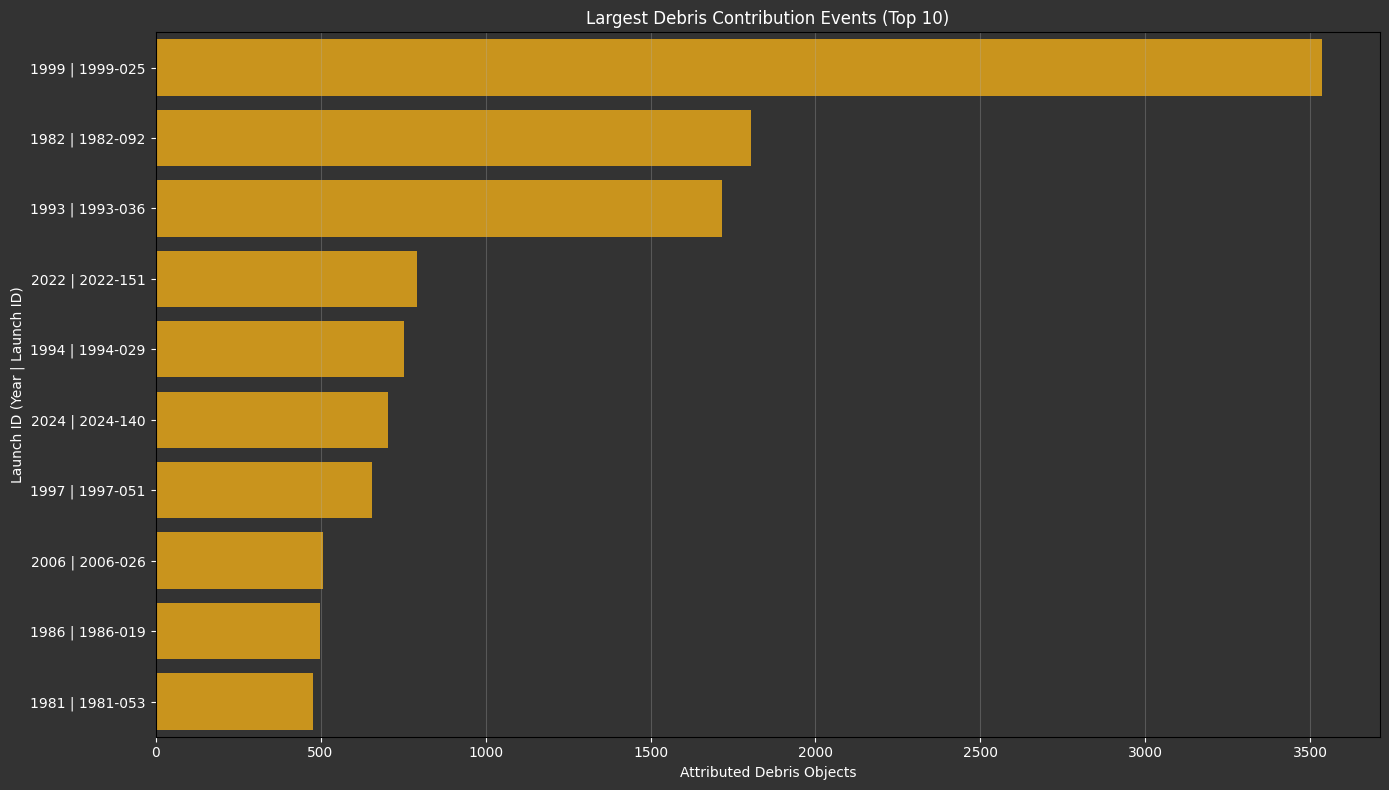

,launch_id,launch_date,launch_site,debris_object_count
0,1999-025,1999-05-10,TAISC,3534
1,1982-092,1982-09-16,PLMSC,1806
2,1993-036,1993-06-16,PLMSC,1716
3,2022-151,2022-11-11,TAISC,793
4,1994-029,1994-05-19,AFWTR,753
5,2024-140,2024-08-06,TAISC,705
6,1997-051,1997-09-14,TYMSC,656
7,2006-026,2006-06-25,TYMSC,508
8,1986-019,1986-02-22,FRGUI,498
9,1981-053,1981-06-04,PLMSC,478


In [37]:
if df_largest_debris_events.empty:
  print('No debris contribution data available.')
else:
  df_top_debris_events = df_largest_debris_events.head(MAX_TOP).copy()

  # Build concise labels for plotting.
  df_top_debris_events['launch_label'] = df_top_debris_events.apply(
      lambda row: f"{int(row['launch_year']) if pd.notna(row['launch_year']) else 'UNK'} | {row['launch_id']}",
      axis=1
  )

  plt.figure(figsize=(14, 8))
  sns.barplot(
      data=df_top_debris_events,
      y='launch_label',
      x='debris_object_count',
      color='#E69F00'
  )

  plt.title(f'Largest Debris Contribution Events (Top {MAX_TOP})')
  plt.xlabel('Attributed Debris Objects')
  plt.ylabel('Launch ID (Year | Launch ID)')
  plt.grid(axis='x', alpha=0.3)

  plt.tight_layout()
  plt.savefig('../charts/largest_debris_contribution_events_exp.png', bbox_inches='tight', dpi=100)
  plt.show()

  display(
      df_top_debris_events[
          [
              'launch_id', 'launch_date', 'launch_site', 'debris_object_count'
          ]
      ]
  )

## Launch Years and Congestion

Show how each launch year contributes to the overall object count in orbit, and compare deployment patterns before and after the detected decoupling year from section 1.

**Explore:**
- Launch Year Analysis: Total objects launched per year by type, and how many remain in orbit per year
- Post-Split Deployment Patterns: Compare object type mix and counts before vs. after the detected split year

In [38]:
launch_cohort_query = """
SELECT
    launch_events.launch_year,
    satellites.object_type,
    COUNT(*) AS total_launched,
    SUM(satellites.in_orbit) AS in_orbit_count
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE launch_events.launch_year IS NOT NULL
GROUP BY
    launch_events.launch_year,
    satellites.object_type
ORDER BY launch_events.launch_year ASC;
"""

df_cohort = pd.read_sql_query(launch_cohort_query, orbital_debris_conn)
df_cohort.to_parquet('../data/clean/results/launch_cohort_analysis_exp.parquet', index=False)

### Launch Year Analysis

Group all cataloged objects by launch year and show how each year's launches contribute to the overall population, broken down by object type.

**Method:**
- Query all objects joined to their launch year.
- Group by launch year and object type, counting total objects and those still in orbit.

**Visuals:**
- A stacked bar chart showing objects launched per year by type (PAYLOAD, ROCKET BODY, DEBRIS).
- A dashed line overlay showing how many objects from each year remain in orbit today.

**How to Read This:**
- Each bar represents one launch year's total contribution to the catalog.
- A dominant DEBRIS stack in a year often reflects a fragmentation or breakup event rather than planned launches.
- The dashed line shows persistence: years with a high line relative to bar height have more objects still in orbit today.

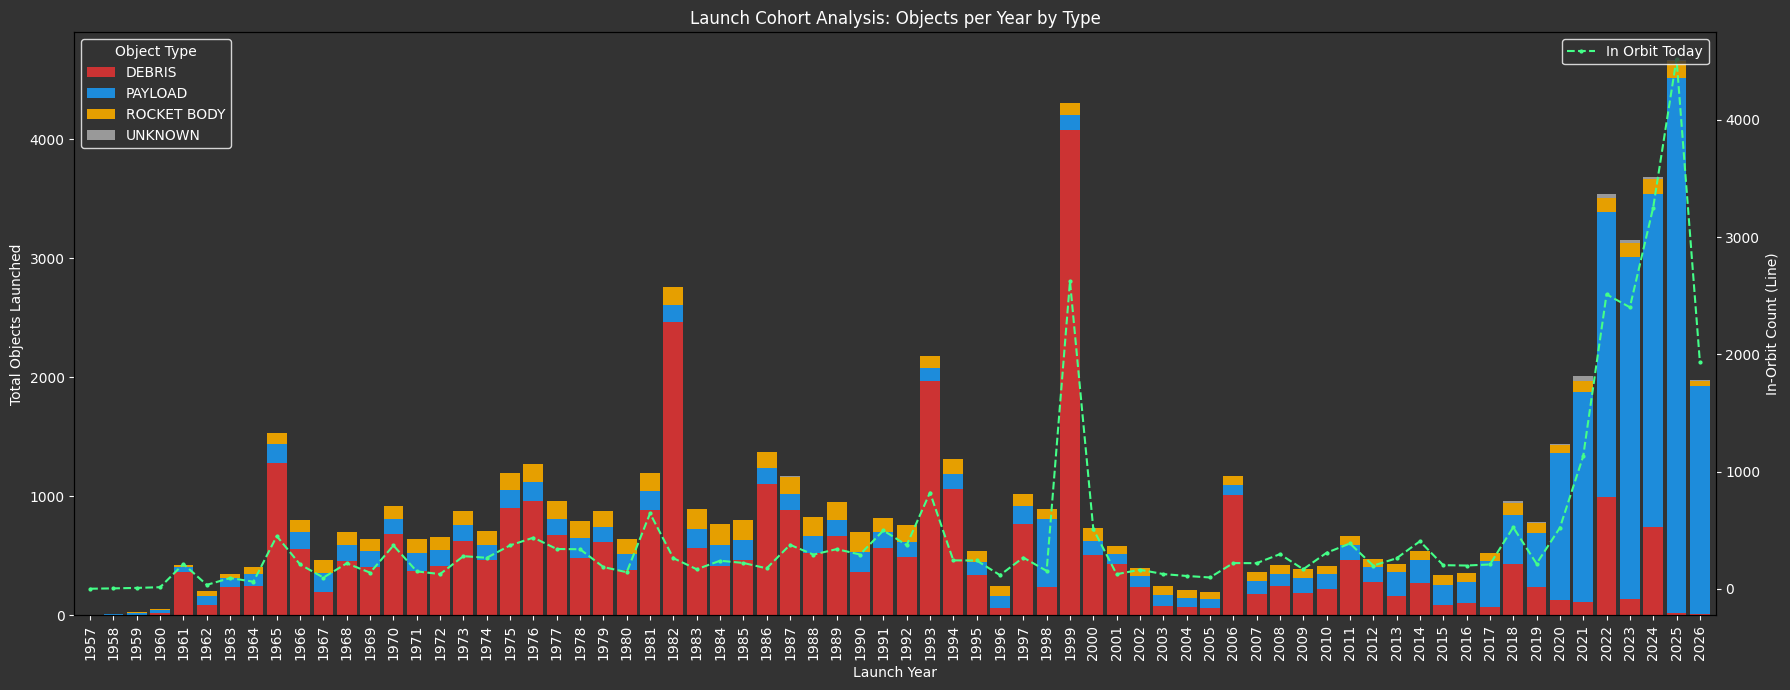

Total cohort years: 70
Total objects in dataset: 69,239


In [39]:
if df_cohort.empty:
    print('No cohort data available.')
else:
    cohort_pivot = df_cohort.pivot_table(
        index='launch_year',
        columns='object_type',
        values='total_launched',
        aggfunc='sum',
        fill_value=0
    )

    cohort_in_orbit = df_cohort.groupby('launch_year')['in_orbit_count'].sum()

    type_colors = {
        'PAYLOAD': '#1d8cdb',
        'ROCKET BODY': '#E69F00',
        'DEBRIS': '#cc3333'
    }
    
    colors = [type_colors.get(c, '#999999') for c in cohort_pivot.columns]

    fig, ax1 = plt.subplots(figsize=(18, 7))

    cohort_pivot.plot(kind='bar', stacked=True, ax=ax1, color=colors, width=0.85)

    ax2 = ax1.twinx()
    ax2.plot(
        range(len(cohort_in_orbit)),
        cohort_in_orbit.values,
        color='#44ff88', linewidth=1.5, linestyle='--', marker='o', markersize=2,
        label='In Orbit Today'
    )
    ax2.set_ylabel('In-Orbit Count (Line)')

    ax1.set_title('Launch Cohort Analysis: Objects per Year by Type')
    ax1.set_xlabel('Launch Year')
    ax1.set_ylabel('Total Objects Launched')
    ax1.tick_params(axis='x', rotation=90)
    ax1.legend(loc='upper left', title='Object Type')
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.savefig('../charts/launch_cohort_analysis_exp.png', bbox_inches='tight', dpi=100)
    plt.show()

    print(f'Total cohort years: {len(cohort_pivot)}')
    print(f'Total objects in dataset: {cohort_pivot.values.sum():,.0f}')

### Post-Split Deployment Patterns

Compare object type mix and launch volume before and after the detected split year to show how deployment patterns changed when growth accelerated.

**Method:**
- Classify each object as pre-split or post-split based on launch year and the detected split year from section 1.
- Count total objects and in-orbit objects for each era, grouped by object type.

**Visuals:**
- Grouped bar chart comparing PAYLOAD, ROCKET BODY, and DEBRIS counts across the two eras.
- 100% stacked bar chart showing the object type share within each era.

**How to Read This:**
- Taller bars in the post-split era confirm the volume acceleration.
- A growing DEBRIS share post-split indicates more fragmentation or debris-generating events relative to planned missions.
- Compare PAYLOAD share across eras: a shrinking share means payloads are a declining fraction of total activity even as their absolute count grows.

In [40]:
deployment_patterns_query = f"""
SELECT
  CASE
    WHEN launch_events.launch_year >= {split_year} THEN 'Post-Split' ELSE 'Pre-Split'
  END AS era,
  satellites.object_type,
  COUNT(*) AS total_launched,
  SUM(satellites.in_orbit) AS in_orbit_count
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE launch_events.launch_year IS NOT NULL
GROUP BY era, satellites.object_type
ORDER BY era ASC, satellites.object_type ASC;
"""

df_deployment_patterns = pd.read_sql_query(deployment_patterns_query, orbital_debris_conn)
df_deployment_patterns.to_parquet('../data/clean/results/deployment_patterns_exp.parquet', index=False)

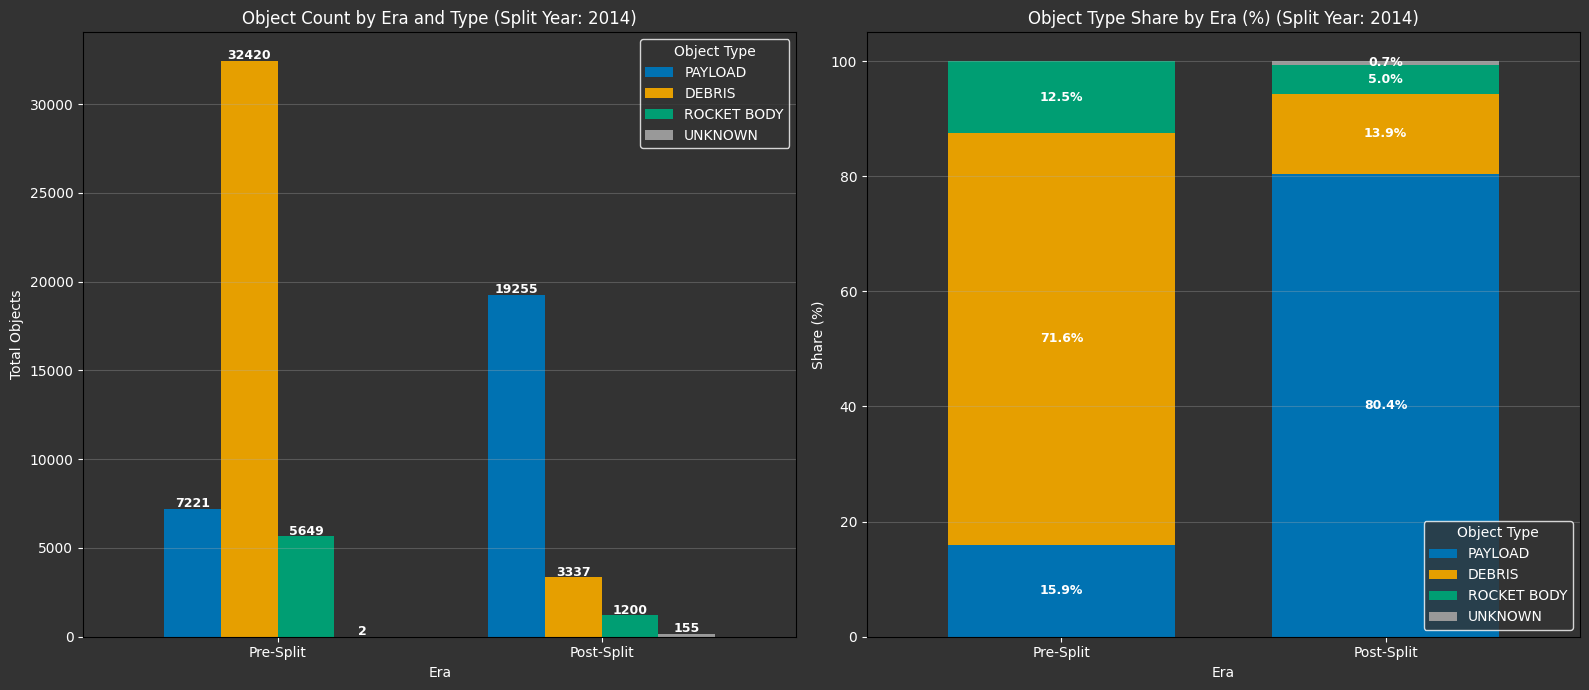

In [41]:
if df_deployment_patterns.empty:
  print('No era comparison data available.')
else:
  
  # Redefining colors and order here to ensure consistency across both charts and consistent
  # color mapping across the notebook as a whole.
  object_type_colors = {
    'PAYLOAD': '#0072B2',      # blue
    'DEBRIS': '#E69F00',       # orange
    'ROCKET BODY': '#009E73',  # green
    'UNKNOWN': '#999999'       # gray
  }
  
  object_type_order = ['PAYLOAD', 'DEBRIS', 'ROCKET BODY', 'UNKNOWN']

  era_order = ['Pre-Split', 'Post-Split']

  era_pivot = df_deployment_patterns.pivot_table(
      index='era',
      columns='object_type',
      values='total_launched',
      aggfunc='sum',
      fill_value=0
  )

  # Reindex both rows and columns
  era_pivot = era_pivot.reindex(index=era_order, columns=object_type_order, fill_value=0)

  era_pct = (era_pivot.div(era_pivot.sum(axis=1), axis=0) * 100).round(2)
  
  # maps object types to colors, defaulting to gray if an unexpected type is encountered
  colors = [object_type_colors.get(col, '#999999') for col in era_pivot.columns]

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

  era_pivot.plot(kind='bar', ax=ax1, color=colors, width=0.7)
  
  # annotate object count labels on top of each bar segment for the absolute count chart
  for p in ax1.patches:
      height = p.get_height()
      if height > 0:
          # get the middle width and full height plus a buffer for the bar segment to position the count label on TOP of its bar segment.
          ax1.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, p.get_y() + height + 300),
                        ha='center', va='center', fontsize=9, color='white', fontweight='bold')
  
  ax1.set_title(f'Object Count by Era and Type (Split Year: {split_year})')
  ax1.set_xlabel('Era')
  ax1.set_ylabel('Total Objects')
  ax1.tick_params(axis='x', rotation=0)
  ax1.legend(title='Object Type')
  ax1.grid(axis='y', alpha=0.3)

  era_pct.plot(kind='bar', stacked=True, ax=ax2, color=colors, width=0.7)
    
  # annotate percentage labels on top of each bar segment for the percentage share chart
  for bar in ax2.patches:
      height = bar.get_height()
      
      if height > 0:
          # get the middle width and middle height of the bar segment to position the percent label
          ax2.annotate(f'{height:.1f}%', (bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        ha='center', va='center', fontsize=9, color='white', fontweight='bold')
  
  ax2.set_title(f'Object Type Share by Era (%) (Split Year: {split_year})')
  ax2.set_xlabel('Era')
  ax2.set_ylabel('Share (%)')
  ax2.tick_params(axis='x', rotation=0)
  ax2.legend(title='Object Type')
  ax2.grid(axis='y', alpha=0.3)

  plt.tight_layout()
  plt.savefig('../charts/deployment_patterns_exp.png', bbox_inches='tight', dpi=100)
  plt.show()

## Object Type, Status, and Kinetic Risk

Look at how object types are changing over time, then compare risk by type and operational status.

**Explore:**
- Object Type Distribution: Counts and trends for PAYLOAD, ROCKET BODY, DEBRIS
- Kinetic Risk by Type/Status: Cross-tab kinetic energy and velocity by object type and operational status

### Object Type Distribution: Counts and Trends

Show how PAYLOAD, ROCKET BODY, and DEBRIS change over time, and compare their total counts across the full dataset.

**Method:**
- Pull launch year and object type for all objects.
- Count objects by launch year and object type.
- Build a simple year-by-type table for trend and total views.

**Visuals:**
- Line chart: yearly trend for PAYLOAD, ROCKET BODY, and DEBRIS.
- Bar chart: total count by object type.

**How to Read This:**
- Rising lines mean that type is growing faster over time.
- Line crossovers show when one type starts to outpace another.
- The bar chart shows long-run totals, not just recent years.

In [42]:
object_type_trends_query = """
SELECT
    launch_events.launch_year,
    COALESCE(satellites.object_type, 'UNKNOWN') AS object_type,
    COUNT(*) AS object_count
FROM satellites
JOIN launch_events ON satellites.launch_id = launch_events.launch_id
WHERE launch_events.launch_year IS NOT NULL
GROUP BY
    launch_events.launch_year,
    COALESCE(satellites.object_type, 'UNKNOWN')
ORDER BY launch_events.launch_year ASC, object_type ASC;
"""

df_object_type_trends = pd.read_sql_query(object_type_trends_query, orbital_debris_conn)
df_object_type_trends.to_parquet('../data/clean/results/object_type_distribution_section5_exp.parquet', index=False)

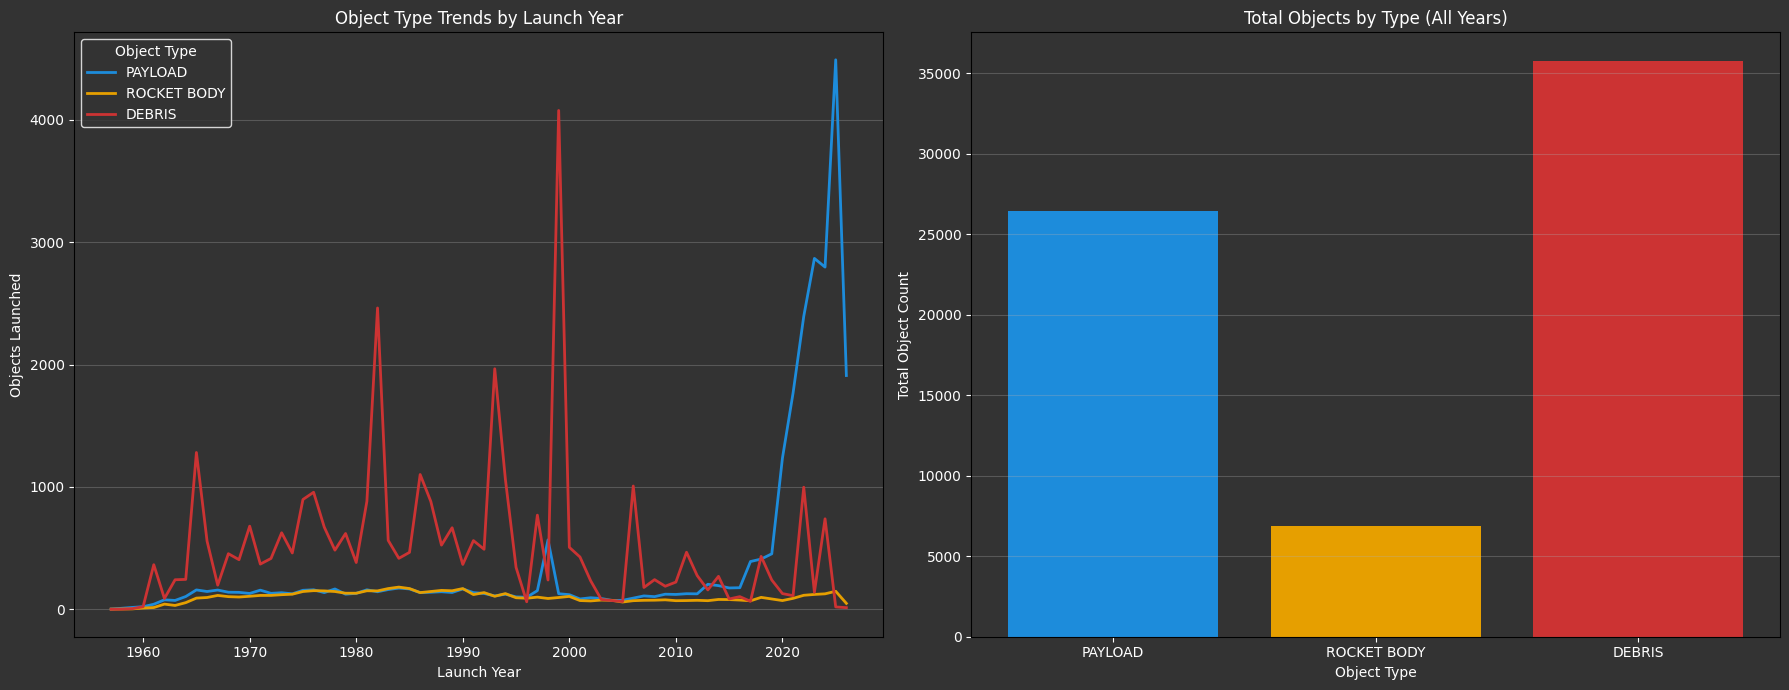

Total objects by type:
object_type
PAYLOAD        26476
ROCKET BODY     6849
DEBRIS         35757

Excluded UNKNOWN object_type rows: 157 (0.23% of all rows)


In [43]:
if df_object_type_trends.empty:
    print('No object type trend data available.')
else:
    type_order = ['PAYLOAD', 'ROCKET BODY', 'DEBRIS']
    type_colors = {
        'PAYLOAD': '#1d8cdb',
        'ROCKET BODY': '#E69F00',
        'DEBRIS': '#cc3333'
    }

    total_objects_all = int(df_object_type_trends['object_count'].sum())

    df_known = df_object_type_trends[
        df_object_type_trends['object_type'].isin(type_order)
    ].copy()

    known_total = int(df_known['object_count'].sum())
    unknown_count = total_objects_all - known_total
    unknown_share = (unknown_count / total_objects_all) if total_objects_all else 0.0

    if df_known.empty:
        print('No PAYLOAD/ROCKET BODY/DEBRIS rows available for plotting.')
    else:
        type_trend_pivot = df_known.pivot_table(
            index='launch_year',
            columns='object_type',
            values='object_count',
            aggfunc='sum',
            fill_value=0
        )
        type_trend_pivot = type_trend_pivot.reindex(columns=type_order, fill_value=0)

        overall_counts = type_trend_pivot.sum(axis=0).reindex(type_order, fill_value=0)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

        for object_type in type_order:
            ax1.plot(
                type_trend_pivot.index,
                type_trend_pivot[object_type],
                label=object_type,
                color=type_colors[object_type],
                linewidth=2
            )

        ax1.set_title('Object Type Trends by Launch Year')
        ax1.set_xlabel('Launch Year')
        ax1.set_ylabel('Objects Launched')
        ax1.grid(axis='y', alpha=0.3)
        ax1.legend(title='Object Type')

        ax2.bar(
            overall_counts.index,
            overall_counts.values,
            color=[type_colors[object_type] for object_type in overall_counts.index]
        )
        
        ax2.set_title('Total Objects by Type (All Years)')
        ax2.set_xlabel('Object Type')
        ax2.set_ylabel('Total Object Count')
        ax2.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.savefig('../charts/object_type_distribution_trends_exp.png', bbox_inches='tight', dpi=100)
        plt.show()

        print('Total objects by type:')
        print(overall_counts.to_string())

    print()
    print(f"Excluded UNKNOWN object_type rows: {unknown_count:,} ({unknown_share:.2%} of all rows)")

### Kinetic Risk by Type and Status

This section compares kinetic risk without forcing different object classes into the same status logic.

**Why this split matters:**
- `PAYLOAD` objects have mission/operational status fields (`ops_status`).
- `ROCKET BODY` and `DEBRIS` are better described by lifecycle state (`in_orbit`, `decay_date`).
- Using separate status systems keeps the comparison fair and easier to interpret.

**Method:**
- For `PAYLOAD`, group by operational-status buckets from `ops_status`.
- For `ROCKET BODY` and `DEBRIS`, group by lifecycle buckets from `in_orbit` and `decay_date`.
- Compute average kinetic energy for each bucket.

**Visuals:**
- Payload chart: average kinetic energy by payload operational-status.
- Non-payload chart: average kinetic energy by lifecycle for rocket bodies and debris.

**How to Read This:**
- Payload statuses describe mission state.
- Non-payload statuses describe whether objects are still in orbit or have decayed.
- Read the two charts separately, because each one uses status labels that match that object type.

In [44]:
kinetic_risk_by_type_status_query = """
SELECT
    satellites.norad_id,
    COALESCE(satellites.object_type, 'UNKNOWN') AS object_type,
    COALESCE(satellites.ops_status, 'UNKNOWN') AS ops_status,
    satellites.in_orbit,
    satellites.decay_date,
    risk_assessment.kinetic_joules,
    risk_assessment.velocity_kms
FROM satellites
LEFT JOIN risk_assessment ON satellites.norad_id = risk_assessment.norad_id
ORDER BY object_type ASC, ops_status ASC;
"""

df_kinetic_by_type_status = pd.read_sql_query(kinetic_risk_by_type_status_query, orbital_debris_conn)
df_kinetic_by_type_status.to_parquet('../data/clean/results/kinetic_risk_by_type_status_section5_exp.parquet', index=False)

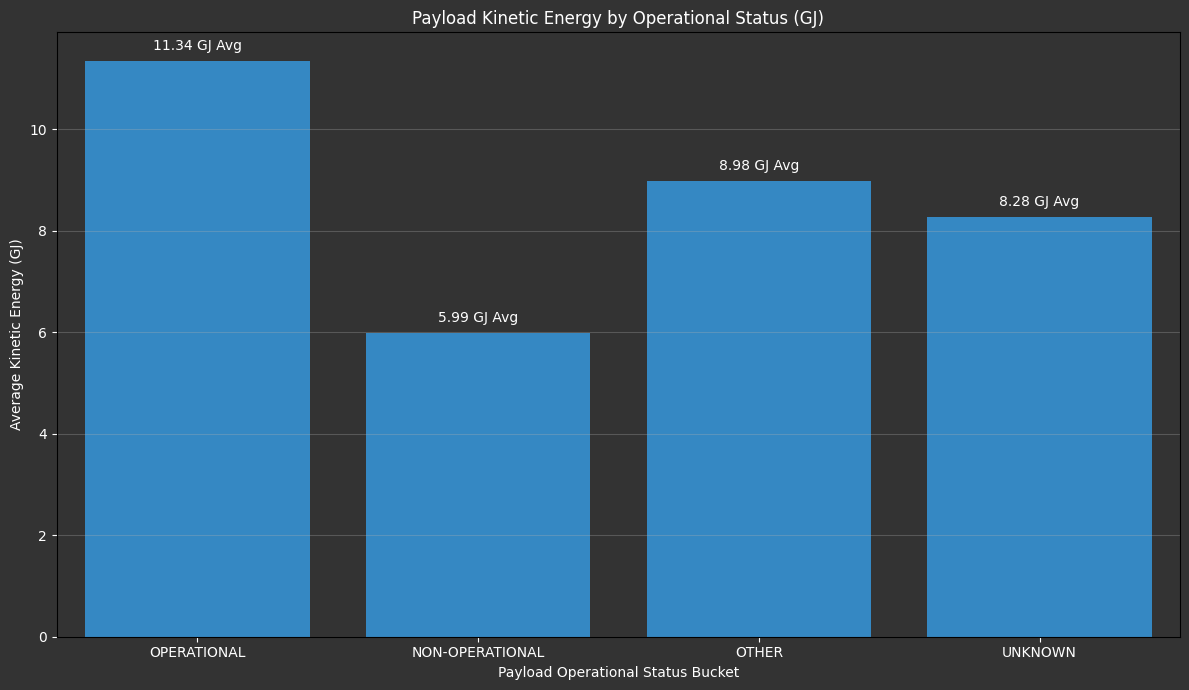

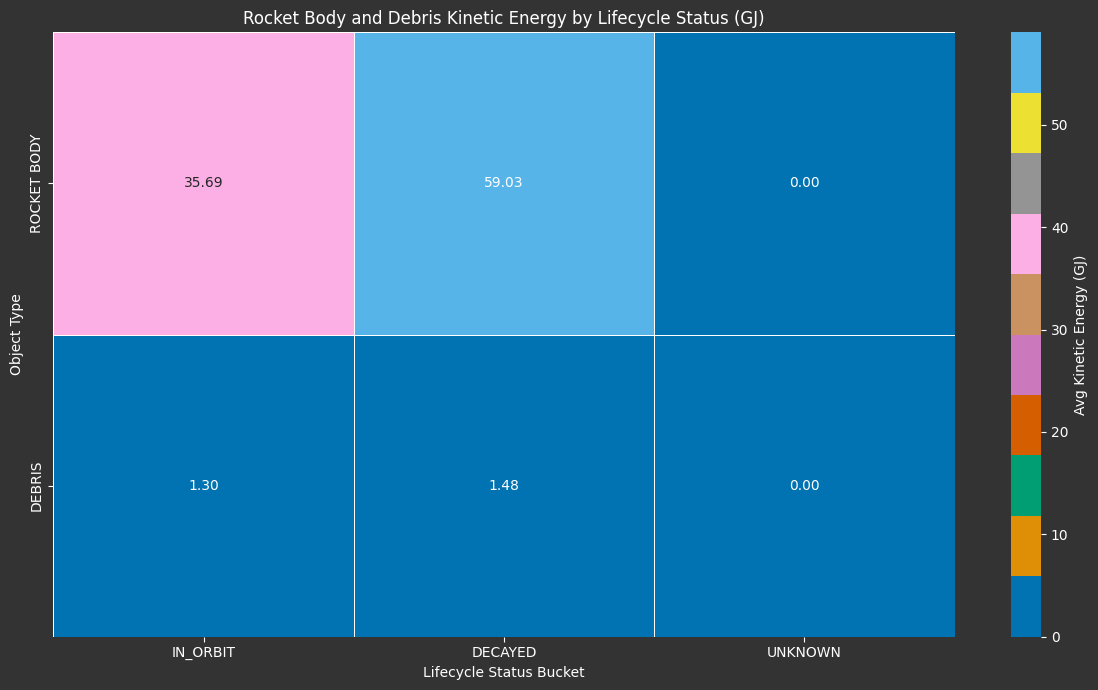

In [45]:
if df_kinetic_by_type_status.empty:
    print('No kinetic risk data available.')
else:
    type_order = ['PAYLOAD', 'ROCKET BODY', 'DEBRIS']
    df_known = df_kinetic_by_type_status[
        df_kinetic_by_type_status['object_type'].isin(type_order)
    ].copy()
    
    if df_known.empty:
        print('No data available for known object types.')
    else:
        # Keep only rows with kinetic data for average-energy charts.
        df_known = df_known[df_known['kinetic_joules'].notna()].copy()
        
        # Payloads use ops_status semantics.
        payload_df = df_known[df_known['object_type'] == 'PAYLOAD'].copy()
        payload_status_order = ['OPERATIONAL', 'NON-OPERATIONAL', 'OTHER', 'UNKNOWN']
        
        payload_df['status_bucket'] = payload_df['ops_status'].apply(utils.map_payload_status)
        
        # Non-payload objects use lifecycle semantics.
        non_payload_df = df_known[df_known['object_type'].isin(['ROCKET BODY', 'DEBRIS'])].copy()
        lifecycle_order = ['IN_ORBIT', 'DECAYED', 'UNKNOWN']
        
        non_payload_df['status_bucket'] = non_payload_df.apply(utils.map_lifecycle_status, axis=1)
        
        # Payload operational-status kinetic energy (GJ).
        # 1 GJ = 1e9 J, so we divide by 1e9 to convert from joules to gigajoules for more readable chart values.
        payload_energy = (
            payload_df.groupby('status_bucket', dropna=False)['kinetic_joules']
            .mean()
            .reindex(payload_status_order, fill_value=0)
            / 1e9
        )
        
        plt.figure(figsize=(12, 7))
        ax = sns.barplot(
            x=payload_energy.index,
            y=payload_energy.values,
            color='#1d8cdb'
        )
        
        # average kinetic energy annotation at the top of the bars
        # you can infer this from the y axis, but this makes it a bit easier to quickly register the actual values
        for avg_bar in ax.patches:
            ax.text(
                avg_bar.get_x() + avg_bar.get_width() / 2,
                avg_bar.get_height() + 0.15,
                f'{avg_bar.get_height():.2f} GJ Avg',
                ha='center', va='bottom',
                fontsize=10, color='white'
            )
        
        ax.set_title('Payload Kinetic Energy by Operational Status (GJ)')
        ax.set_xlabel('Payload Operational Status Bucket')
        ax.set_ylabel('Average Kinetic Energy (GJ)')
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('../charts/kinetic_risk_payload_ops_status_exp.png', bbox_inches='tight', dpi=100)
        plt.show()
        
        # Non-payload lifecycle kinetic energy heatmap (GJ).
        non_payload_energy = non_payload_df.pivot_table(
            index='object_type',
            columns='status_bucket',
            values='kinetic_joules',
            aggfunc='mean',
            fill_value=0
        )
        
        non_payload_energy = non_payload_energy.reindex(['ROCKET BODY', 'DEBRIS'], fill_value=0)
        non_payload_energy = non_payload_energy.reindex(columns=lifecycle_order, fill_value=0)
        non_payload_energy_gj = non_payload_energy / 1e9
        
        plt.figure(figsize=(12, 7))
        
        # Non-payload kinetic energy heatmap
        sns.heatmap(
            non_payload_energy_gj,
            annot=True,
            fmt='.2f',
            cmap=sns.color_palette("colorblind", as_cmap=True),
            cbar_kws={'label': 'Avg Kinetic Energy (GJ)'},
            linewidths=0.5
        )
        
        plt.title('Rocket Body and Debris Kinetic Energy by Lifecycle Status (GJ)')
        plt.xlabel('Lifecycle Status Bucket')
        plt.ylabel('Object Type')
        
        plt.tight_layout()
        plt.savefig('../charts/kinetic_risk_nonpayload_lifecycle_exp.png', bbox_inches='tight', dpi=100)
        plt.show()


## User Category Risk Profiles

Measure how risk differs by user category for in-orbit objects, focusing on category mix and kinetic-risk signals.

**Explore:**
- User Category Breakdown: Distribution of objects by user category (commercial, government, military, civil)
- Risk by User Category: Kinetic risk, operational status, and age by user category

### User Category Breakdown: Distribution of In-Orbit Objects by User Category

Show how in-orbit objects are distributed across user categories such as commercial, government, military, and civil.

**Method:**
- Pull in-orbit objects and map each record to a user category.
- Standardize missing or unmapped values into `UNKNOWN`.
- Count objects by user category and calculate each category share.

**Visuals:**
- A bar chart showing in-orbit object count by user category.
- A percentage table showing each category's share of total in-orbit objects.

**How to Read This:**
- Taller bars mean that category has more in-orbit objects.
- Category share helps compare concentration beyond raw counts.
- A larger `UNKNOWN` bucket suggests data-mapping limits that should be noted in conclusions.

In [46]:
in_orbit_by_category_query = """
SELECT
  satellites.norad_id,
  COALESCE(satellites.user_category, 'UNKNOWN') AS user_category
FROM satellites
WHERE satellites.in_orbit = 1;
"""

df_in_orbit_by_category = pd.read_sql_query(in_orbit_by_category_query, orbital_debris_conn)
df_in_orbit_by_category.to_parquet('../data/clean/results/in_orbit_by_category_exp.parquet', index=False)

print(f"In-orbit objects with category fields: {len(df_in_orbit_by_category):,}")

# Display the distribution of user categories for in-orbit objects with pct of total in orbit for context.
category_counts = df_in_orbit_by_category['user_category'].value_counts(dropna=False)
category_pct = (df_in_orbit_by_category['user_category'].value_counts(normalize=True, dropna=False) * 100).round(2)

category_summary = pd.DataFrame({
    'count': category_counts,
    'pct_of_in_orbit': category_pct.map("{:.2f}%".format)
})

In-orbit objects with category fields: 34,044


,count,pct_of_in_orbit
user_category,,
COMMERCIAL,19786,58.12%
MILITARY,7650,22.47%
GOVERNMENT,6354,18.66%
CIVIL,181,0.53%
UNKNOWN,73,0.21%


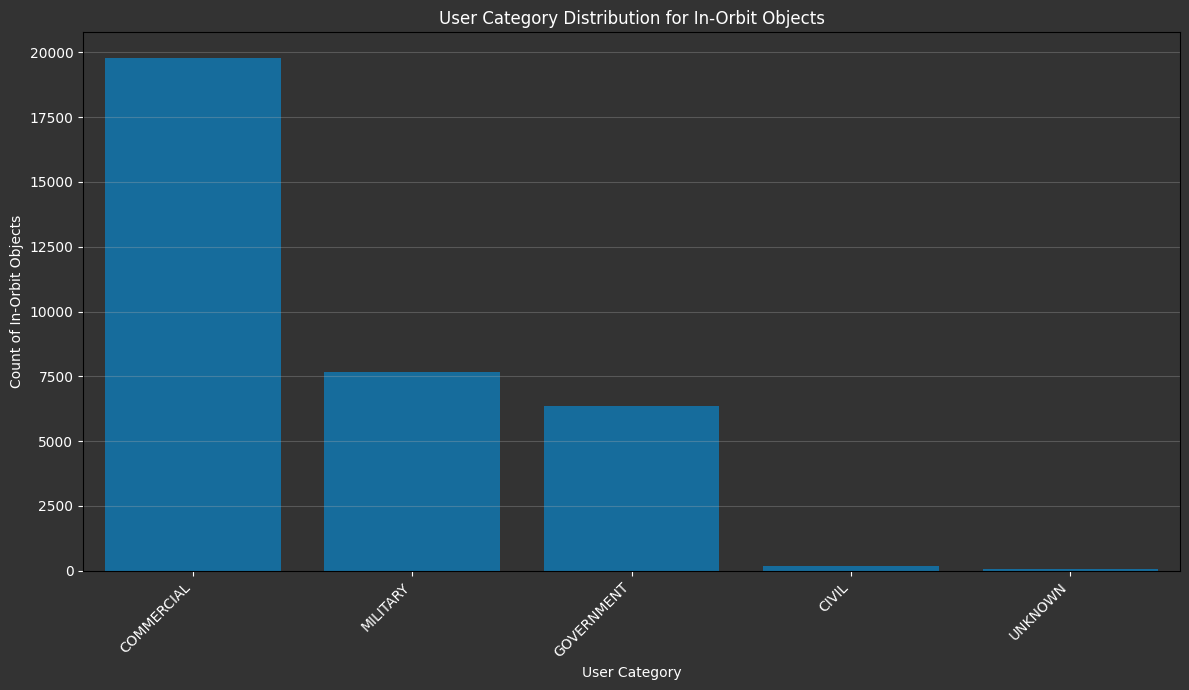

In [47]:
if category_summary.empty:
    print('No user category data available for in-orbit objects.')
else:
    display(category_summary)
    
    # Bar chart of user category distribution for in-orbit objects.
    
    plt.figure(figsize=(12, 7))
    
    sns.barplot(
        x=category_summary.index,
        y=category_summary['count'],
        color='#0072B2'
    )
    
    plt.title('User Category Distribution for In-Orbit Objects')
    plt.xlabel('User Category')
    plt.ylabel('Count of In-Orbit Objects')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../charts/in_orbit_user_category_distribution_exp.png', bbox_inches='tight', dpi=100)
    plt.show()

### Risk by User Category: Kinetic Risk, Operational Status, and Age

Compare user categories on three different risk signals for in-orbit objects.

**Method:**
- Pull one in-orbit dataset keyed by `satellites.user_category`.
- Use all in-orbit objects for kinetic-risk comparisons.
- Use payload-only rows for operational-status and age comparisons, because those fields are payload-centric in this schema.
- Map payload statuses into four buckets: `OPERATIONAL`, `NON-OPERATIONAL`, `OTHER`, and `UNKNOWN`.

**Visuals:**
- A bar chart of median kinetic energy by user category.
- A stacked bar chart of payload operational-status share by user category.
- A box plot of payload satellite age by user category.

**How to Read This:**
- Higher median kinetic energy suggests the category tends to control more collision-consequential in-orbit mass and velocity.
- A larger `NON-OPERATIONAL` share suggests more inactive payloads still occupying orbit.
- Older payload age distributions can indicate legacy fleets or slower turnover within that category.

In [48]:
user_category_risk_query = """
SELECT
  satellites.norad_id,
  COALESCE(satellites.user_category, 'UNKNOWN') AS user_category,
  COALESCE(satellites.object_type, 'UNKNOWN') AS object_type,
  COALESCE(satellites.ops_status, 'UNKNOWN') AS ops_status,
  risk_assessment.kinetic_joules,
  ucs_details.sat_age_years
FROM satellites
LEFT JOIN risk_assessment ON satellites.norad_id = risk_assessment.norad_id
LEFT JOIN ucs_details ON satellites.norad_id = ucs_details.norad_id
WHERE satellites.in_orbit = 1;
"""

df_user_category_risk = pd.read_sql_query(user_category_risk_query, orbital_debris_conn)

df_user_category_risk['kinetic_joules'] = pd.to_numeric(df_user_category_risk['kinetic_joules'], errors='coerce')
df_user_category_risk['sat_age_years'] = pd.to_numeric(df_user_category_risk['sat_age_years'], errors='coerce')

df_user_category_risk.to_parquet('../data/clean/results/user_category_risk_profile_exp.parquet', index=False)

print(f"In-orbit objects in user-category risk view: {len(df_user_category_risk):,}")
print(f"Objects with kinetic-risk data: {df_user_category_risk['kinetic_joules'].notna().sum():,}")

payload_user_category_risk = df_user_category_risk[
    df_user_category_risk['object_type'] == 'PAYLOAD'
].copy()

print(f"Payloads in user-category risk view: {len(payload_user_category_risk):,}")
print(f"Payloads with age data: {payload_user_category_risk['sat_age_years'].notna().sum():,}")

In-orbit objects in user-category risk view: 34,044
Objects with kinetic-risk data: 34,044
Payloads in user-category risk view: 19,085
Payloads with age data: 19,085


,user_category,objects_in_orbit,objects_with_risk,median_kinetic_gj,avg_kinetic_gj,payload_count,operational_share_pct,non_operational_share_pct,median_age_years,avg_age_years
0,COMMERCIAL,19786,19786,10.179589,8.878651,14965,87.611093,6.181089,2.0,5.967925
1,MILITARY,7650,7650,1.401086,9.462328,2132,33.818011,16.744841,34.0,28.896341
2,GOVERNMENT,6354,6354,1.397903,8.577863,1769,86.546071,9.553420,3.0,6.747880
3,CIVIL,181,181,9.913195,6.155434,180,67.777778,20.000000,8.0,11.433333
4,UNKNOWN,73,73,10.328428,11.711094,39,58.974359,20.512821,2.0,16.512821


status_bucket,OPERATIONAL,NON-OPERATIONAL,OTHER,UNKNOWN
user_category,,,,
COMMERCIAL,87.611093,6.181089,3.374541,2.833278
MILITARY,33.818011,16.744841,0.609756,48.827392
GOVERNMENT,86.546071,9.553420,2.713397,1.187111
CIVIL,67.777778,20.000000,2.777778,9.444444
UNKNOWN,58.974359,20.512821,5.128205,15.384615


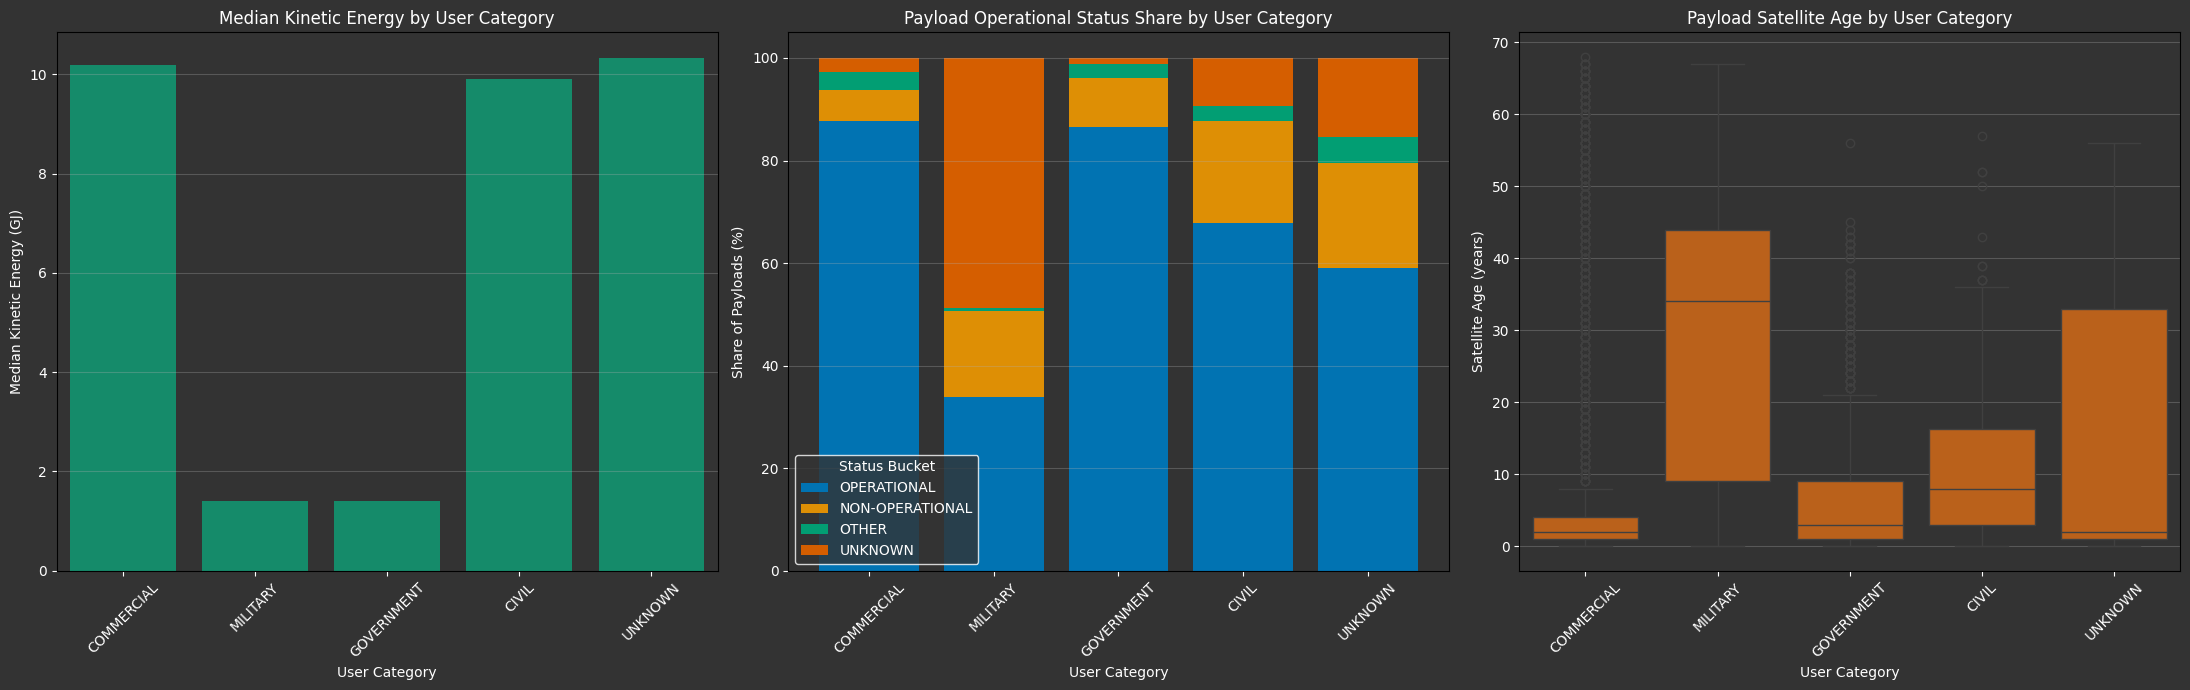

In [49]:
if df_user_category_risk.empty:
    print('No user-category risk data available for in-orbit objects.')
else:
    category_order = ['COMMERCIAL', 'MILITARY', 'GOVERNMENT', 'CIVIL', 'UNKNOWN']
    status_order = ['OPERATIONAL', 'NON-OPERATIONAL', 'OTHER', 'UNKNOWN']

    available_categories = [category for category in category_order if category in df_user_category_risk['user_category'].unique() ]

    df_user_category_risk['user_category'] = pd.Categorical(
        df_user_category_risk['user_category'],
        categories=category_order,
        ordered=True
    )

    kinetic_summary = (
        df_user_category_risk[df_user_category_risk['kinetic_joules'].notna()]
        .groupby('user_category', observed=False)
        .agg(
            objects_with_risk=('norad_id', 'count'),
            median_kinetic_joules=('kinetic_joules', 'median'),
            avg_kinetic_joules=('kinetic_joules', 'mean')
        )
        .reindex(available_categories)
    )

    payload_user_category_risk['user_category'] = pd.Categorical(
        payload_user_category_risk['user_category'],
        categories=category_order,
        ordered=True
    )
    
    payload_user_category_risk['status_bucket'] = payload_user_category_risk['ops_status'].apply(utils.map_payload_status)

    status_share = (
        pd.crosstab(
            payload_user_category_risk['user_category'],
            payload_user_category_risk['status_bucket'],
            normalize='index'
        )
        .reindex(index=available_categories, columns=status_order, fill_value=0)
        * 100
    )

    age_summary = (
        payload_user_category_risk.groupby('user_category', observed=False)
        .agg(
            payload_count=('norad_id', 'count'),
            payloads_with_age=('sat_age_years', lambda values: values.notna().sum()),
            operational_share_pct=('status_bucket', lambda values: (values == 'OPERATIONAL').mean() * 100),
            non_operational_share_pct=('status_bucket', lambda values: (values == 'NON-OPERATIONAL').mean() * 100),
            median_age_years=('sat_age_years', 'median'),
            avg_age_years=('sat_age_years', 'mean')
        )
        .reindex(available_categories)
    )

    user_category_risk_summary = (
        df_user_category_risk.groupby('user_category', observed=False)
        .agg(objects_in_orbit=('norad_id', 'count'))
        .reindex(available_categories)
        .join(kinetic_summary)
        .join(age_summary)
        .reset_index()
    )

    user_category_risk_summary['median_kinetic_gj'] = user_category_risk_summary['median_kinetic_joules'] / 1e9
    user_category_risk_summary['avg_kinetic_gj'] = user_category_risk_summary['avg_kinetic_joules'] / 1e9

    user_category_risk_summary.to_parquet('../data/clean/results/user_category_risk_summary_exp.parquet', index=False)
    status_share.reset_index().to_parquet('../data/clean/results/user_category_payload_status_share_exp.parquet', index=False)

    display(
        user_category_risk_summary[
            [
                'user_category',
                'objects_in_orbit',
                'objects_with_risk',
                'median_kinetic_gj',
                'avg_kinetic_gj',
                'payload_count',
                'operational_share_pct',
                'non_operational_share_pct',
                'median_age_years',
                'avg_age_years'
            ]
        ]
    )

    display(status_share)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))

    kinetic_plot = user_category_risk_summary.dropna(subset=['median_kinetic_gj']).copy()
    sns.barplot(
        data=kinetic_plot,
        x='user_category',
        y='median_kinetic_gj',
        color=COLOR_PALETTE[2],
        ax=ax1
    )
    ax1.set_title('Median Kinetic Energy by User Category')
    ax1.set_xlabel('User Category')
    ax1.set_ylabel('Median Kinetic Energy (GJ)')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)

    status_share.plot(
        kind='bar',
        stacked=True,
        ax=ax2,
        color=COLOR_PALETTE[:len(status_share.columns)],
        width=0.8
    )
    ax2.set_title('Payload Operational Status Share by User Category')
    ax2.set_xlabel('User Category')
    ax2.set_ylabel('Share of Payloads (%)')
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend(title='Status Bucket', frameon=True)
    ax2.grid(axis='y', alpha=0.3)

    age_plot = payload_user_category_risk[
        payload_user_category_risk['sat_age_years'].notna()
        & payload_user_category_risk['user_category'].isin(available_categories)
    ].copy()

    if age_plot.empty:
        ax3.text(0.5, 0.5, 'No payload age data available.', ha='center', va='center')
        ax3.set_axis_off()
    else:
        sns.boxplot(
            data=age_plot,
            x='user_category',
            y='sat_age_years',
            order=available_categories,
            color=COLOR_PALETTE[3],
            ax=ax3
        )
        ax3.set_title('Payload Satellite Age by User Category')
        ax3.set_xlabel('User Category')
        ax3.set_ylabel('Satellite Age (years)')
        ax3.tick_params(axis='x', rotation=45)
        ax3.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('../charts/user_category_risk_profile_exp.png', bbox_inches='tight', dpi=100)
    plt.show()

### Owners by Total Active Payload Contribution

Show which satellite owners are responsible for the most operational ("active") payloads currently in orbit.

**Method:**
- Join the satellites table with ownership metadata to get owner and owner code for each payload.
- Filter for objects labeled as payloads that are still in orbit and have an operational status of 'OPERATIONAL'.
- For each owner, count the number of active payloads.
- Assign each owner their most common owner code for consistent labeling.
- Select the top 20 owners by active payload count.

**Visuals:**
- A horizontal bar chart showing the top 20 owners by their total number of active payloads in orbit.
- Each bar is colored by the owner's most common owner code.

**How to Read This:**
- Longer bars mean an owner has more operational payloads currently in orbit.
- Owners with high active counts are likely to be major constellation operators or national programs.
- Compare with zombie payload charts to see which organizations are best at maintaining operational fleets and minimizing non-operational satellites.

In [50]:
# ops_top_contractor_active_contributors_exp query goes here
ops_top_contractor_active_contributors_query = """
SELECT DISTINCT
  satellites.norad_id,
  ownership_operators.owner,
  ownership_operators.owner_code,
  COALESCE(ownership_operators.country_operator, 'UNKNOWN') AS country_operator,
  COALESCE(ownership_operators.contractor, 'UNKNOWN') AS contractor,
  COALESCE(satellites.ops_status, 'UNKNOWN') AS ops_status
FROM satellites
LEFT JOIN ownership_operators ON satellites.owner_code = ownership_operators.owner_code
WHERE satellites.object_type = 'PAYLOAD'
  AND satellites.in_orbit = 1;
"""

df_owner_all_payloads = pd.read_sql_query(ops_top_contractor_active_contributors_query, orbital_debris_conn)
df_owner_all_payloads.to_parquet('../data/clean/results/all_payloads_owner_contributors_exp.parquet', index=False)

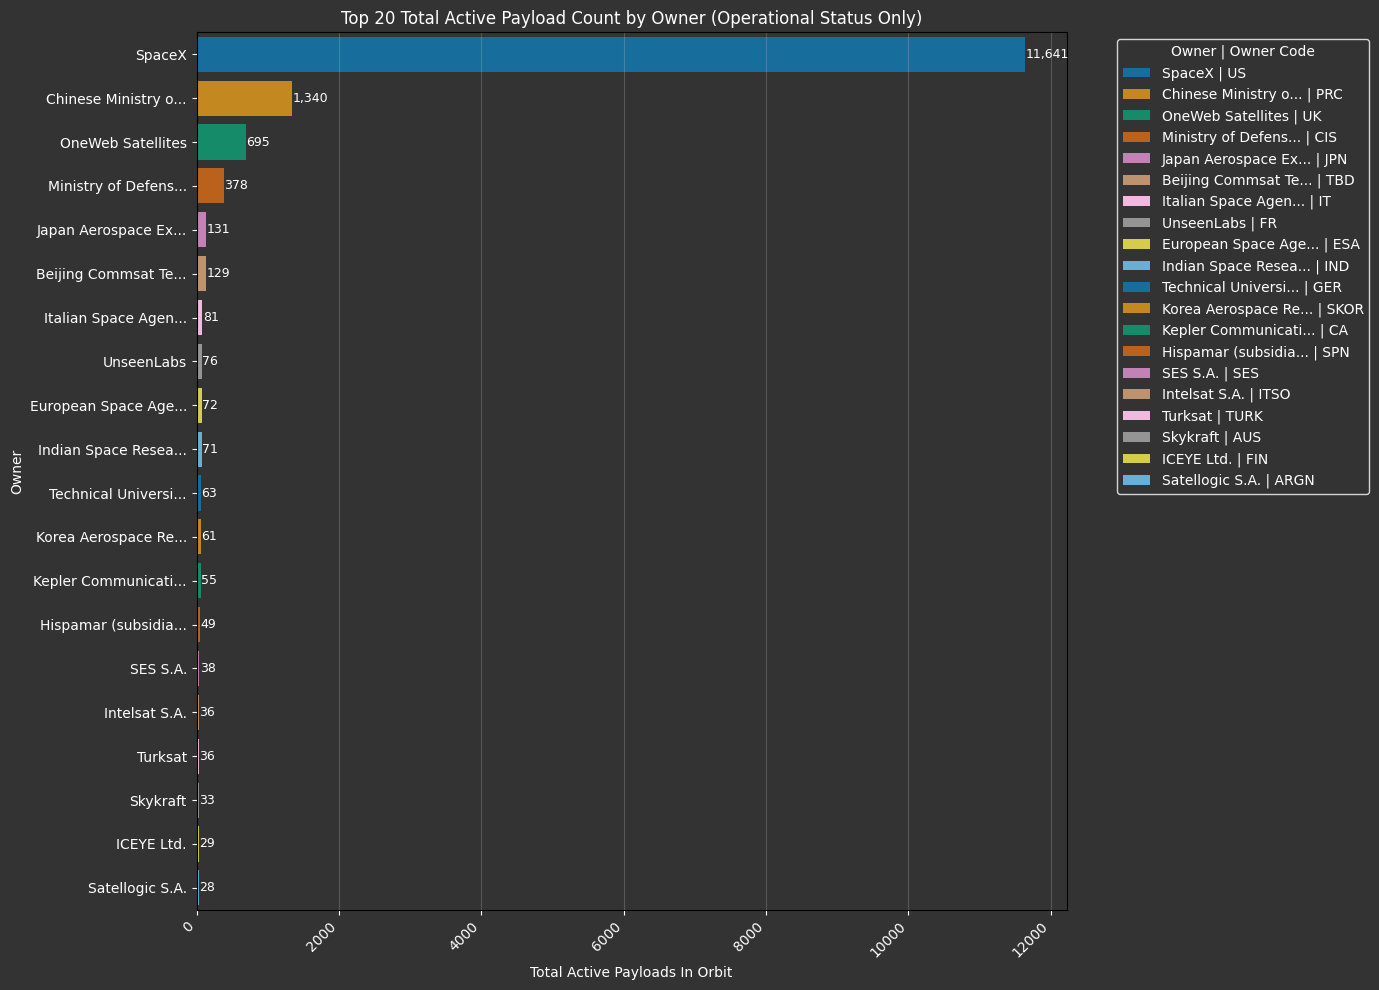

In [51]:
df_owner_active_payloads = df_owner_all_payloads[df_owner_all_payloads['ops_status'] == 'OPERATIONAL']
df_owner_active_payloads.to_parquet('../data/clean/results/active_payloads_owner_contributors_exp.parquet', index=False)

owner_active_counts = (
  df_owner_active_payloads
  .groupby(['owner'], dropna=False)
  .agg(active_payload_count=('norad_id', 'count'))
  .reset_index()
  .sort_values('active_payload_count', ascending=False)
  .head(20)
)

# Get the most common owner_code for each owner
owner_code_mode = (
    df_owner_all_payloads
    .groupby('owner')['owner_code']
    .agg(lambda x: x.dropna().mode().iloc[0] if not x.dropna().empty else None)
    .reset_index()
)

owner_active_counts = owner_active_counts.merge(
    owner_code_mode,
    on='owner',
    how='left'
)

owner_active_counts['owner_short'] = owner_active_counts['owner'].apply(lambda x: x if len(str(x)) <= 18 else str(x)[:18] + '...')
owner_active_counts['owner_label'] = (
  owner_active_counts['owner_short'].astype(str) + ' | ' +
  owner_active_counts['owner_code'].astype(str)
)

plt.figure(figsize=(14, 10))

sns.barplot(
  data=owner_active_counts,
  y='owner_short',
  x='active_payload_count',
  hue='owner_label',
  palette='colorblind',
  dodge=False
)

for bar in plt.gca().patches:
  width = bar.get_width()
  y = bar.get_y() + bar.get_height() / 2
  
  if width > 0:
    plt.gca().annotate(
      f'{int(width):,}',
      (width + 5, y),  # 5 is a small offset to the right
      ha='left',
      va='center',
      fontsize=9,
      color='white'
    )
      
plt.legend(title='Owner | Owner Code', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Top 20 Total Active Payload Count by Owner (Operational Status Only)')
plt.xlabel('Total Active Payloads In Orbit')
plt.ylabel('Owner')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../charts/active_top_owner_contributors_exp.png', bbox_inches='tight', dpi=100)
plt.show()

### Debris Size Distribution: Radar Cross Section (RCS) by Class

Analyze the physical size spectrum of orbital debris using radar cross section (RCS) classes.

**Method:**
- Query all in-orbit debris objects, joining satellite and orbital data to extract RCS values and RCS class.
- Use violin plots to show the distribution of RCS values (on a log scale) by RCS class.
- Use a bar chart to show the count of debris objects in each RCS class.

**Visuals:**
- Violin plot of debris RCS value distribution by RCS class (log scale).
- Bar chart of debris count by RCS class.

**How to Read This:**
- Wider violin plots indicate greater diversity in debris size within a class.
- Taller bars indicate more debris objects in that RCS class.
- The log scale reveals the presence of both small fragments and rare, very large debris pieces.

In [52]:
debris_rcs_query = """
SELECT
    satellites.norad_id,
    COALESCE(satellites.object_type, 'UNKNOWN') AS object_type,
    orbital_data.rcs,
    COALESCE(orbital_data.rcs_class, 'UNKNOWN') AS rcs_class
FROM satellites
JOIN orbital_data ON satellites.norad_id = orbital_data.norad_id
WHERE satellites.object_type = 'DEBRIS'
  AND satellites.in_orbit = 1;
"""

df_debris_rcs = pd.read_sql_query(debris_rcs_query, orbital_debris_conn)
df_debris_rcs.to_parquet('../data/clean/results/debris_rcs_exp.parquet', index=False)

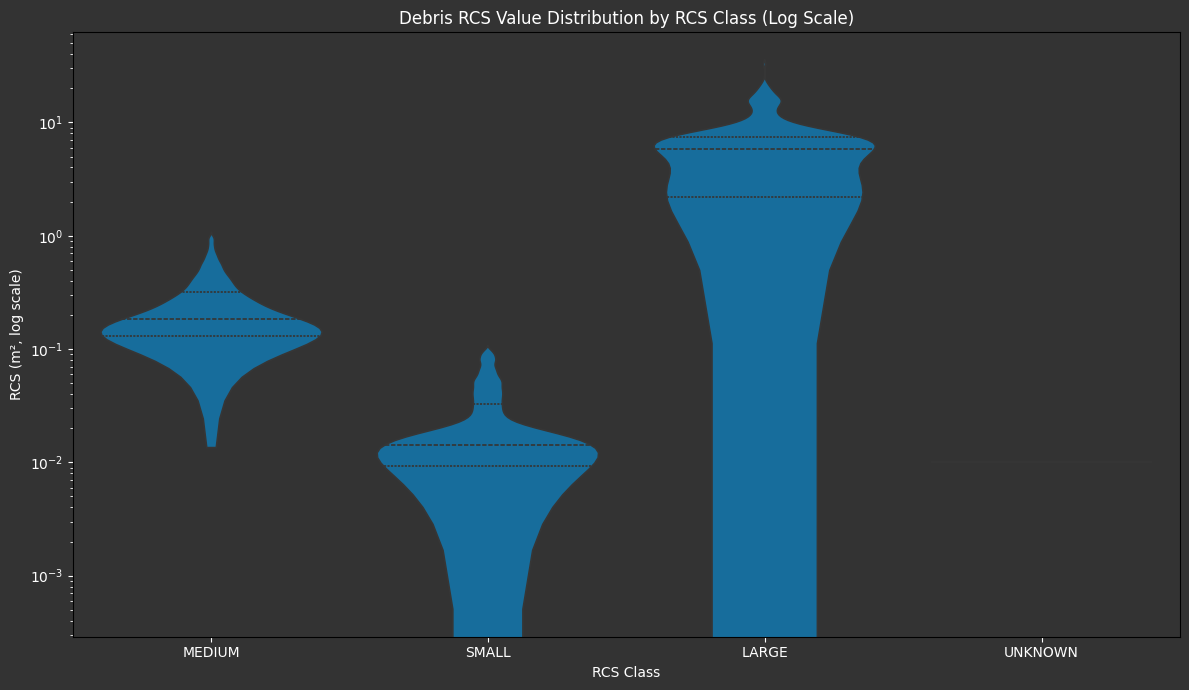

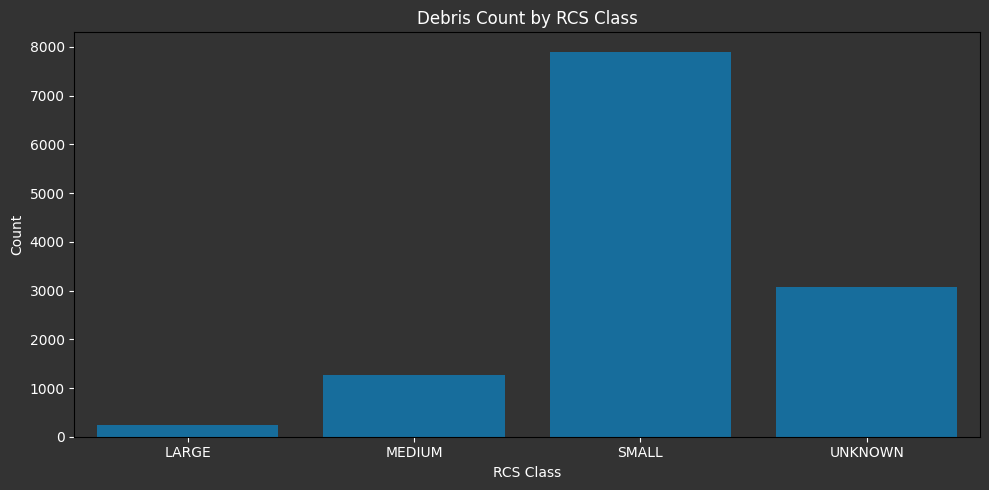

In [53]:
plt.figure(figsize=(12, 7))

sns.violinplot(
  data=df_debris_rcs,
  x='rcs_class',
  y='rcs',
  density_norm='width',
  inner='quartile'
)

plt.yscale('log')
plt.title('Debris RCS Value Distribution by RCS Class (Log Scale)')
plt.xlabel('RCS Class')
plt.ylabel('RCS (m², log scale)')

plt.tight_layout()
plt.savefig('../charts/debris_rcs_distribution_by_class_exp.png', bbox_inches='tight', dpi=100)
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_debris_rcs,
    x='rcs_class',
    order=sorted(df_debris_rcs['rcs_class'].unique())
)

plt.title('Debris Count by RCS Class')
plt.xlabel('RCS Class')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../charts/debris_rcs_count_by_class_exp.png', bbox_inches='tight', dpi=100)
plt.show()

### Zombie Payloads and Status by User Category

Analyze the distribution and age profile of non-operational (“zombie”) satellites by user category, and visualize the full operational status and age breakdowns.

**Method:**
- Query all in-orbit payloads with known age and user category from the database.
- Filter for `ops_status = 'NON-OPERATIONAL'` to define “zombie” payloads.
- Group by user category and operational status to count payloads and summarize their age.
- Save summary tables as Parquet for reproducibility and downstream use.

**Visuals:**
- Bar chart of zombie payload count by user category.
- Bar chart of average age of zombie payloads by user category.
- Heatmap of payload count by user category and operational status.
- Heatmap of average payload age by user category and operational status.

**How to Read This:**
- Taller bars in the count chart indicate user categories with more non-operational payloads in orbit.
- Higher bars in the age chart reveal categories with older legacy zombies, suggesting slower removal or longer-lived failures.
- The count heatmap shows the full operational status mix for each user category, highlighting which groups have the most active, inactive, or unknown-status payloads.
- The average age heatmap reveals which user categories and status groups have the oldest or youngest payloads, helping to identify legacy fleets or recent failures.

In [54]:
category_payload_status_query = """
SELECT
    satellites.norad_id,
    satellites.category,
    COALESCE(satellites.user_category, 'UNKNOWN') AS user_category,
    COALESCE(satellites.ops_status, 'UNKNOWN') AS ops_status,
    ucs_details.sat_age_years,
    orbital_data.proxy_mass_kg
FROM satellites
LEFT JOIN ucs_details ON satellites.norad_id = ucs_details.norad_id
LEFT JOIN orbital_data ON satellites.norad_id = orbital_data.norad_id
WHERE satellites.object_type = 'PAYLOAD'
  AND satellites.in_orbit = 1
  AND ucs_details.sat_age_years IS NOT NULL
ORDER BY ucs_details.sat_age_years DESC;
"""

df_category_payload_status_all = pd.read_sql_query(category_payload_status_query, orbital_debris_conn)
df_category_payload_status_all.to_parquet('../data/clean/results/category_payload_status_all_exp.parquet', index=False)

df_category_payload_zombies = df_category_payload_status_all[
    df_category_payload_status_all['ops_status'] == 'NON-OPERATIONAL'
].copy()

df_category_payloads_grouped = (
    df_category_payload_status_all.groupby(['user_category', 'ops_status'], observed=False)
    .agg(
        payload_count=('norad_id', 'count'),
        median_age_years=('sat_age_years', 'median'),
        avg_age_years=('sat_age_years', 'mean'),
        median_mass_kg=('proxy_mass_kg', 'median'),
        avg_mass_kg=('proxy_mass_kg', 'mean')
    )
    .reset_index()
)

df_category_payloads_grouped.to_parquet('../data/clean/results/category_payloads_status_summary_exp.parquet', index=False)

df_category_payload_zombies_grouped = (
    df_category_payload_zombies.groupby(['user_category', 'ops_status'], observed=False)
    .agg(
        payload_count=('norad_id', 'count'),
        median_age_years=('sat_age_years', 'median'),
        avg_age_years=('sat_age_years', 'mean'),
        median_mass_kg=('proxy_mass_kg', 'median'),
        avg_mass_kg=('proxy_mass_kg', 'mean')
    )
    .reset_index()
)

df_category_payload_zombies_grouped.to_parquet('../data/clean/results/category_payload_zombies_exp.parquet', index=False)

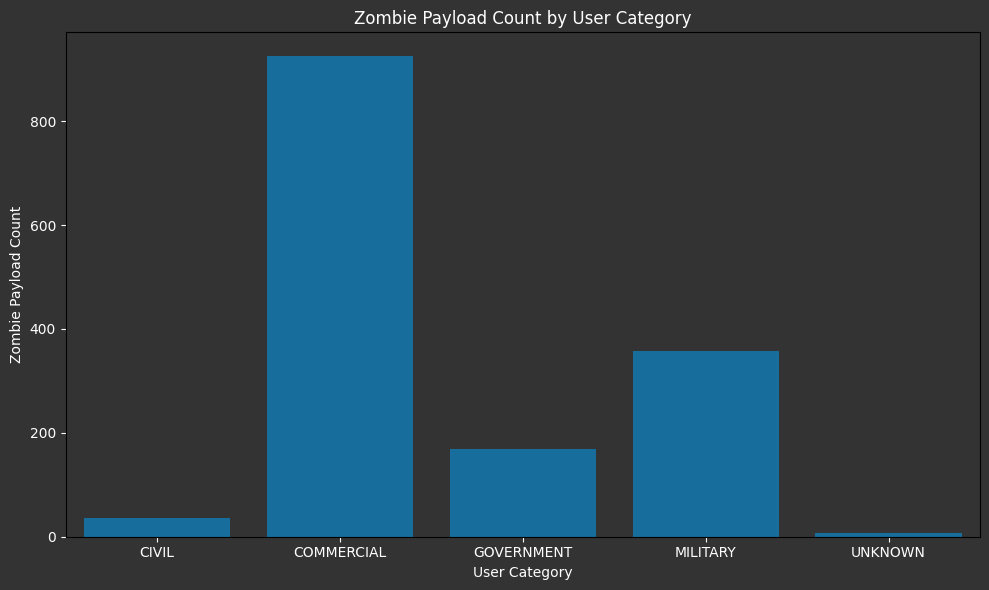

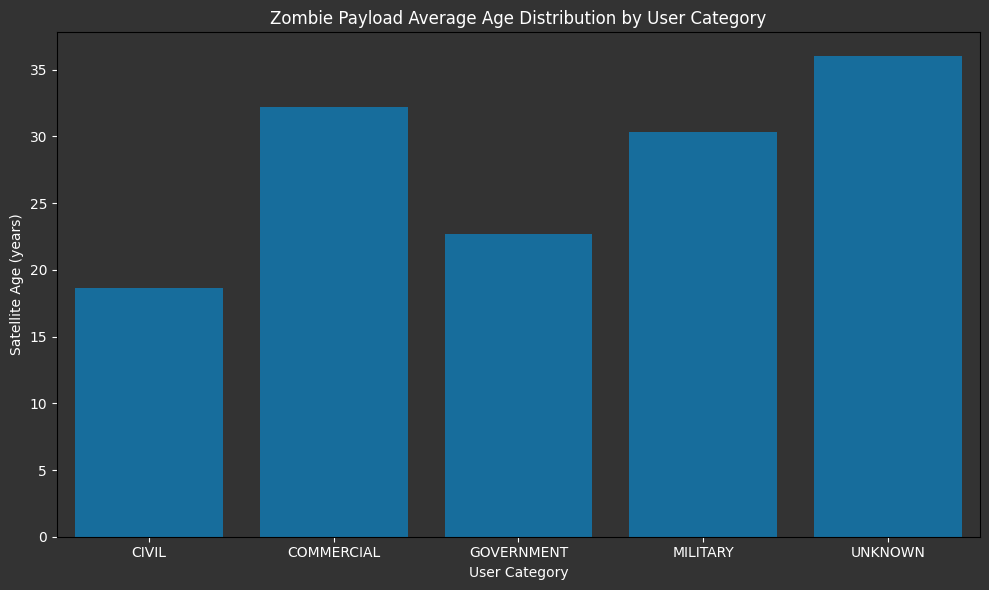

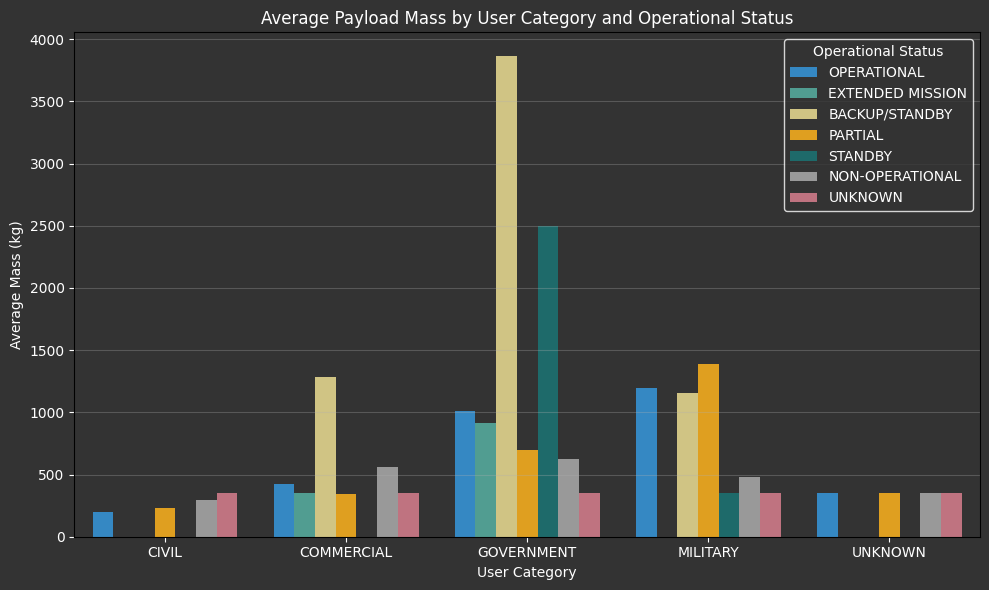

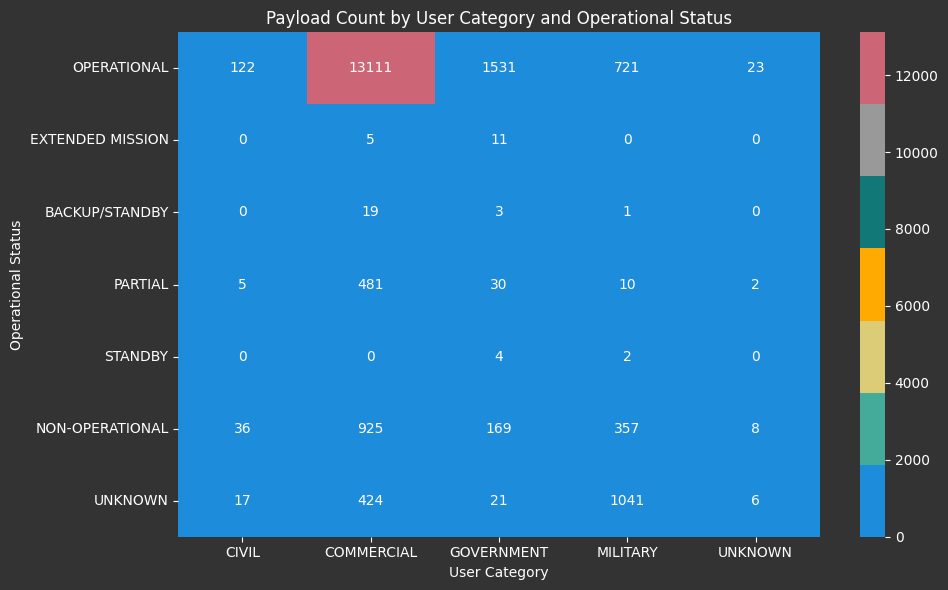

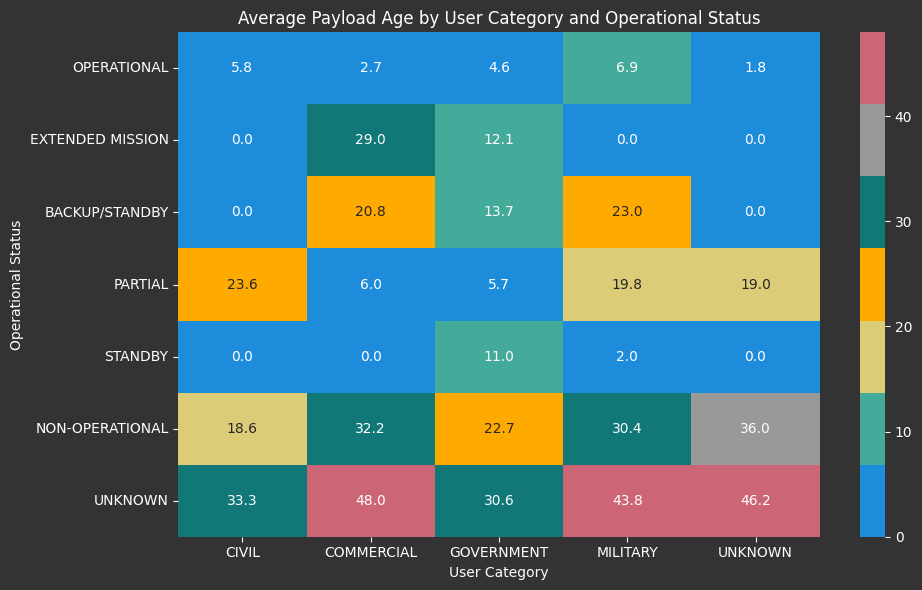

In [55]:
# Bar chart of zombie payload count by user category.
plt.figure(figsize=(10, 6))

sns.barplot(
  data=df_category_payload_zombies_grouped,
  x='user_category',
  y='payload_count',
)

plt.title('Zombie Payload Count by User Category')
plt.xlabel('User Category')
plt.ylabel('Zombie Payload Count')

plt.tight_layout()
plt.savefig('../charts/zombie_payload_count_by_user_category_exp.png', bbox_inches='tight', dpi=100)
plt.show()

# Bar chart of average age of non-operational payloads by user category.
plt.figure(figsize=(10, 6))

sns.barplot(
  data=df_category_payload_zombies_grouped,
  x='user_category',
  y='avg_age_years',
)

plt.title('Zombie Payload Average Age Distribution by User Category')
plt.xlabel('User Category')
plt.ylabel('Satellite Age (years)')

plt.tight_layout()
plt.savefig('../charts/zombie_payload_avg_age_by_user_category_exp.png', bbox_inches='tight', dpi=100)
plt.show()

# Bar chart of average mass of payloads by user category and operational status.

# custom ops status color palette to ensure consistent mapping across charts
ops_status_mapping = {
    'OPERATIONAL': '#1d8cdb',     
    'EXTENDED MISSION': '#44aa99', 
    'BACKUP/STANDBY': '#ddcc77',   
    'PARTIAL': '#ffaa00',          
    'STANDBY': '#117777',           
    'NON-OPERATIONAL': '#999999',   
    'UNKNOWN': '#cc6677'            
}

ops_status_order = ['OPERATIONAL', 'EXTENDED MISSION', 'BACKUP/STANDBY', 'PARTIAL', 'STANDBY', 'NON-OPERATIONAL', 'UNKNOWN']

colors = [ops_status_mapping.get(status, '#999999') for status in ops_status_order]

plt.figure(figsize=(10, 6))
sns.barplot(
  data=df_category_payloads_grouped,
  x='user_category',
  y='avg_mass_kg',
  hue='ops_status',
  palette=colors,
  hue_order=ops_status_order
)

plt.title('Average Payload Mass by User Category and Operational Status')
plt.xlabel('User Category')
plt.ylabel('Average Mass (kg)')
plt.legend(title='Operational Status')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../charts/payload_mass_user_category_ops_status_exp.png', bbox_inches='tight', dpi=100)
plt.show()

# Heatmap of payload count by user category and operational status.
pivot_count = (
  df_category_payload_status_all
  .groupby(['user_category', 'ops_status'])
  .size()
  .reset_index(name='count')
  .pivot(index='ops_status', columns='user_category', values='count')
  .fillna(0)
)

pivot_count = pivot_count.reindex(ops_status_order)

plt.figure(figsize=(10, 6))

sns.heatmap(pivot_count, annot=True, fmt=".0f", cmap=sns.color_palette(colors, as_cmap=True))

plt.title('Payload Count by User Category and Operational Status')
plt.xlabel('User Category')
plt.ylabel('Operational Status')

plt.tight_layout()
plt.savefig('../charts/payload_count_user_category_ops_status_heatmap_exp.png', bbox_inches='tight', dpi=100)
plt.show()

# Heatmap of average payload age by user category and operational status.
pivot_age = (
  df_category_payload_status_all
  .groupby(['user_category', 'ops_status'])
  .agg(avg_age_years=('sat_age_years', 'mean'))
  .reset_index()
  .pivot(index='ops_status', columns='user_category', values='avg_age_years')
  .fillna(0)
)

pivot_age = pivot_age.reindex(ops_status_order)

plt.figure(figsize=(10, 6))

sns.heatmap(pivot_age, annot=True, fmt=".1f", cmap=sns.color_palette(colors, as_cmap=True))

plt.title('Average Payload Age by User Category and Operational Status')
plt.xlabel('User Category')
plt.ylabel('Operational Status')

plt.tight_layout()
plt.savefig('../charts/payload_avg_age_user_category_ops_status_heatmap_exp.png', bbox_inches='tight', dpi=100)
plt.show()


## SpaceX Starlink Satellite Count

Query to determine how many of SpaceX's satellites are Starlink constellation satellites.

,ops_status,count
2,OPERATIONAL,2516
0,DECAYED,1098
3,PARTIAL,370
1,NON-OPERATIONAL,2


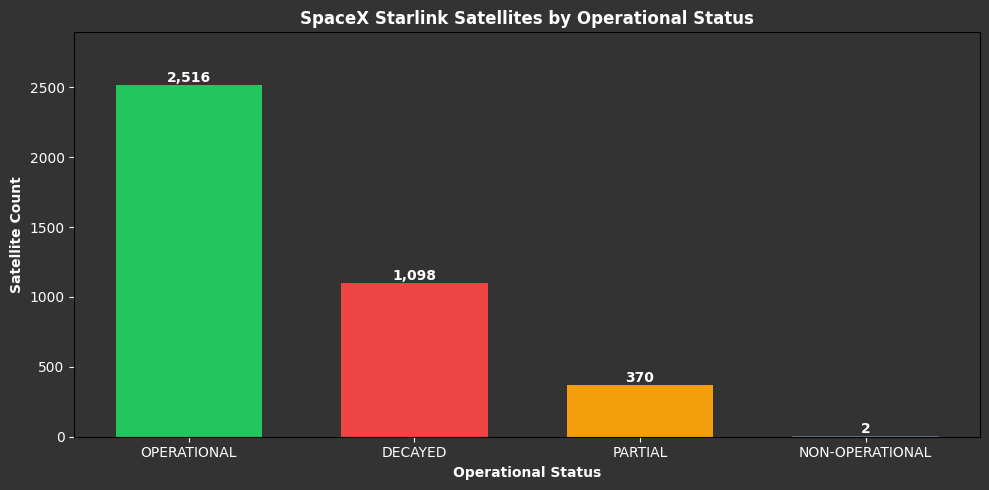

C:\Users\demon\AppData\Local\Temp\ipykernel_11928\661631392.py:101: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  spacex_ops_comparison.pivot_table(


segment,Other SpaceX,Starlink
ops_status,,
OPERATIONAL,9125,2516
DECAYED,9427,1098
PARTIAL,88,370
NON-OPERATIONAL,464,2
UNKNOWN,5034,0


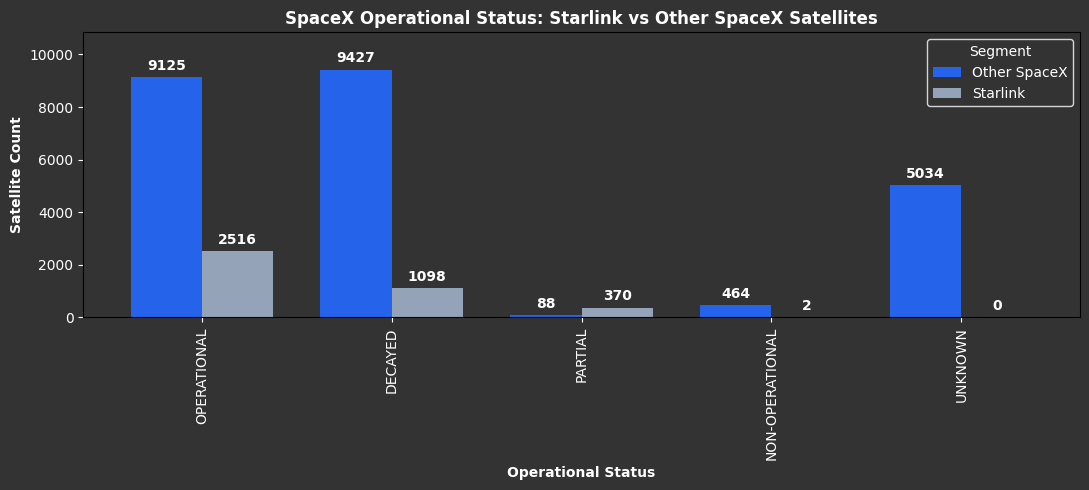

In [56]:
# Query SpaceX Starlink satellites and visualize the operational-status distribution
try:
    orbital_debris_conn.execute('SELECT 1')
except Exception:
    orbital_debris_conn = sql.connect('../data/clean/orbital_debris.db')

query = """
SELECT
    s.satellite_name,
    s.object_type,
    s.data_status,
    s.ops_status,
    ucs.primary_purpose,
    COUNT(*) as count
FROM satellites s
JOIN ownership_operators oo ON s.owner_code = oo.owner_code
JOIN ucs_details ucs ON s.norad_id = ucs.norad_id
WHERE oo.owner = 'SpaceX'
AND s.satellite_name LIKE '%Starlink%'
GROUP BY s.satellite_name, s.object_type, s.data_status, s.ops_status, ucs.primary_purpose
ORDER BY count DESC
"""

spacex_starlink_df = pd.read_sql_query(query, orbital_debris_conn)

ops_status_summary = (
    spacex_starlink_df.assign(ops_status=spacex_starlink_df['ops_status'].fillna('UNKNOWN'))
    .groupby('ops_status', dropna=False)['count']
    .sum()
    .reset_index()
)

status_order = ['OPERATIONAL', 'DECAYED', 'PARTIAL', 'NON-OPERATIONAL', 'UNKNOWN']
ops_status_summary['ops_status'] = pd.Categorical(
    ops_status_summary['ops_status'],
    categories=status_order,
    ordered=True,
)
ops_status_summary = ops_status_summary.sort_values('ops_status').dropna(subset=['ops_status'])

display(ops_status_summary)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#22c55e', '#ef4444', '#f59e0b', '#64748b', '#8b5cf6'][: len(ops_status_summary)]
bars = ax.bar(
    ops_status_summary['ops_status'].astype(str),
    ops_status_summary['count'],
    color=colors,
    width=0.65,
)

ax.set_ylabel('Satellite Count', fontweight='bold')
ax.set_xlabel('Operational Status', fontweight='bold')
ax.set_title('SpaceX Starlink Satellites by Operational Status', fontweight='bold')
ax.set_ylim(0, ops_status_summary['count'].max() * 1.15)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontweight='bold',
    )

plt.tight_layout()
plt.savefig('../charts/spacex_starlink_ops_status.png', bbox_inches='tight', dpi=100)
plt.show()

comparison_query = """
SELECT
    CASE
        WHEN s.satellite_name LIKE '%Starlink%' THEN 'Starlink'
        ELSE 'Other SpaceX'
    END AS segment,
    COALESCE(s.ops_status, 'UNKNOWN') AS ops_status,
    COUNT(*) AS count
FROM satellites s
JOIN ownership_operators oo ON s.owner_code = oo.owner_code
WHERE oo.owner = 'SpaceX'
GROUP BY
    CASE
        WHEN s.satellite_name LIKE '%Starlink%' THEN 'Starlink'
        ELSE 'Other SpaceX'
    END,
    COALESCE(s.ops_status, 'UNKNOWN')
ORDER BY segment, ops_status
"""

spacex_ops_comparison = pd.read_sql_query(comparison_query, orbital_debris_conn)
spacex_ops_comparison['ops_status'] = pd.Categorical(
    spacex_ops_comparison['ops_status'],
    categories=status_order,
    ordered=True,
)
spacex_ops_comparison = spacex_ops_comparison.sort_values(['ops_status', 'segment'])

comparison_pivot = (
    spacex_ops_comparison.pivot_table(
        index='ops_status',
        columns='segment',
        values='count',
        aggfunc='sum',
        fill_value=0,
    )
    .reindex(status_order)
)
comparison_pivot = comparison_pivot.loc[(comparison_pivot.sum(axis=1) > 0)]

display(comparison_pivot.astype(int))

fig, ax = plt.subplots(figsize=(11, 5))
comparison_pivot.plot(
    kind='bar',
    ax=ax,
    color=['#2563eb', '#94a3b8'],
    width=0.75,
)

ax.set_ylabel('Satellite Count', fontweight='bold')
ax.set_xlabel('Operational Status', fontweight='bold')
ax.set_title('SpaceX Operational Status: Starlink vs Other SpaceX Satellites', fontweight='bold')
ax.legend(title='Segment')
ax.set_ylim(0, comparison_pivot.to_numpy().max() * 1.15)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontweight='bold')

plt.tight_layout()
plt.savefig('../charts/spacex_starlink_vs_other_spacex_ops_status.png', bbox_inches='tight', dpi=100)
plt.show()

## Cleanup

In [57]:
# Close the database connection to free up resources at the end of the notebook.
orbital_debris_conn.close()